# Cyclone Oceanic Response Analysis: Scale Decomposition

**Cyclones Analyzed:** Remal (May 2024) & Dana (October 2024)

**Data Sources:**
- SST: GHRSST MUR-JPL-L4-GLOB-v4.1 (0.01° resolution)
- MSLA: CMEMS SEALEVEL_GLO_PHY_L4_MY_008_047 (0.125Â° resolution)

**Phases:**
1. Date-wise Data Inventory & First-look Plots
2. 2D Gaussian Filter for Scale Separation
3. Scale-wise Visual Comparison
4. Cyclone Response by Scale 

In [1]:
import os
import glob
import re
import json
import warnings
from datetime import datetime, timedelta
from math import ceil

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize, TwoSlopeNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import cmocean  

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 150})

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [2]:
# =============================================================================
# DATA PATHS
# =============================================================================
SST_DATA_DIR = r"C:\Users\abhik\Downloads\New_folder\MUR-JPL-L4-GLOB-v4.1_4.1-20260316_132446"
MSLA_ROOT_DIR = r"C:\Users\abhik\Downloads\SEALEVEL_GLO_PHY_L4_MY_008_047_cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_2024"

OUTPUT_DIR = r"C:\Users\abhik\Desktop\project related work\Cyclone_Analysis_Outputs_newscale_500large"
# os.makedirs(OUTPUT_DIR, exist_ok=True)

CYCLONE_JSON_PATH = r"C:\Users\abhik\Desktop\project related work\cyclone_info_2024_padded.json"

SELECT_BASINS = None
SELECT_STORMS = None

PRE_DAYS = None
POST_DAYS = None
# =========================
# HELPERS
# =========================
def _parse_date(date_str):
    return datetime.strptime(date_str, "%Y-%m-%d") if date_str else None

def _mph_to_kt(mph):
    return round(mph * 0.868976, 1) if mph is not None else None

def _derive_analysis_dates(dates):
    formation = _parse_date(dates.get("formation"))
    dissipation = _parse_date(dates.get("dissipation"))
    landfall = _parse_date(dates.get("landfall"))

    if not formation or not dissipation:
        return {}

    during_end = landfall or dissipation
    pre_days = PRE_DAYS or 0
    post_days = POST_DAYS or 0

    return {
        "pre": (
            (formation - timedelta(days=pre_days)).strftime("%Y-%m-%d"),
            (formation - timedelta(days=1)).strftime("%Y-%m-%d"),
        ),
        "during": (
            formation.strftime("%Y-%m-%d"),
            during_end.strftime("%Y-%m-%d"),
        ),
        "post": (
            (during_end + timedelta(days=1)).strftime("%Y-%m-%d"),
            (during_end + timedelta(days=post_days)).strftime("%Y-%m-%d"),
        ),
    }

def _normalize_storm_record(storm):
    max_wind_kt = storm.get("max_wind_kt") or _mph_to_kt(storm.get("max_wind_mph"))
    min_pressure = storm.get("min_pressure_hPa") or storm.get("min_pressure_mb")

    dates = storm.get("dates", {})
    analysis_dates = storm.get("analysis_dates") or _derive_analysis_dates(dates)

    normalized = {
        "name": storm.get("name", "Unknown"),
        "dates": dates,
        "analysis_dates": analysis_dates,
        "max_wind_kt": max_wind_kt,
        "min_pressure_hPa": min_pressure,
    }
    if "track" in storm:
        normalized["track"] = storm["track"]
    if "bbox" in storm:
        normalized["bbox"] = storm["bbox"]
    if "category" in storm:
        normalized["category"] = storm["category"]
    return normalized

def load_cyclones(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    cyclones = {}

    for basin_key, basin in data.items():
        if SELECT_BASINS and basin_key.lower() not in [b.lower() for b in SELECT_BASINS]:
            continue

        for storm in basin.get("storms", []):
            name = storm.get("name", "").strip()
            if SELECT_STORMS and name.lower() not in [n.lower() for n in SELECT_STORMS]:
                continue

            cyclones[name.upper()] = _normalize_storm_record(storm)

    return cyclones

# =========================
# MAIN
# =========================
cyclones = load_cyclones(CYCLONE_JSON_PATH)

# results = {}

# for name, info in cyclones.items():
#     formation = info["dates"].get("formation")
#     dissipation = info["dates"].get("dissipation")

#     if not formation or not dissipation:
#         continue

#     start = _parse_date(formation)
#     end = _parse_date(dissipation)

#     days = (end - start).days + 1
#     results[name] = days

# =========================
# FILTER >= 6 DAYS
# =========================
# filtered = {k: v for k, v in results.items() if v >= 6}

# =========================
# OUTPUT
# =========================
# print("Cyclones (>= 6 days):\n")

# for name, days in sorted(filtered.items(), key=lambda x: x[1], reverse=True):
#     print(f"{name}: {days} days")

# print("\nTotal cyclones:", len(results))
# print("Cyclones >=6 days:", len(filtered))

In [3]:
# import json
# from datetime import datetime, timedelta

# OUTPUT_PATH = r"C:\Users\abhik\Desktop\project related work\cyclone_info_2024_padded.json"


# =========================
# HELPERS
# =========================

# def _format(date_value):
#     if isinstance(date_value, datetime):
#         return date_value.strftime("%Y-%m-%d")
#     return datetime.strptime(date_value, "%Y-%m-%d").strftime("%Y-%m-%d")


# def get_padding(days, storm_name=None):
#     """Return (pre_days, post_days) to normalize durations to 12 or 20 days."""
#     name = (storm_name or "").strip().upper()
#     if name == "ANGGREK" and days == 22:
#         return (0, 0)
#     if days == 20 or days == 12:
#         return (0, 0)
#     if 12 < days < 20:
#         needed = 20 - days
#         pre = needed // 2
#         post = needed - pre
#         return (pre, post)
#     else:
#         needed = 12 - days
#         pre = needed // 2
#         post = needed - pre
#         return (pre, post)


# =========================
# MAIN PROCESS
# =========================
# with open(CYCLONE_JSON_PATH, "r", encoding="utf-8") as f:
#     data = json.load(f)


# for basin in data.values():
#     for storm in basin.get("storms", []):
#         dates = storm.get("dates", {})

#         formation = dates.get("formation")
#         dissipation = dates.get("dissipation")

#         if not formation or not dissipation:
#             continue

#         start = _parse_date(formation)
#         end = _parse_date(dissipation)

#         days = (end - start).days + 1

#         pre_days, post_days = get_padding(days, storm.get("name"))

#         start_analysis = start - timedelta(days=pre_days)
#         end_analysis = end + timedelta(days=post_days)

#         # Keep formation/dissipation unchanged; write analysis window separately
#         dates["start_analysis_date"] = _format(start_analysis)
#         dates["end_analysis_date"] = _format(end_analysis)


# =========================
# SAVE UPDATED FILE
# =========================
# with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
#     json.dump(data, f, indent=2)


# print("✅ JSON updated with analysis window dates (12 or 20 days)")
# name_days = []

# for basin in data.values():
#     for storm in basin.get("storms", []):
#         name = storm.get("name")
#         dates = storm.get("dates", {})
#         formation = dates.get("formation")
#         dissipation = dates.get("dissipation")
#         start_analysis = dates.get("start_analysis_date")
#         end_analysis = dates.get("end_analysis_date")
#         if not name or not formation or not dissipation:
#             continue
#         start = datetime.strptime(formation, "%Y-%m-%d")
#         end = datetime.strptime(dissipation, "%Y-%m-%d")
#         days = (end - start).days + 1
#         start = datetime.strptime(start_analysis, "%Y-%m-%d")
#         end = datetime.strptime(end_analysis, "%Y-%m-%d")
#         pad_days = (end - start).days + 1
#         name_days.append((name, days, pad_days))

# print("Cyclone durations (days):")
# for name, days, pad_days in sorted(name_days, key=lambda x: x[0].lower()):
#     print(f"{name}: {days} (padded: {pad_days})")

---
# PHASE 1: Date-wise Data Inventory & First-look Plots

## 1.1 Cyclone Track Summary

In [4]:
def print_cyclone_summary(cyclone_data=None):
    """Print comprehensive summary of cyclones from basin or flat structure."""
    data = cyclone_data if cyclone_data is not None else cyclones
    print("=" * 80)
    print("CYCLONE INVENTORY SUMMARY")
    print("=" * 80)
    
    def _derive_bbox_from_track(track):
        if not track:
            return None
        lons = [p[0] for p in track]
        lats = [p[1] for p in track]
        return {
            "lon_min": min(lons),
            "lon_max": max(lons),
            "lat_min": min(lats),
            "lat_max": max(lats),
        }
    
    def _print_storm(cyc_name, cyc):
        print(f"\n{'=' * 40}")
        print(f"CYCLONE: {cyc.get('name', cyc_name)}")
        print(f"{'=' * 40}")
        print(f"Category: {cyc.get('category', 'N/A')}")
        max_wind = cyc.get('max_wind_mph') or cyc.get('max_wind_kt', 'N/A')
        min_press = cyc.get('min_pressure_mb') or cyc.get('min_pressure_hPa', 'N/A')
        print(f"Max Wind: {max_wind} | Min Pressure: {min_press}")
        print(f"")
        print(f"KEY DATES:")
        for key, date in cyc.get('dates', {}).items():
            print(f"  {key.capitalize():20} : {date}")
        print(f"")
        track = cyc.get('track', [])
        bb = cyc.get('bbox') or _derive_bbox_from_track(track)
        print(f"ANALYSIS BOUNDING BOX:")
        if bb:
            print(f"  Longitude: {bb.get('lon_min', 'N/A')} °E to {bb.get('lon_max', 'N/A')} °E")
            print(f"  Latitude:  {bb.get('lat_min', 'N/A')} °N to {bb.get('lat_max', 'N/A')} °N")
        else:
            print("  N/A")
        print(f"")
        analysis_dates = cyc.get('analysis_dates', {})
        if analysis_dates:
            print(f"ANALYSIS PERIODS:")
            for phase, dates in analysis_dates.items():
                if isinstance(dates, (list, tuple)) and len(dates) == 2:
                    print(f"  {phase.capitalize():8} : {dates[0]} to {dates[1]}")
                else:
                    print(f"  {phase.capitalize():8} : {dates}")
            print(f"")
        print(f"TRACK POSITIONS ({len(track)} points):")
        print(f"  {'Date/Time':<18} {'Lon':>8} {'Lat':>8} {'Wind':>8} {'Pres':>8}")
        for point in track:
            if len(point) == 5:
                lon, lat, dt, wind, pres = point
                w_str = f"{wind:>6}" if wind is not None else "   N/A"
                p_str = f"{pres:>6}" if pres is not None else "   N/A"
                print(f"  {dt:<18} {float(lon):>8.1f} {float(lat):>8.1f} {w_str} {p_str}")
            else:
                print(f"  {str(point)}")
    
    if any(isinstance(v, dict) and 'storms' in v for v in data.values()):
        for basin in data.values():
            for storm in basin.get('storms', []):
                name = storm.get('name', 'Unknown')
                _print_storm(name, storm)
    else:
        for cyc_name, cyc in data.items():
            _print_storm(cyc_name, cyc)
    
    print(f"\n{'=' * 80}")

print_cyclone_summary()

CYCLONE INVENTORY SUMMARY

CYCLONE: Alberto
Category: TS
Max Wind: 43.4 | Min Pressure: 993

KEY DATES:
  Formation            : 2024-06-17
  Peak                 : 2024-06-20
  Landfall             : None
  Dissipation          : 2024-06-20
  Start_analysis_date  : 2024-06-13
  End_analysis_date    : 2024-06-24

ANALYSIS BOUNDING BOX:
  Longitude: -98.8 °E to -92.6 °E
  Latitude:  19.9 °N to 22.4 °N

ANALYSIS PERIODS:
  Pre      : 2024-06-17 to 2024-06-16
  During   : 2024-06-17 to 2024-06-20
  Post     : 2024-06-21 to 2024-06-20

TRACK POSITIONS (23 points):
  Date/Time               Lon      Lat     Wind     Pres
  2024-06-17 18:00      -92.7     19.9     35   1001
  2024-06-17 21:00      -92.7     20.2     35   1000
  2024-06-18 00:00      -92.7     20.4     35    999
  2024-06-18 03:00      -92.7     20.6     35    999
  2024-06-18 06:00      -92.7     20.9     35    999
  2024-06-18 09:00      -92.7     21.2     35    999
  2024-06-18 12:00      -92.6     21.5     35    999
  202

## 1.2 Data Loading Functions

In [5]:
def extract_date_from_sst_filename(filepath):
    """Parse YYYYMMDD from SST filename."""
    filename = os.path.basename(filepath)
    match = re.match(r'^(\d{8})', filename)
    if match:
        return datetime.strptime(match.group(1), '%Y%m%d')
    raise ValueError(f"Cannot parse date from: {filename}")


def load_sst_for_date(date, region, downsample=5):
    """
    Load SST data for a specific date.
    
    Parameters
    ----------
    date : datetime or str
        Date to load (YYYY-MM-DD format if string)
    region : dict
        {lon_min, lon_max, lat_min, lat_max}
    downsample : int
        Spatial subsampling factor
    
    Returns
    -------
    xr.DataArray : SST in degrees Celsius
    """
    if isinstance(date, str):
        date = datetime.strptime(date, '%Y-%m-%d')
    
    date_str = date.strftime('%Y%m%d')
    pattern = os.path.join(SST_DATA_DIR, f"{date_str}*.nc")
    files = glob.glob(pattern)
    
    if not files:
        return None
    
    ds = xr.open_dataset(files[0])
    sst = ds['analysed_sst'].squeeze('time')
    
    # Subset to region
    sst = sst.sel(
        lon=slice(region['lon_min'], region['lon_max']),
        lat=slice(region['lat_min'], region['lat_max'])
    )
    
    # Convert Kelvin to Celsius
    sst = sst - 273.15
    
    # Downsample
    if downsample > 1:
        sst = sst[::downsample, ::downsample]
    
    ds.close()
    return sst


def extract_date_from_msla_filename(filepath):
    """Parse YYYYMMDD from MSLA filename."""
    filename = os.path.basename(filepath)
    match = re.search(r'_(\d{8})_', filename)
    if match:
        return datetime.strptime(match.group(1), '%Y%m%d')
    raise ValueError(f"Cannot parse date from: {filename}")


def load_msla_for_date(date, region, downsample=1):
    """
    Load MSLA data for a specific date.
    
    Parameters
    ----------
    date : datetime or str
        Date to load (YYYY-MM-DD format if string)
    region : dict
        {lon_min, lon_max, lat_min, lat_max}
    downsample : int
        Spatial subsampling factor
    
    Returns
    -------
    xr.DataArray : MSLA in meters
    """
    if isinstance(date, str):
        date = datetime.strptime(date, '%Y-%m-%d')
    
    date_str = date.strftime('%Y%m%d')
    pattern = os.path.join(MSLA_ROOT_DIR, f"*_{date_str}_*.nc")
    files = glob.glob(pattern)
    
    if not files:
        return None
    
    ds = xr.open_dataset(files[0], engine="netcdf4")
    msla = ds['sla'].squeeze('time')
    
    # Subset to region
    msla = msla.sel(
        latitude=slice(region['lat_min'], region['lat_max']),
        longitude=slice(region['lon_min'], region['lon_max'])
    )
    
    # Downsample
    if downsample > 1:
        msla = msla[::downsample, ::downsample]
    
    ds.close()
    return msla


print("Data loading functions defined.")

Data loading functions defined.


## 1.3 Load MSLA Dataset

In [6]:

# ---------------------------------------------------------
# ON-DEMAND APPROACH (MATCHES SST): Do not pre-load MSLA.
# ---------------------------------------------------------

# 1) Pre-calculate the bounding boxes and analysis dates for all cyclones
with open(r"C:\Users\abhik\Desktop\project related work\cyclone_info_2024_padded.json", "r", encoding="utf-8") as f:
    json_data = json.load(f)

cyc_bboxes = {}
for basin_key, basin_info in json_data.items():
    for storm in basin_info.get("storms", []):
        cyc_name = storm.get("name", "Unknown")
        bb = storm.get("bbox")
        dates = storm.get("dates", {})
        
        start_str = dates.get("start_analysis_date")
        end_str = dates.get("end_analysis_date")
        
        if not bb:
            track = storm.get("track", [])
            if track:
                lons = [float(p[0]) for p in track]
                lats = [float(p[1]) for p in track]
                bb = {
                    "lon_min": min(lons), "lon_max": max(lons),
                    "lat_min": min(lats), "lat_max": max(lats)
                }
            else:
                continue
                
        if not start_str or not end_str:
            continue
            
        start_date = datetime.strptime(start_str, "%Y-%m-%d").date()
        end_date = datetime.strptime(end_str, "%Y-%m-%d").date()
                
        # Buffer
        cyc_bboxes[cyc_name] = {
            'lat_min': bb['lat_min'] - 1, 'lat_max': bb['lat_max'] + 1,
            'lon_min': bb['lon_min'] - 1, 'lon_max': bb['lon_max'] + 1,
            'start_date': start_date,
            'end_date': end_date
        }

print(f"Prepared bounding boxes and dates for {len(cyc_bboxes)} cyclones.")

Prepared bounding boxes and dates for 82 cyclones.


## 1.4 Data Inventory - Check Available Files

In [7]:
from datetime import timedelta
import pandas as pd
import os
import glob

def check_data_availability_all_cyclones():
    """Check SST and MSLA availability for all cyclones in cyc_bboxes."""

    results = {}

    msla_files = glob.glob(os.path.join(MSLA_ROOT_DIR, "*.nc"))
    if not msla_files:
        print(f"WARNING: No MSLA files found in {MSLA_ROOT_DIR}")

    msla_dates = set()
    for fp in msla_files:
        try:
            msla_dates.add(extract_date_from_msla_filename(fp).date())
        except Exception:
            continue

    for cyclone_name in sorted(cyc_bboxes.keys()):
        cyc_info = cyc_bboxes[cyclone_name]
        start_dt = datetime.combine(cyc_info['start_date'], datetime.min.time())
        end_dt = datetime.combine(cyc_info['end_date'], datetime.min.time())

        print(f"\n{'=' * 60}")
        print(f"DATA AVAILABILITY: {cyclone_name}")
        print(f"{'=' * 60}")

        all_dates = []
        current = start_dt
        while current <= end_dt:
            all_dates.append((current, 'Analysis'))
            current += timedelta(days=1)

        print(f"\n{'Date':<12} {'Phase':<10} {'SST':<8} {'MSLA':<8}")
        print("-" * 40)

        sst_count = 0
        msla_count = 0

        for date, phase in all_dates:
            date_str = date.strftime('%Y%m%d')
            sst_pattern = os.path.join(SST_DATA_DIR, f"{date_str}*.nc")
            sst_files = glob.glob(sst_pattern)
            sst_ok = len(sst_files) > 0

            msla_ok = date.date() in msla_dates

            if sst_ok:
                sst_count += 1
            if msla_ok:
                msla_count += 1

            sst_status = '✓' if sst_ok else '✗'
            msla_status = '✓' if msla_ok else '✗'
            print(f"{date.strftime('%Y-%m-%d'):<12} {phase:<10} {sst_status:<8} {msla_status:<8}")

        print("-" * 40)
        print(f"Total: {len(all_dates)} days | SST: {sst_count} | MSLA: {msla_count}")

        results[cyclone_name] = {
            "dates": all_dates,
            "sst_count": sst_count,
            "msla_count": msla_count,
            "total_days": len(all_dates),
        }

    return results


availability_results = check_data_availability_all_cyclones()


DATA AVAILABILITY: Alberto

Date         Phase      SST      MSLA    
----------------------------------------
2024-06-13   Analysis   ✓        ✓       
2024-06-14   Analysis   ✓        ✓       
2024-06-15   Analysis   ✓        ✓       
2024-06-16   Analysis   ✓        ✓       
2024-06-17   Analysis   ✓        ✓       
2024-06-18   Analysis   ✓        ✓       
2024-06-19   Analysis   ✓        ✓       
2024-06-20   Analysis   ✓        ✓       
2024-06-21   Analysis   ✓        ✓       
2024-06-22   Analysis   ✓        ✓       
2024-06-23   Analysis   ✓        ✓       
2024-06-24   Analysis   ✓        ✓       
----------------------------------------
Total: 12 days | SST: 12 | MSLA: 12

DATA AVAILABILITY: Aletta

Date         Phase      SST      MSLA    
----------------------------------------
2024-06-29   Analysis   ✓        ✓       
2024-06-30   Analysis   ✓        ✓       
2024-07-01   Analysis   ✓        ✓       
2024-07-02   Analysis   ✓        ✓       
2024-07-03   Analysis   ✓   

## 1.5 Cyclone Track Visualization

In [8]:
def make_safe_name(name):
    """Convert cyclone name to a Windows-safe file/folder name."""
    name = str(name).strip().upper()
    name = re.sub(r'[<>:"/\\|?*]+', '_', name)
    name = re.sub(r'\s+', ' ', name).strip()
    name = name.rstrip('. ')
    return name

CYCLONE_OUTPUT_DIRS = {}

def get_cyclone_output_dir(cyclone_name):
    """Return output directory for one cyclone, creating it if needed."""
    cyclone_key = str(cyclone_name).strip().upper()

    if cyclone_key not in CYCLONE_OUTPUT_DIRS:
        safe_name = make_safe_name(cyclone_key)
        cyc_dir = os.path.join(OUTPUT_DIR, safe_name)
        os.makedirs(cyc_dir, exist_ok=True)
        CYCLONE_OUTPUT_DIRS[cyclone_key] = cyc_dir

    return CYCLONE_OUTPUT_DIRS[cyclone_key]

In [9]:
def plot_individual_cyclone_tracks():
    """Plot and save one track map for each cyclone in its own directory."""
    color_list = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'magenta', 'cyan']
    marker_list = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']

    cyclone_names = sorted(cyclones.keys())
    colors = {name: color_list[i % len(color_list)] for i, name in enumerate(cyclone_names)}
    markers = {name: marker_list[i % len(marker_list)] for i, name in enumerate(cyclone_names)}

    saved_files = []

    for cyc_name, cyc in cyclones.items():
        if 'track' not in cyc or not cyc['track']:
            print(f"Skipping {cyc_name}: no track data")
            continue

        cyc_dir = get_cyclone_output_dir(cyc_name)
        safe_cyc_name = make_safe_name(cyc_name).lower()

        fig, ax = plt.subplots(
            figsize=(10, 8),
            subplot_kw={'projection': ccrs.PlateCarree()}
        )

        track = cyc['track']
        lons = [t[0] for t in track]
        lats = [t[1] for t in track]
        winds = [t[3] for t in track]

        valid_wind_values = [w for w in winds if w is not None]
        peak_wind = max(valid_wind_values) if valid_wind_values else None
        peak_idx = next((i for i, w in enumerate(winds) if w == peak_wind), None)

        lon_pad = 2
        lat_pad = 2
        ax.set_extent(
            [min(lons) - lon_pad, max(lons) + lon_pad, min(lats) - lat_pad, max(lats) + lat_pad],
            crs=ccrs.PlateCarree()
        )

        ax.add_feature(cfeature.LAND, facecolor='lightgray')
        ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linestyle='--', linewidth=0.5)

        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', linestyle='--')
        gl.top_labels = False
        gl.right_labels = False

        ax.plot(
            lons, lats, '-',
            color=colors[cyc_name],
            linewidth=2,
            transform=ccrs.PlateCarree(),
            label=f"{cyc_name} Track"
        )

        for i, (lon, lat, dt, wind, pres) in enumerate(track):
            size = (wind / 10) ** 1.5 * 5 if wind is not None else 30

            ax.scatter(
                lon, lat,
                s=size,
                c=colors[cyc_name],
                marker=markers[cyc_name],
                edgecolor='white',
                linewidth=0.5,
                transform=ccrs.PlateCarree(),
                zorder=5
            )

            is_key_point = (i == 0) or (i == len(track) - 1) or (peak_idx is not None and i == peak_idx)

            if is_key_point:
                date_label = str(dt).split()[0][5:]
                ax.annotate(
                    date_label,
                    (lon, lat),
                    xytext=(5, 5),
                    textcoords='offset points',
                    fontsize=7,
                    color=colors[cyc_name]
                )

        if peak_idx is not None:
            ax.scatter(
                lons[peak_idx], lats[peak_idx],
                s=200,
                c='yellow',
                marker='*',
                edgecolor=colors[cyc_name],
                linewidth=1.5,
                transform=ccrs.PlateCarree(),
                zorder=6
            )

        ax.legend(loc='upper left', fontsize=9)
        ax.set_title(f'Cyclone Track: {cyc_name} (2024)', fontsize=13, fontweight='bold')

        plt.tight_layout()

        out_file = os.path.join(cyc_dir, f'{safe_cyc_name}_track.png')
        fig.savefig(
            out_file,
            dpi=150,
            bbox_inches='tight',
            facecolor='white'
        )

        saved_files.append((cyc_name, out_file))
        print(f"Saved: {cyc_name} --> {out_file}")

        # plt.show()
        plt.close(fig)

    return saved_files

In [10]:
# saved_track_files = plot_individual_cyclone_tracks()

# print("\n" + "=" * 70)
# print("CYCLONE TRACK FILES CREATED")
# print("=" * 70)

# for i, (cyc_name, file_path) in enumerate(saved_track_files, start=1):
#     print(f"{i:02d}. {cyc_name}")
#     print(f"    {file_path}")

In [11]:
import matplotlib.patheffects as pe
import cmocean
track_cmap = cmocean.cm.phase
def plot_all_cyclone_tracks_global(show_bbox=True, save_path=None):
    """Plot all cyclone tracks on a global map with unique colors."""
    
    fig = plt.figure(figsize=(14.5, 7.5))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_global()
    ax.add_feature(cfeature.OCEAN, facecolor='#a8c7e6', zorder=0)
    ax.add_feature(cfeature.LAND, facecolor='#d9d3c1', zorder=1)
    ax.coastlines(linewidth=0.6, zorder=2)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=':', zorder=2)
    gl = ax.gridlines(draw_labels=True, linewidth=0.2, color='gray', alpha=0.35, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 7}
    gl.ylabel_style = {'size': 7}

    # Build list of tracks and bounds
    all_lons = []
    all_lats = []
    tracks = []
    for cyc_name, cyc in cyclones.items():
        track = cyc.get('track', [])
        if not track:
            continue
        lons = [t[0] for t in track]
        lats = [t[1] for t in track]
        tracks.append((cyc_name, lons, lats))
        all_lons.extend(lons)
        all_lats.extend(lats)

    if not tracks:
        print("No cyclone tracks found.")
        return None

    # Color per cyclone
    colors = [track_cmap(i / max(1, len(tracks) - 1)) for i in range(len(tracks))]

    for (cyc_name, lons, lats), color in zip(tracks, colors):
        ax.plot(
            lons, lats,
            color=color, linewidth=1.4, alpha=0.95,
            transform=ccrs.Geodetic(), label=cyc_name,
            path_effects=[pe.withStroke(linewidth=2.4, foreground='white', alpha=0.6)]
        )
        ax.plot(lons[0], lats[0], 'o', color=color, markersize=3.0, transform=ccrs.PlateCarree())
        ax.plot(lons[-1], lats[-1], '*', color=color, markersize=4.5, transform=ccrs.PlateCarree())

    if show_bbox and all_lons and all_lats:
        pad = 2.0
        lon_min = min(all_lons) - pad
        lon_max = max(all_lons) + pad
        lat_min = min(all_lats) - pad
        lat_max = max(all_lats) + pad
        rect = plt.Rectangle(
            (lon_min, lat_min),
            lon_max - lon_min,
            lat_max - lat_min,
            fill=False, edgecolor='#333333', linewidth=1.2, linestyle='--',
            transform=ccrs.PlateCarree(), zorder=3
        )
        ax.add_patch(rect)

    ax.set_title('Cyclone Tracks in Year 2024', fontsize=14, fontweight='bold')
    ax.legend(loc='lower left', fontsize=6, ncol=3, framealpha=0.8)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f"Saved -> {save_path}")

    return fig

# Example:

# fig = plot_all_cyclone_tracks_global(show_bbox=False, save_path=os.path.join(OUTPUT_DIR, "all_cyclone_tracks_global.png"))
plt.show()

## 1.6 First-Look: Side-by-Side SST and MSLA RAW Plots

## 1.6.1 Generate First-Look Plots for Cyclone

In [12]:
def _get_phase_date_ranges(cyc):
    if cyc.get("analysis_dates"):
        return cyc["analysis_dates"]

    dates = cyc.get("dates", {})
    formation = dates.get("formation")
    dissipation = dates.get("dissipation")
    landfall = dates.get("landfall")
    start_analysis = dates.get("start_analysis_date")
    end_analysis = dates.get("end_analysis_date")

    if not formation or not dissipation or not start_analysis or not end_analysis:
        return None

    formation_dt = datetime.strptime(formation, "%Y-%m-%d")
    dissipation_dt = datetime.strptime(dissipation, "%Y-%m-%d")
    landfall_dt = datetime.strptime(landfall, "%Y-%m-%d") if landfall else dissipation_dt
    start_analysis_dt = datetime.strptime(start_analysis, "%Y-%m-%d")
    end_analysis_dt = datetime.strptime(end_analysis, "%Y-%m-%d")

    return {
        "pre": (
            start_analysis_dt.strftime("%Y-%m-%d"),
            (formation_dt - timedelta(days=1)).strftime("%Y-%m-%d"),
        ),
        "during": (
            formation_dt.strftime("%Y-%m-%d"),
            dissipation_dt.strftime("%Y-%m-%d"),
        ),
        "post": (
            (dissipation_dt + timedelta(days=1)).strftime("%Y-%m-%d"),
            end_analysis_dt.strftime("%Y-%m-%d"),
        ),
    }


def build_phase_date_ranges_for_all(cyclones_dict):
    """Build phase date ranges for all cyclones, skipping those without dates."""
    ranges = {}
    for cyclone_name, cyc in cyclones_dict.items():
        phase_ranges = _get_phase_date_ranges(cyc)
        if phase_ranges is None:
            continue
        ranges[cyclone_name] = phase_ranges
    return ranges


all_phase_date_ranges = build_phase_date_ranges_for_all(cyclones)
print(f"Built phase date ranges for {len(all_phase_date_ranges)} cyclones.")

Built phase date ranges for 82 cyclones.


In [13]:
import matplotlib.patheffects as pe
import matplotlib.gridspec as gridspec

def _make_square_bbox(bbox, track=None, pad_deg=0.6):
    lon_min, lon_max = bbox['lon_min'], bbox['lon_max']
    lat_min, lat_max = bbox['lat_min'], bbox['lat_max']

    if track:
        track_lons = [t[0] for t in track]
        track_lats = [t[1] for t in track]
        lon_min = min(lon_min, min(track_lons))
        lon_max = max(lon_max, max(track_lons))
        lat_min = min(lat_min, min(track_lats))
        lat_max = max(lat_max, max(track_lats))

    lon_min -= pad_deg
    lon_max += pad_deg
    lat_min -= pad_deg
    lat_max += pad_deg

    lon_span = lon_max - lon_min
    lat_span = lat_max - lat_min
    span = max(lon_span, lat_span, 0.01)

    lon_mid = (lon_min + lon_max) / 2.0
    lat_mid = (lat_min + lat_max) / 2.0
    half = span / 2.0

    return {
        'lon_min': lon_mid - half,
        'lon_max': lon_mid + half,
        'lat_min': lat_mid - half,
        'lat_max': lat_mid + half,
    }


def _add_phase_date_label(ax, phase_upper, date_txt, phase_color):
    ax.text(
        0.5, 1.16, phase_upper,
        transform=ax.transAxes,
        ha='center', va='bottom',
        fontsize=8.2, fontweight='bold', color='white',
        bbox=dict(
            boxstyle='round,pad=0.25',
            facecolor=phase_color,
            edgecolor='none',
            alpha=0.95
        ),
        path_effects=[pe.withStroke(linewidth=1.4, foreground='black')],
        clip_on=False
    )

    ax.text(
        0.5, 1.05, date_txt,
        transform=ax.transAxes,
        ha='center', va='bottom',
        fontsize=7.6, fontweight='bold', color='black',
        clip_on=False
    )


def _draw_panel(ax, data, bbox, cmap, vmin, vmax, track_data=None, date=None, show_title=''):
    ax.set_extent(
        [bbox['lon_min'], bbox['lon_max'], bbox['lat_min'], bbox['lat_max']],
        crs=ccrs.PlateCarree()
    )
    ax.add_feature(cfeature.LAND, facecolor='#d9d3c1', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=2)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=':', zorder=2)
    ax.gridlines(draw_labels=False, linewidth=0.2, color='gray', alpha=0.35, linestyle='--')

    im = None
    if data is not None:
        lon_name = 'lon' if 'lon' in data.coords else 'longitude'
        lat_name = 'lat' if 'lat' in data.coords else 'latitude'
        lons = data[lon_name].values
        lats = data[lat_name].values

        im = ax.pcolormesh(
            lons, lats, data.values,
            cmap=cmap, vmin=vmin, vmax=vmax,
            transform=ccrs.PlateCarree(), shading='auto', zorder=0
        )
    else:
        ax.text(
            0.5, 0.5, 'No data',
            transform=ax.transAxes,
            ha='center', va='center',
            fontsize=8, color='gray'
        )

    if track_data and date is not None:
        all_lons = [t[0] for t in track_data]
        all_lats = [t[1] for t in track_data]
        all_dts = [datetime.strptime(t[2], '%Y-%m-%d %H:%M') for t in track_data]

        ax.plot(
            all_lons, all_lats, '--',
            color='white', lw=0.6, alpha=0.4,
            transform=ccrs.PlateCarree(), zorder=3
        )

        past_lons = [lo for lo, dt in zip(all_lons, all_dts) if dt.date() <= date.date()]
        past_lats = [la for la, dt in zip(all_lats, all_dts) if dt.date() <= date.date()]

        if past_lons:
            ax.plot(
                past_lons, past_lats, '-',
                color='yellow', lw=1.0,
                transform=ccrs.PlateCarree(), zorder=4
            )
            ax.plot(
                past_lons[-1], past_lats[-1], '*',
                color='red', ms=5,
                transform=ccrs.PlateCarree(), zorder=5
            )

    if show_title:
        ax.set_title(show_title, fontsize=8)

    return im


def generate_cyclone_panel_figure(
        cyclone_name,
        phase_date_ranges,
        save_plots=True,
        output_dir=None):

    cyc = cyclones[cyclone_name]
    track = cyc.get('track', [])
    bbox = _make_square_bbox(cyc['bbox'], track=track)

    sst_vmin = globals().get('SST_VMIN', 28.0)
    sst_vmax = globals().get('SST_VMAX', 34.0)
    sla_vmin = globals().get('SLA_VMIN', -0.3)
    sla_vmax = globals().get('SLA_VMAX', 0.3)

    dates_info = cyc.get('dates', {})
    start_analysis = dates_info.get('start_analysis_date')
    end_analysis = dates_info.get('end_analysis_date')
    formation = dates_info.get('formation')
    dissipation = dates_info.get('dissipation')

    ordered_days = []

    if start_analysis and end_analysis and formation and dissipation:
        start_dt = datetime.strptime(start_analysis, '%Y-%m-%d')
        end_dt = datetime.strptime(end_analysis, '%Y-%m-%d')
        formation_dt = datetime.strptime(formation, '%Y-%m-%d')
        dissipation_dt = datetime.strptime(dissipation, '%Y-%m-%d')

        cur = start_dt
        while cur <= end_dt:
            if cur < formation_dt:
                phase = 'pre'
            elif cur <= dissipation_dt:
                phase = 'during'
            else:
                phase = 'post'

            ordered_days.append((cur, phase))
            cur += timedelta(days=1)
    else:
        for phase, (start_str, end_str) in phase_date_ranges.items():
            s = datetime.strptime(start_str, '%Y-%m-%d')
            e = datetime.strptime(end_str, '%Y-%m-%d')

            cur = s
            while cur <= e:
                ordered_days.append((cur, phase))
                cur += timedelta(days=1)

    n_days = len(ordered_days)
    target_days = 12 if n_days <= 12 else 20

    while len(ordered_days) < target_days:
        ordered_days.append((None, None))

    ordered_days = ordered_days[:target_days]

    phase_colors = {
        'pre': '#4a90d9',
        'during': '#e05c2a',
        'post': '#3daa5e'
    }

    cmap_msla = 'RdBu_r'
    try:
        import cmocean
        cmap_msla = cmocean.cm.balance
    except ImportError:
        pass

    rows = 3 if target_days == 12 else 5
    cols = 8

    fig_w = 18
    fig_h = 2.25 * rows + 2.2
    fig = plt.figure(figsize=(fig_w, fig_h))

    gs = gridspec.GridSpec(
        rows, cols,
        hspace=0.42, wspace=0.08,
        left=0.06, right=0.94, top=0.88, bottom=0.17
    )

    sst_im_ref = None
    msla_im_ref = None

    for r in range(rows):
        for d in range(4):
            idx = r * 4 + d
            date, phase = ordered_days[idx]

            phase_upper = phase.upper() if phase else ''
            phase_color = phase_colors.get(phase, '#888888')
            date_txt = date.strftime('%b %d') if date else ''

            sst_ax = fig.add_subplot(gs[r, d], projection=ccrs.PlateCarree())
            sst = load_sst_for_date(date, bbox) if date else None

            im_sst = _draw_panel(
                sst_ax, sst, bbox,
                cmap='RdYlBu_r', vmin=sst_vmin, vmax=sst_vmax,
                track_data=track, date=date, show_title=''
            )

            if im_sst is not None:
                sst_im_ref = im_sst

            if date:
                _add_phase_date_label(sst_ax, phase_upper, date_txt, phase_color)

            if r == 0 and d == 0:
                sst_ax.text(
                    -0.28, 0.5, 'SST (C)',
                    transform=sst_ax.transAxes,
                    va='center', ha='center', rotation=90,
                    fontsize=9.5, fontweight='bold'
                )

            msla_ax = fig.add_subplot(gs[r, d + 4], projection=ccrs.PlateCarree())
            msla = load_msla_for_date(date, bbox) if date else None

            im_msla = _draw_panel(
                msla_ax, msla, bbox,
                cmap=cmap_msla, vmin=sla_vmin, vmax=sla_vmax,
                track_data=track, date=date, show_title=''
            )

            if im_msla is not None:
                msla_im_ref = im_msla

            if date:
                _add_phase_date_label(msla_ax, phase_upper, date_txt, phase_color)

            if r == 0 and d == 0:
                msla_ax.text(
                    -0.28, 0.5, 'MSLA (m)',
                    transform=msla_ax.transAxes,
                    va='center', ha='center', rotation=90,
                    fontsize=9.5, fontweight='bold'
                )

    cax_sst = fig.add_axes([0.08, 0.07, 0.38, 0.025])
    if sst_im_ref is not None:
        cb1 = fig.colorbar(
            sst_im_ref,
            cax=cax_sst,
            orientation='horizontal',
            extend='both'
        )
        cb1.set_label('SST (C)', fontsize=8.5)
        cb1.ax.tick_params(labelsize=7)

    cax_msla = fig.add_axes([0.54, 0.07, 0.38, 0.025])
    if msla_im_ref is not None:
        cb2 = fig.colorbar(
            msla_im_ref,
            cax=cax_msla,
            orientation='horizontal',
            extend='both'
        )
        cb2.set_label('SLA (m)', fontsize=8.5)
        cb2.ax.tick_params(labelsize=7)

    title_bits = [cyc['name'], 'SST & MSLA Time Series']

    if start_analysis and end_analysis and formation and dissipation:
        title_bits.append(f"Analysis: {start_analysis} to {end_analysis}")
        title_bits.append(f"Formation: {formation}  Dissipation: {dissipation}")

    fig.suptitle(
        ' | '.join(title_bits),
        fontsize=12.5,
        fontweight='bold',
        y=0.955
    )

    if save_plots:
        out = output_dir or get_cyclone_output_dir(cyclone_name)
        os.makedirs(out, exist_ok=True)

        fpath = os.path.join(
            out,
            f'{make_safe_name(cyclone_name)}_SST_MSLA_panel.png'
        )

        fig.savefig(fpath, dpi=150, bbox_inches='tight', facecolor='white')
        print(f"Saved -> {fpath}")

    return fig


In [14]:
# panel_figures = {}

# for cyclone_name, cyc in cyclones.items():
#     phase_ranges = _get_phase_date_ranges(cyc)
#     if phase_ranges is None:
#         print(f"Skipping {cyclone_name}: no usable date ranges")
#         continue

#     fig = generate_cyclone_panel_figure(
#         cyclone_name,
#         phase_ranges,
#         save_plots=False
#     )
#     panel_figures[cyclone_name] = fig

# # plt.show()

---
# PHASE 2: 2D Gaussian Filter for Scale Separation

## 2.1 Scale Decomposition Main Function

In [15]:
# 1° = 111 km at the equator, but less in longitude at higher latitudes ( uniform reference latitude of 19°N for all cyclones to keep it simple and consistent)
# SST: 0.05°/pixel ≈ 5.55 km/pixel at 19°N
FILTER_SCALES = {
    'submeso': 0.2,   # ~22 km  → sigma_lat=4.00, sigma_lon=4.23 grid pts
    'meso':    0.2,   # ~22 km  → sigma_lat=16.0, sigma_lon=16.9 grid pts
    'large':   2.7,   # ~300 km → sigma_lat=50.0, sigma_lon=52.9 grid pts
}

# MSLA: 0.125°/pixel ≈ 13.9 km/pixel at 19°N
# Minimum sigma ≥ 4 px (Nyquist safety floor)
# All band ratios ≥ 2× for clean spectral separation
FILTER_SCALES_MSLA = {
    'submeso': 0.5,   # ~56 km  → sigma_lat=4.00, sigma_lon=4.23 grid pts
    'meso':    0.5,   # ~167 km → sigma_lat=12.0, sigma_lon=12.7 grid pts
    'large':   2.7,   # ~300 km → sigma_lat=28.0, sigma_lon=29.6 grid pts
}

# Plot settings
SST_VMIN, SST_VMAX = 28.0, 35.0
SLA_VMIN, SLA_VMAX = -0.2, 0.2


def scale_decomposition(field_2d, grid_resolution_deg,
                        filter_scales=None, ref_lat=19.0,
                        mode='reflect', truncate=4.0,
                        verbose=True):
    """
    Decompose a 2D oceanographic field into sub-mesoscale, mesoscale,
    and large-scale components using nested Gaussian low-pass filtering.

    Decomposition logic (band-pass by difference):
        large  = heavily smoothed background       (low-pass at 'large' scale)
        meso   = meso_lp - large_lp                (band-pass: meso–large)
        submeso= raw - meso_lp                     (high-pass residual)

    Reconstruction identity: submeso + meso + large = raw  (exact)

    Parameters
    ----------
    field_2d            : np.ndarray or xr.DataArray  (lat, lon)
    grid_resolution_deg : float   grid spacing in degrees
    filter_scales       : dict    {'submeso', 'meso', 'large'} in degrees
    ref_lat             : float   reference latitude for anisotropic sigma (deg)
    mode                : str     boundary mode for gaussian_filter ('reflect')
    truncate            : float   kernel half-width in sigma units (default 4.0)
    verbose             : bool    print sigma values and reconstruction residual

    Returns
    -------
    dict  : 'raw', 'large_scale', 'meso', 'submeso',
            'sigma_sub', 'sigma_meso', 'sigma_large'
    """
    # ── Input normalisation ──────────────────────────────────────────────
    if hasattr(field_2d, 'values'):
        data = field_2d.values.astype(float).copy()
    else:
        data = np.asarray(field_2d, dtype=float).copy()

    if filter_scales is None:
        filter_scales = FILTER_SCALES

    # ── NaN handling ─────────────────────────────────────────────────────
    mask = np.isnan(data)
    fill_val = np.nanmean(data)
    data_filled = np.where(mask, fill_val, data)

    # ── Anisotropic sigma (separate lat / lon) ────────────────────────────
    # Because 1° longitude ≠ 1° latitude in km at non-zero latitudes,
    # using a single scalar sigma would introduce directional distortion.
    dlat_km = 111.0 * grid_resolution_deg
    dlon_km = 111.0 * np.cos(np.deg2rad(ref_lat)) * grid_resolution_deg

    def _sigma_pair(scale_deg):
        scale_km = 111.0 * scale_deg
        return (scale_km / dlat_km,  scale_km / dlon_km)    # sigma along latitude axis, # sigma along longitude axis

    sigma_sub   = _sigma_pair(filter_scales['submeso'])
    sigma_meso  = _sigma_pair(filter_scales['meso'])
    sigma_large = _sigma_pair(filter_scales['large'])

    if verbose:
        print(f"  sigma_sub   lat:{sigma_sub[0]:.2f}  lon:{sigma_sub[1]:.2f}  grid pts")
        print(f"  sigma_meso  lat:{sigma_meso[0]:.2f}  lon:{sigma_meso[1]:.2f}  grid pts")
        print(f"  sigma_large lat:{sigma_large[0]:.2f}  lon:{sigma_large[1]:.2f}  grid pts")

    # ── Three nested Gaussian low-pass filters ────────────────────────────
    sub_lp   = gaussian_filter(data_filled, sigma=sigma_sub, mode=mode, truncate=truncate)
    meso_lp  = gaussian_filter(data_filled, sigma=sigma_meso, mode=mode, truncate=truncate)
    large_lp = gaussian_filter(data_filled, sigma=sigma_large, mode=mode, truncate=truncate)

    # ── Band-pass decomposition ───────────────────────────────────────────
    # submeso = raw - meso_lp         (high-pass: everything finer than meso)
    # meso    = meso_lp - large_lp    (band-pass: meso to large-scale cutoff)
    # large   = large_lp              (low-pass: broad background)
    submeso = data_filled - meso_lp
    meso    = meso_lp  - large_lp
    large   = large_lp

    # ── Reconstruction sanity check ───────────────────────────────────────
    # submeso + meso + large = data_filled  (exact algebraic identity)
    if verbose:
        residual = np.nanmean(np.abs(submeso + meso + large - data_filled))
        print(f"  Reconstruction residual (mean |error|): {residual:.2e}"
              f"  {'✓ OK' if residual < 1e-8 else '⚠ CHECK'}")

    # ── Restore NaN mask ──────────────────────────────────────────────────
    submeso = np.where(mask, np.nan, submeso)
    meso    = np.where(mask, np.nan, meso)
    large   = np.where(mask, np.nan, large)

    return {
        'raw':         np.where(mask, np.nan, data),
        'large_scale': large,
        'meso':        meso,
        'submeso':     submeso,
        'sigma_sub':   sigma_sub,
        'sigma_meso':  sigma_meso,
        'sigma_large': sigma_large,
    }


# =============================================================================
# DATASET-SPECIFIC WRAPPERS
# =============================================================================

def decompose_sst_field(sst_data, ref_lat=19.0):
    """
    Apply scale decomposition to SST field (0.05° grid, MUR-JPL downsampled).
    ref_lat is computed from data coordinates if available.
    """
    grid_res = 0.05
    if hasattr(sst_data, 'lat'):
        ref_lat = float(sst_data.lat.mean())
    print(f"  SST  grid_res={grid_res}°  ref_lat={ref_lat:.1f}°N")
    return scale_decomposition(sst_data, grid_resolution_deg=grid_res, filter_scales=FILTER_SCALES, ref_lat=ref_lat )


def decompose_msla_field(msla_data, ref_lat=19.0):
    """
    Apply scale decomposition to MSLA field (0.125° grid, CMEMS DUACS).
    Note: 'submeso' here resolves ~55 km (smallest resolvable scale at 0.125°),
    not strict ocean submesoscale (<10 km).
    ref_lat is computed from data coordinates if available.
    """
    grid_res = 0.125
    if hasattr(msla_data, 'latitude'):
        ref_lat = float(msla_data.latitude.mean())
    elif hasattr(msla_data, 'lat'):
        ref_lat = float(msla_data.lat.mean())
    print(f"  MSLA grid_res={grid_res}°  ref_lat={ref_lat:.1f}°N")
    return scale_decomposition( msla_data, grid_resolution_deg=grid_res, filter_scales=FILTER_SCALES_MSLA, ref_lat=ref_lat)


print("Scale decomposition functions defined.")


Scale decomposition functions defined.


---
# PHASE 3: Scale-wise Visual Comparison

## 3.1 Multi-Scale Visualization Function

## 3.1 Comprehensive Scale Evolution Matrix Plot

Generate **two separate 4 —9 matrix figures** per cyclone:
- **SST** scale evolution (Raw, Large, Meso, Sub-meso)
- **MSLA** scale evolution (Raw, Large, Meso, Sub-meso) 

Columns span pre,  during,  post cyclone phases for respective dates.

In [16]:
# =============================================================================
# MAIN FIGURE FUNCTION (Analysis Window Columns)
# =============================================================================
def _get_analysis_window_ranges(cyc):
    dates = cyc.get('dates', {})
    ranges = []

    def _add_range(label, start_str, end_str):
        if start_str and end_str:
            ranges.append((label, start_str, end_str))

    # Common explicit keys (if present in JSON)
    _add_range('ANALYSIS_12D', dates.get('start_analysis_date_12'), dates.get('end_analysis_date_12'))
    _add_range('ANALYSIS_20D', dates.get('start_analysis_date_20'), dates.get('end_analysis_date_20'))
    _add_range('ANALYSIS', dates.get('start_analysis_date'), dates.get('end_analysis_date'))

    # If JSON stores analysis window as nested dicts
    for key in ['analysis_window_12', 'analysis_window_20', 'analysis_window']:
        win = dates.get(key) if isinstance(dates.get(key), dict) else None
        if win:
            label = key.upper()
            _add_range(label, win.get('start'), win.get('end'))

    # Fallback: derive a single window from analysis_dates (pre/during/post)
    if not ranges:
        analysis_dates = cyc.get('analysis_dates') or {}
        all_dates = []
        for phase in ['pre', 'during', 'post']:
            if phase in analysis_dates:
                start_str, end_str = analysis_dates[phase]
                if start_str:
                    all_dates.append(start_str)
                if end_str:
                    all_dates.append(end_str)
        if all_dates:
            start_str = min(all_dates)
            end_str = max(all_dates)
            _add_range('ANALYSIS', start_str, end_str)

    return ranges


def _get_analysis_date_list_from_range(start_str, end_str):
    return [d.to_pydatetime() for d in pd.date_range(start_str, end_str, freq='D')]


def _resolve_cyclone_output_dir(cyclone_name, output_dir=None):
    if 'CYCLONE_OUTPUT_DIRS' in globals() and cyclone_name in CYCLONE_OUTPUT_DIRS:
        return CYCLONE_OUTPUT_DIRS[cyclone_name]
    base = output_dir or OUTPUT_DIR
    candidate = os.path.join(base, cyclone_name)
    if os.path.isdir(candidate):
        return candidate
    return base


if 'pe' not in globals():
    import matplotlib.patheffects as pe

if 'ANALYSIS_COLOR' not in globals():
    ANALYSIS_COLOR = '#444444'
if 'ANALYSIS_TEXT' not in globals():
    ANALYSIS_TEXT = 'white'


if 'CMAP_SST' not in globals():
    CMAP_SST = plt.get_cmap('turbo')
if 'CMAP_SLA' not in globals():
    CMAP_SLA = plt.get_cmap('RdBu_r')
if 'CMAP_SST_ANOM' not in globals():
    CMAP_SST_ANOM = plt.get_cmap('RdBu_r')
if 'CMAP_SLA_ANOM' not in globals():
    CMAP_SLA_ANOM = plt.get_cmap('RdBu_r')


if 'SCALE_ROWS' not in globals():
    SCALE_ROWS = [
        {
            'key':   'raw',
            'label': 'Raw Field',
            'sst':  {'cmap': CMAP_SST,       'vmin': SST_VMIN, 'vmax': SST_VMAX, 'unit': 'C',        'diverge': False},
            'msla': {'cmap': CMAP_SLA,       'vmin': SLA_VMIN, 'vmax': SLA_VMAX, 'unit': 'm',         'diverge': True},
        },
        {
            'key':   'large_scale',
            'label': 'Large-Scale\n(>278 km SST  |  >389 km MSLA)',
            'sst':  {'cmap': CMAP_SST,       'vmin': SST_VMIN, 'vmax': SST_VMAX, 'unit': 'C',        'diverge': False},
            'msla': {'cmap': CMAP_SLA,       'vmin': SLA_VMIN, 'vmax': SLA_VMAX, 'unit': 'm',         'diverge': True},
        },
        {
            'key':   'meso',
            'label': 'Mesoscale Band\n(22-278 km SST  |  55-389 km MSLA)',
            'sst':  {'cmap': CMAP_SST_ANOM,  'vmin': -0.5,     'vmax': 0.5,      'unit': 'SST (C)', 'diverge': True},
            'msla': {'cmap': CMAP_SLA_ANOM,  'vmin': -0.08,    'vmax': 0.08,     'unit': 'SLA (m)',  'diverge': True},
        },
        {
            'key':   'submeso',
            'label': 'Sub-Mesoscale\n(<22 km SST  |  <55 km MSLA)',
            'sst':  {'cmap': CMAP_SST_ANOM,  'vmin': -0.15,    'vmax': 0.15,     'unit': 'SST (C)', 'diverge': True},
            'msla': {'cmap': CMAP_SLA_ANOM,  'vmin': -0.02,    'vmax': 0.02,     'unit': 'SLA (m)',  'diverge': True},
        },
    ]


if '_draw_evolution_panel' not in globals():
    def _draw_evolution_panel(ax, field, lons, lats, bbox,
                              cmap, vmin, vmax, diverge,
                              track_data=None, date=None,
                              add_left_labels=False, add_bottom_labels=False):
        ax.set_extent([bbox['lon_min'], bbox['lon_max'],
                       bbox['lat_min'], bbox['lat_max']],
                      crs=ccrs.PlateCarree())

        ax.add_feature(cfeature.LAND, facecolor='#d4c9a8', zorder=3)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=4)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=':', zorder=4)

        gl = ax.gridlines(draw_labels=False, linewidth=0.2, color='gray', alpha=0.35, linestyle='--')
        if add_left_labels:
            gl.left_labels = True
            gl.ylabel_style = {'size': 6}
        if add_bottom_labels:
            gl.bottom_labels = True
            gl.xlabel_style = {'size': 6}

        if field is not None and lons is not None and lats is not None:
            norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax) if diverge else Normalize(vmin=vmin, vmax=vmax)
            im = ax.pcolormesh(lons, lats, field, cmap=cmap, norm=norm,
                               transform=ccrs.PlateCarree(), shading='auto', zorder=1)
        else:
            im = None
            ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
                    ha='center', va='center', fontsize=8, color='gray')

        # track overlays
        if track_data and date is not None:
            all_lons = [e[0] for e in track_data]
            all_lats = [e[1] for e in track_data]
            all_dts  = [datetime.strptime(e[2], '%Y-%m-%d %H:%M') for e in track_data]

            ax.plot(all_lons, all_lats, '--', color='white', lw=0.8, alpha=0.4,
                    transform=ccrs.PlateCarree(), zorder=5)

            past_lons = [lo for lo, dt in zip(all_lons, all_dts) if dt.date() <= date.date()]
            past_lats = [la for la, dt in zip(all_lats, all_dts) if dt.date() <= date.date()]
            if past_lons:
                ax.plot(past_lons, past_lats, '-o', color='yellow', lw=1.2, ms=2.5,
                        transform=ccrs.PlateCarree(), zorder=6)
                ax.plot(past_lons[-1], past_lats[-1], '*', color='red', ms=7.0,
                        transform=ccrs.PlateCarree(), zorder=7)

        return im


def _plot_scale_evolution_matrix_one(cyclone_name, variable='SST', save=True, output_dir=None):
    var   = variable.upper()
    cyc   = cyclones[cyclone_name]
    bbox  = cyc['bbox']
    track = cyc['track']

    windows = _get_analysis_window_ranges(cyc)
    if not windows:
        print(f"Skipping {cyclone_name}: no analysis window dates in JSON")
        return None

    figures = {}
    cyclone_out_dir = _resolve_cyclone_output_dir(cyclone_name, output_dir)

    for window_label, start_str, end_str in windows:
        date_list = _get_analysis_date_list_from_range(start_str, end_str)
        n_cols = len(date_list)
        n_rows = len(SCALE_ROWS)

        print(f"\n{'=' * 65}")
        print(f"  {cyclone_name}  |  {var}  |  {n_cols} columns x {n_rows} rows")
        print(f"  Window: {window_label}  ({start_str} -> {end_str})")
        print(f"{'=' * 65}")

        panel_w = 3.0
        fig_w   = max(26, n_cols * panel_w + 2.0)
        fig_h   = n_rows * 4.6 + 1.6
        fig = plt.figure(figsize=(fig_w, fig_h))

        gs = gridspec.GridSpec(
            n_rows + 1, n_cols,
            height_ratios=[0.055] + [1] * n_rows,
            hspace=0.22, wspace=0.03,
            left=0.05, right=0.90,
            top=0.93, bottom=0.05
        )

        # header row (single analysis window label)
        hax = fig.add_subplot(gs[0, :])
        hax.set_facecolor(ANALYSIS_COLOR)
        hax.set_axis_off()
        hax.text(0.5, 0.5, window_label, transform=hax.transAxes,
                 ha='center', va='center',
                 fontsize=12, fontweight='bold',
                 color=ANALYSIS_TEXT,
                 path_effects=[pe.withStroke(linewidth=2, foreground='black')])

        # one shared colorbar axis per row
        cbar_row_h = 0.82 / n_rows
        cbar_axes = []
        for ri in range(n_rows):
            y0 = 0.05 + (n_rows - 1 - ri) * cbar_row_h + cbar_row_h * 0.12
            cax = fig.add_axes([0.92, y0, 0.012, cbar_row_h * 0.70])
            cbar_axes.append(cax)

        row_ims = [None] * n_rows

        for ci, date in enumerate(date_list):
            print(f"  col {ci+1:2d}/{n_cols}  {date.strftime('%Y-%m-%d')} ...", end=' ', flush=True)

            if var == 'SST':
                raw_data = load_sst_for_date(date, bbox)
                decomp   = decompose_sst_field(raw_data) if raw_data is not None else None
                if raw_data is not None:
                    lons, lats = raw_data.lon.values, raw_data.lat.values
                else:
                    lons = lats = None
            else:
                raw_data = load_msla_for_date(date, bbox)
                decomp = decompose_msla_field(raw_data) if raw_data is not None else None
                if raw_data is not None:
                    lons, lats = raw_data.longitude.values, raw_data.latitude.values
                else:
                    lons = lats = None

            for ri, row_cfg in enumerate(SCALE_ROWS):
                ax = fig.add_subplot(gs[ri + 1, ci], projection=ccrs.PlateCarree())

                # window border
                for spine in ax.spines.values():
                    spine.set_edgecolor(ANALYSIS_COLOR)
                    spine.set_linewidth(1.2)

                cfg = row_cfg[var.lower()]
                field = decomp[row_cfg['key']] if decomp is not None else None

                im = _draw_evolution_panel(
                    ax, field, lons, lats, bbox,
                    cmap=cfg['cmap'], vmin=cfg['vmin'], vmax=cfg['vmax'], diverge=cfg['diverge'],
                    track_data=track, date=date,
                    add_left_labels=(ci == 0),
                    add_bottom_labels=(ri == n_rows - 1)
                )
                if im is not None:
                    row_ims[ri] = im

                if ri == 0:
                    ax.set_title(
                        f"{date.strftime('%b %d')}",
                        fontsize=8.2, fontweight='bold', pad=6,
                        color=ANALYSIS_COLOR,
                        path_effects=[pe.withStroke(linewidth=1.5, foreground='white')]
                    )

                if ci == 0:
                    ax.text(-0.24, 0.5, row_cfg['label'],
                            transform=ax.transAxes,
                            va='center', ha='center',
                            rotation=90, fontsize=8.2,
                            fontweight='bold', color='#333333')

            print('done')

        # shared row colorbars
        for ri, row_cfg in enumerate(SCALE_ROWS):
            cfg = row_cfg[var.lower()]
            if row_ims[ri] is not None:
                cb = fig.colorbar(row_ims[ri], cax=cbar_axes[ri], orientation='vertical', extend='both')
                cb.set_label(cfg['unit'], fontsize=8.0)
                cb.ax.tick_params(labelsize=7.0)

        # sigma annotation
        fs      = FILTER_SCALES if var == 'SST' else FILTER_SCALES_MSLA
        dx      = 0.05 if var == 'SST' else 0.125
        ref_lat = (bbox['lat_min'] + bbox['lat_max']) / 2.0
        dlat    = 111.0 * dx
        dlon    = 111.0 * np.cos(np.deg2rad(ref_lat)) * dx

        def _s(sd):
            km = 111.0 * sd
            return f"({km/dlat:.1f}, {km/dlon:.1f})"

        fig.text(
            0.50, 0.01,
            f"Filter sigma (lat, lon) grid-pts  --  sub: {_s(fs['submeso'])}  |  meso: {_s(fs['meso'])}  |  large: {_s(fs['large'])}",
            ha='center', va='bottom', fontsize=8.0,
            color='#555555', style='italic',
            bbox=dict(facecolor='#f5f5f5', edgecolor='#cccccc',
                      boxstyle='round,pad=0.3', alpha=0.85)
        )

        fig.legend(
            handles=[
                plt.Line2D([0], [0], color='white',  lw=0.8, linestyle='--', label='Full track'),
                plt.Line2D([0], [0], color='yellow', lw=1.2, marker='o', ms=3, label='Track to date'),
                plt.Line2D([0], [0], color='red',    lw=0, marker='*', ms=8, label='Current position'),
            ],
            loc='lower right', bbox_to_anchor=(0.915, 0.055),
            fontsize=7.0, framealpha=0.85, edgecolor='#cccccc', ncol=1
        )

        fig.suptitle(
            f"{cyc['name']}  --  {var} Scale Decomposition Evolution\n{window_label} {start_str} -> {end_str}",
            fontsize=14, fontweight='bold', y=0.97
        )

        if save:
            out = cyclone_out_dir or OUTPUT_DIR
            fname = f'{cyclone_name}_{var}_{window_label}_4x{n_cols}.png'
            fpath = os.path.join(out, fname)
            fig.savefig(fpath, dpi=150, bbox_inches='tight', facecolor='white')
            print(f"\n  Saved -> {fpath}")

        figures[window_label] = fig

    return figures


def plot_scale_evolution_matrix(cyclone_name='ALL', variable='SST', save=True, output_dir=None):
    if cyclone_name == 'ALL' or cyclone_name is None:
        cyclone_names = [c for c, info in cyclones.items() if info.get('dates')]
        results = {}
        for name in cyclone_names:
            results[name] = _plot_scale_evolution_matrix_one(name, variable=variable, save=save, output_dir=output_dir)
        return results

    if isinstance(cyclone_name, (list, tuple, set)):
        results = {}
        for name in cyclone_name:
            if name not in cyclones:
                print(f"Skipping {name}: missing cyclones entry")
                continue
            results[name] = _plot_scale_evolution_matrix_one(name, variable=variable, save=save, output_dir=output_dir)
        return results

    return _plot_scale_evolution_matrix_one(cyclone_name, variable=variable, save=save, output_dir=output_dir)


# =============================================================================
# RUN
# # =============================================================================
# for var in ['SST', 'MSLA']:
#     figs_by_cyclone = plot_scale_evolution_matrix('ALL', variable=var, save=True)
#     for cyclone_figs in figs_by_cyclone.values():
#         if not cyclone_figs:
#             continue
#         for fig in cyclone_figs.values():
#             if fig is None:
#                 continue
#             # plt.show()
#             plt.close(fig)

print("\nAll Scale Evolution Matrix plots generated.")


All Scale Evolution Matrix plots generated.


<!-- Plot sst and msla anomalies Across all the Cyclones And put them on a graph Where y axis is sst anomalies And X axis is Date of that cyclone also highlight the cyclone with some dots or square triangle all of these things so plot 2 curves one for sst and second for msla anomalies Then can you predict Correlation studies between Msla and sst And make one plot For all the Cyclones that how SST anomalies and MSLA anomaly across all the cyclones are correlated -->

Saved: SST_Anomaly_vs_Date.png


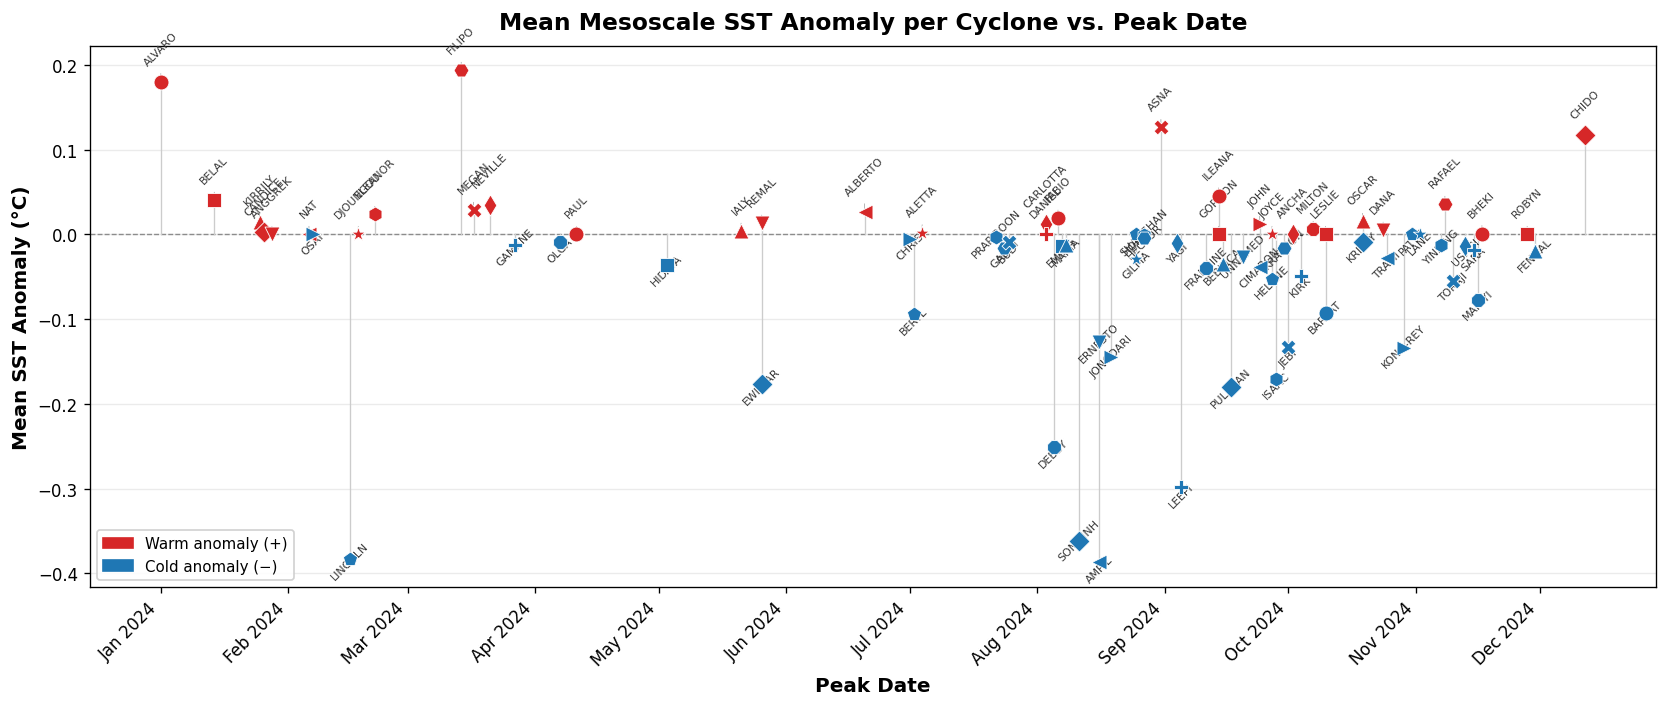

Saved: MSLA_Anomaly_vs_Date.png


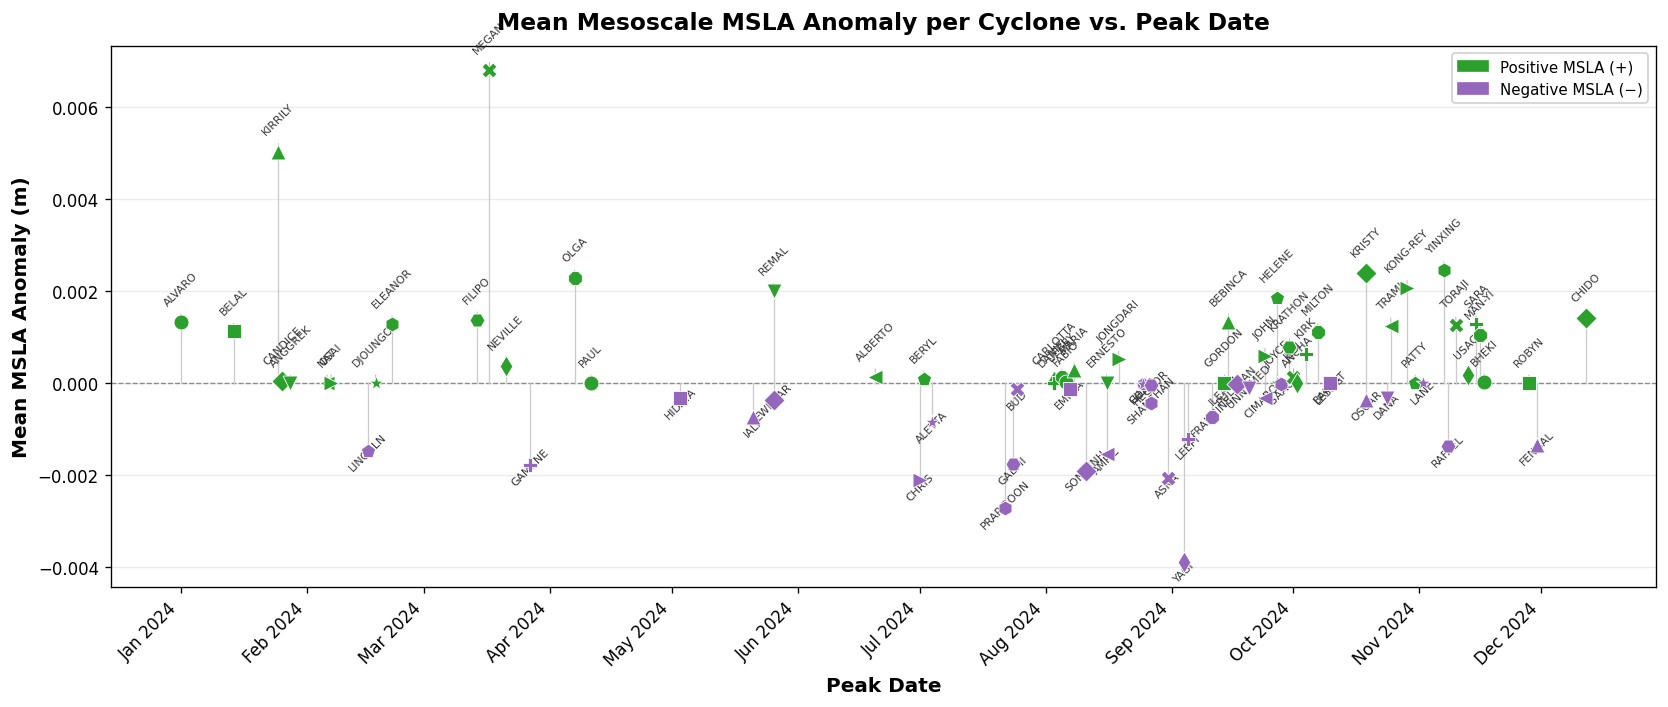

Saved: SST_MSLA_Correlation.png


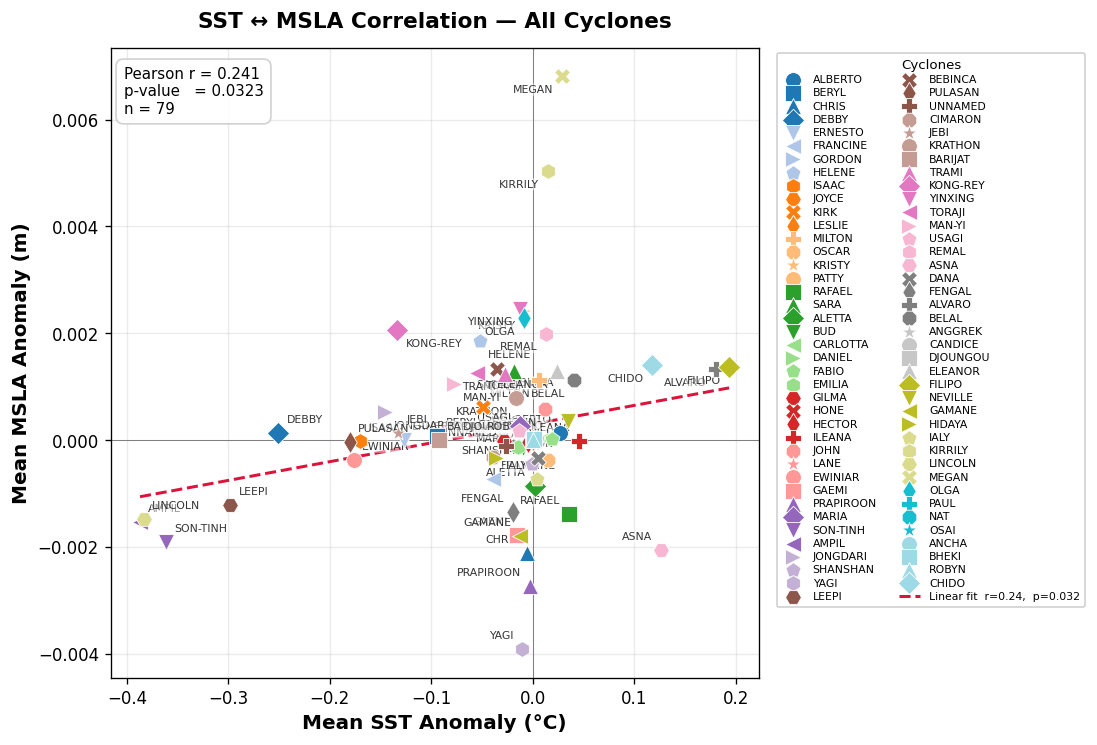

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import pearsonr


# =============================================================================
# STEP 1 — Compute simple mean SST & MSLA anomaly per cyclone
# =============================================================================

def _get_peak_date(cyc):
    """
    Returns a datetime.date for the cyclone peak.
    Priority:
      1. dates['peak']
      2. midpoint(formation, dissipation)
      3. midpoint of analysis window
    """
    dates = cyc.get('dates', {})
    if dates.get('peak'):
        return pd.to_datetime(dates['peak']).date()
    if dates.get('formation') and dates.get('dissipation'):
        t0 = pd.to_datetime(dates['formation'])
        t1 = pd.to_datetime(dates['dissipation'])
        return (t0 + (t1 - t0) / 2).date()
    windows = _get_analysis_window_ranges(cyc)
    if windows:
        _, s, e = windows[-1]
        t0, t1 = pd.to_datetime(s), pd.to_datetime(e)
        return (t0 + (t1 - t0) / 2).date()
    return None


def calculate_cyclone_anomalies_mean(cyclones_dict,
                                     output_csv='cyclone_anomalies_mean.csv'):
    """
    One row per cyclone.
    SST_Anomaly  = nanmean of daily meso-scale SST  over the analysis window.
    MSLA_Anomaly = nanmean of daily meso-scale MSLA over the analysis window.
    Peak_Date    = formation/dissipation midpoint (or explicit 'peak' key).
    """
    records = []

    for cyc_name, cyc in cyclones_dict.items():
        print(f"  {cyc_name} ...", end=' ', flush=True)

        bbox  = cyc.get('bbox')
        track = cyc.get('track')
        if not bbox or not track:
            print("skipped (no bbox/track)"); continue

        bbox      = _make_square_bbox(bbox, track)
        peak_date = _get_peak_date(cyc)
        if peak_date is None:
            print("skipped (no peak date)"); continue

        windows = _get_analysis_window_ranges(cyc)
        if not windows:
            print("skipped (no analysis window)"); continue

        _, start_str, end_str = windows[-1]
        date_list = _get_analysis_date_list_from_range(start_str, end_str)

        sst_vals, msla_vals = [], []

        for date in date_list:
            # SST
            sst_raw = load_sst_for_date(date, bbox)
            if sst_raw is not None:
                dec = decompose_sst_field(sst_raw)
                if dec and 'meso' in dec:
                    sst_vals.append(np.nanmean(dec['meso']))

            # MSLA
            msla_raw = load_msla_for_date(date, bbox)
            if msla_raw is not None:
                dec = decompose_msla_field(msla_raw)
                if dec and 'meso' in dec:
                    msla_vals.append(np.nanmean(dec['meso']))

        sst_mean  = np.nanmean(sst_vals)  if sst_vals  else np.nan
        msla_mean = np.nanmean(msla_vals) if msla_vals else np.nan

        d = cyc.get('dates', {})
        records.append({
            'Cyclone'     : cyc_name,
            'Peak_Date'   : str(peak_date),
            'Formation'   : d.get('formation', ''),
            'Dissipation' : d.get('dissipation', ''),
            'SST_Anomaly' : sst_mean,
            'MSLA_Anomaly': msla_mean,
        })
        print(f"SST={sst_mean:.4f}  MSLA={msla_mean:.5f}")

    df = pd.DataFrame(records)
    if not df.empty:
        df['Peak_Date'] = pd.to_datetime(df['Peak_Date'])
        df.to_csv(output_csv, index=False)
        print(f"\nSaved → {output_csv}")
    return df


# =============================================================================
# STEP 2 — Plot SST Anomaly  (x = Peak Date, y = SST Anomaly)
# =============================================================================

def plot_sst_anomaly(df, save=True):
    """
    One marker per cyclone.  X = peak date, Y = mean SST anomaly (°C).
    Markers coloured red (warm) / blue (cold).  Cyclone name annotated.
    """
    valid = df.dropna(subset=['SST_Anomaly', 'Peak_Date']).copy()
    valid['Peak_Date'] = pd.to_datetime(valid['Peak_Date'])
    valid = valid.sort_values('Peak_Date')

    if valid.empty:
        print("No SST data."); return

    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h',
               'H', 'X', 'd', 'P', '8']
    colors  = ['#d62728' if v >= 0 else '#1f77b4'
               for v in valid['SST_Anomaly']]

    fig, ax = plt.subplots(figsize=(14, 6))

    # zero line
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', zorder=1)

    # vertical stems
    for _, row in valid.iterrows():
        ax.plot([row['Peak_Date'], row['Peak_Date']],
                [0, row['SST_Anomaly']],
                color='#cccccc', linewidth=0.8, zorder=2)

    # markers + value labels
    for i, (_, row) in enumerate(valid.iterrows()):
        c = '#d62728' if row['SST_Anomaly'] >= 0 else '#1f77b4'
        ax.scatter(row['Peak_Date'], row['SST_Anomaly'],
                   marker=markers[i % len(markers)],
                   color=c, s=80, zorder=4,
                   edgecolors='white', linewidths=0.5)

        # cyclone name
        yoff = 0.004 if row['SST_Anomaly'] >= 0 else -0.004
        ax.annotate(row['Cyclone'],
                    xy=(row['Peak_Date'], row['SST_Anomaly']),
                    xytext=(0, 10 if row['SST_Anomaly'] >= 0 else -12),
                    textcoords='offset points',
                    ha='center', fontsize=6.5, color='#333333',
                    rotation=45,
                    arrowprops=dict(arrowstyle='-', color='#aaaaaa', lw=0.5))

        # numeric label
        # ax.text(row['Peak_Date'], row['SST_Anomaly'] + yoff * 8,
        #         f"{row['SST_Anomaly']:.3f}",
        #         ha='center', va='bottom' if row['SST_Anomaly'] >= 0 else 'top',
        #         fontsize=6, color='#444444')

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    fig.autofmt_xdate(rotation=45)

    ax.set_xlabel('Peak Date', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean SST Anomaly (°C)', fontsize=12, fontweight='bold')
    ax.set_title('Mean Mesoscale SST Anomaly per Cyclone vs. Peak Date',
                 fontsize=14, fontweight='bold', pad=10)
    ax.grid(axis='y', alpha=0.25)

    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='#d62728', label='Warm anomaly (+)'),
                        Patch(color='#1f77b4', label='Cold anomaly (−)')],
              fontsize=9, framealpha=0.9, loc='best')

    plt.tight_layout()
    if save:
        plt.savefig('SST_Anomaly_vs_Date.png', dpi=150, bbox_inches='tight')
        print("Saved: SST_Anomaly_vs_Date.png")
    plt.show()


# =============================================================================
# STEP 3 — Plot MSLA Anomaly  (x = Peak Date, y = MSLA Anomaly)
# =============================================================================

def plot_msla_anomaly(df, save=True):
    """
    One marker per cyclone.  X = peak date, Y = mean MSLA anomaly (m).
    """
    valid = df.dropna(subset=['MSLA_Anomaly', 'Peak_Date']).copy()
    valid['Peak_Date'] = pd.to_datetime(valid['Peak_Date'])
    valid = valid.sort_values('Peak_Date')

    if valid.empty:
        print("No MSLA data."); return

    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h',
               'H', 'X', 'd', 'P', '8']

    fig, ax = plt.subplots(figsize=(14, 6))

    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', zorder=1)

    for _, row in valid.iterrows():
        ax.plot([row['Peak_Date'], row['Peak_Date']],
                [0, row['MSLA_Anomaly']],
                color='#cccccc', linewidth=0.8, zorder=2)

    for i, (_, row) in enumerate(valid.iterrows()):
        c = '#2ca02c' if row['MSLA_Anomaly'] >= 0 else '#9467bd'
        ax.scatter(row['Peak_Date'], row['MSLA_Anomaly'],
                   marker=markers[i % len(markers)],
                   color=c, s=80, zorder=4,
                   edgecolors='white', linewidths=0.5)

        ax.annotate(row['Cyclone'],
                    xy=(row['Peak_Date'], row['MSLA_Anomaly']),
                    xytext=(0, 10 if row['MSLA_Anomaly'] >= 0 else -12),
                    textcoords='offset points',
                    ha='center', fontsize=6.5, color='#333333',
                    rotation=45,
                    arrowprops=dict(arrowstyle='-', color='#aaaaaa', lw=0.5))

        yoff = 0.0003 if row['MSLA_Anomaly'] >= 0 else -0.0003
        # ax.text(row['Peak_Date'], row['MSLA_Anomaly'] + yoff * 8,
        #         f"{row['MSLA_Anomaly']:.4f}",
        #         ha='center', va='bottom' if row['MSLA_Anomaly'] >= 0 else 'top',
        #         fontsize=6, color='#444444')

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    fig.autofmt_xdate(rotation=45)

    ax.set_xlabel('Peak Date', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean MSLA Anomaly (m)', fontsize=12, fontweight='bold')
    ax.set_title('Mean Mesoscale MSLA Anomaly per Cyclone vs. Peak Date',
                 fontsize=14, fontweight='bold', pad=10)
    ax.grid(axis='y', alpha=0.25)

    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='#2ca02c', label='Positive MSLA (+)'),
                        Patch(color='#9467bd', label='Negative MSLA (−)')],
              fontsize=9, framealpha=0.9, loc='best')

    plt.tight_layout()
    if save:
        plt.savefig('MSLA_Anomaly_vs_Date.png', dpi=150, bbox_inches='tight')
        print("Saved: MSLA_Anomaly_vs_Date.png")
    plt.show()


# =============================================================================
# STEP 4 — Correlation  (x = SST, y = MSLA, one point per cyclone)
# =============================================================================

def plot_anomaly_correlation(df, save=True):
    """
    Scatter of SST vs MSLA mean anomaly across all cyclones,
    with regression line and Pearson r / p-value annotation.
    """
    # Note: Using column names from user's snippet. Ensure these exist in your DataFrame.
    # If using the multiscale CSV, you might need to rename columns or map them here.
    col_x = 'SST_Anomaly'
    col_y = 'MSLA_Anomaly'
    
    if col_x not in df.columns or col_y not in df.columns:
        # Fallback to Meso-scale if user's names aren't found
        col_x, col_y = 'SST_Meso', 'MSLA_Meso'

    valid = df.dropna(subset=[col_x, col_y]).copy()
    if valid.empty:
        print("No paired data."); return

    sst  = valid[col_x].values
    msla = valid[col_y].values
    corr, pval = pearsonr(sst, msla)

    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', 'h', 'H',
               'X', 'd', 'P', '8', '*']
    
    # Modern colormap lookup
    cmap = plt.get_cmap('tab20', len(valid))

    fig, ax = plt.subplots(figsize=(9, 7))

    # Calculate midpoints for intelligent annotation placement
    x_mid = np.mean(sst)
    y_mid = np.mean(msla)

    for i, (_, row) in enumerate(valid.iterrows()):
        x, y = row[col_x], row[col_y]
        ax.scatter(x, y,
                   marker=markers[i % len(markers)],
                   color=cmap(i), s=90, zorder=4,
                   edgecolors='white', linewidths=0.5,
                   label=row['Cyclone'])
        
        # --- START MODIFIED ANNOTATION LOGIC ---
        # Adjust text position based on location relative to height/width center
        # This prevents labels from going out of plot bounds.
        x_off = 5 if x < x_mid else -5
        y_off = 5 if y < y_mid else -5
        ha = 'left' if x_off > 0 else 'right'
        va = 'bottom' if y_off > 0 else 'top'

        ax.annotate(row['Cyclone'],
                    xy=(x, y),
                    xytext=(x_off, y_off), textcoords='offset points',
                    ha=ha, va=va,
                    fontsize=6.5, color='#333333',
                    bbox=dict(boxstyle='round,pad=0.1', facecolor='white', edgecolor='none', alpha=0.5))
        # --- END MODIFIED ANNOTATION LOGIC ---

    # regression
    m, b   = np.polyfit(sst, msla, 1)
    xs     = np.linspace(sst.min(), sst.max(), 200)
    ax.plot(xs, m * xs + b, color='crimson', linestyle='--',
            linewidth=1.8, label=f'Linear fit  r={corr:.2f},  p={pval:.3f}')

    ax.axhline(0, color='gray', linewidth=0.6)
    ax.axvline(0, color='gray', linewidth=0.6)

    ax.set_xlabel('Mean SST Anomaly (°C)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean MSLA Anomaly (m)',  fontsize=12, fontweight='bold')
    ax.set_title('SST ↔ MSLA Correlation — All Cyclones',
                 fontsize=13, fontweight='bold', pad=12)
    ax.grid(True, alpha=0.25)

    # legend outside to the right in two columns
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0),
              fontsize=6.5, framealpha=0.9, ncol=2, 
              title="Cyclones", title_fontsize=8,
              labelspacing=0.3, borderpad=0.5)

    ax.text(0.02, 0.97,
            f'Pearson r = {corr:.3f}\np-value   = {pval:.4f}\nn = {len(valid)}',
            transform=ax.transAxes, va='top', ha='left', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                      edgecolor='#cccccc', alpha=0.9))

    # Manual adjustment to prevent "Tight layout" warnings and accommodate the 2-column legend
    plt.subplots_adjust(left=0.1, right=0.7, top=0.9, bottom=0.15)
    if save:
        plt.savefig('SST_MSLA_Correlation.png', dpi=150, bbox_inches='tight')
        print("Saved: SST_MSLA_Correlation.png")
    plt.show()


# =============================================================================
# RUNNER  (uncomment to execute)
# =============================================================================

# -- compute once (slow) ---
# df_anom = calculate_cyclone_anomalies_mean(cyclones)

# -- or reload saved CSV --
df_anom = pd.read_csv('cyclone_anomalies_mean.csv')

# -- plot --
plot_sst_anomaly(df_anom)
plot_msla_anomaly(df_anom)
plot_anomaly_correlation(df_anom)


Processing ALBERTO ...   SST  grid_res=0.05°  ref_lat=21.2°N
  sigma_sub   lat:4.00  lon:4.29  grid pts
  sigma_meso  lat:4.00  lon:4.29  grid pts
  sigma_large lat:54.00  lon:57.90  grid pts
  Reconstruction residual (mean |error|): 0.00e+00  ✓ OK
  MSLA grid_res=0.125°  ref_lat=21.2°N
  sigma_sub   lat:4.00  lon:4.29  grid pts
  sigma_meso  lat:4.00  lon:4.29  grid pts
  sigma_large lat:21.60  lon:23.17  grid pts
  Reconstruction residual (mean |error|): 2.94e-19  ✓ OK
  SST  grid_res=0.05°  ref_lat=21.2°N
  sigma_sub   lat:4.00  lon:4.29  grid pts
  sigma_meso  lat:4.00  lon:4.29  grid pts
  sigma_large lat:54.00  lon:57.90  grid pts
  Reconstruction residual (mean |error|): 0.00e+00  ✓ OK
  MSLA grid_res=0.125°  ref_lat=21.2°N
  sigma_sub   lat:4.00  lon:4.29  grid pts
  sigma_meso  lat:4.00  lon:4.29  grid pts
  sigma_large lat:21.60  lon:23.17  grid pts
  Reconstruction residual (mean |error|): 2.94e-19  ✓ OK
  SST  grid_res=0.05°  ref_lat=21.2°N
  sigma_sub   lat:4.00  lon:4.29 

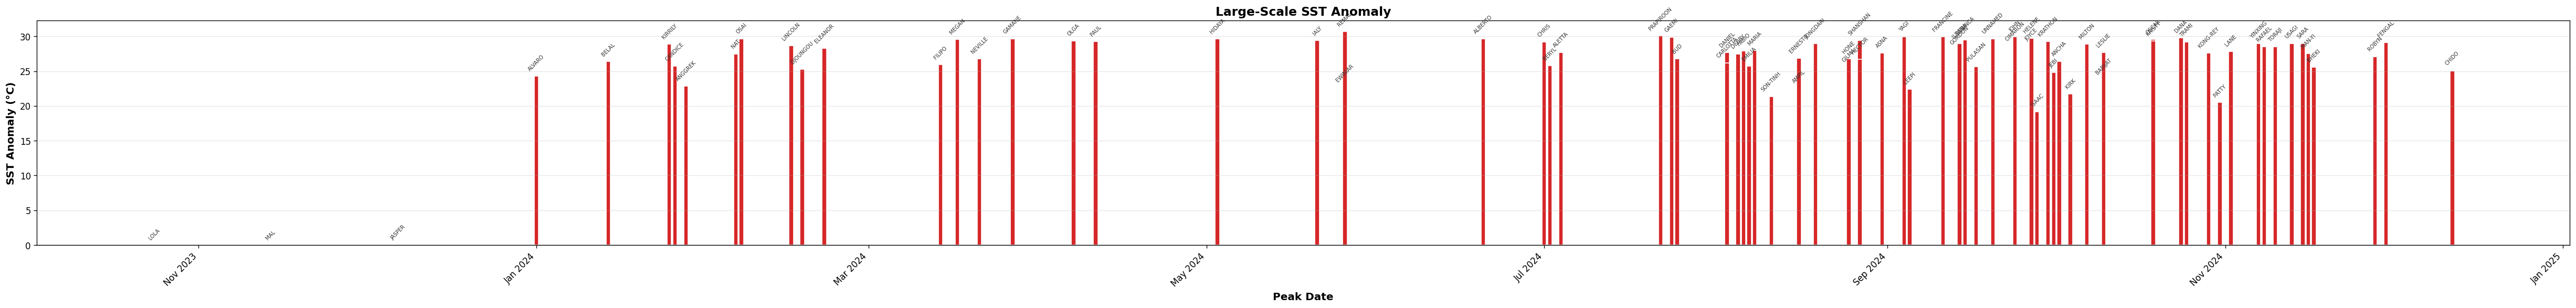

Saved: SST_Meso_vs_Date.png


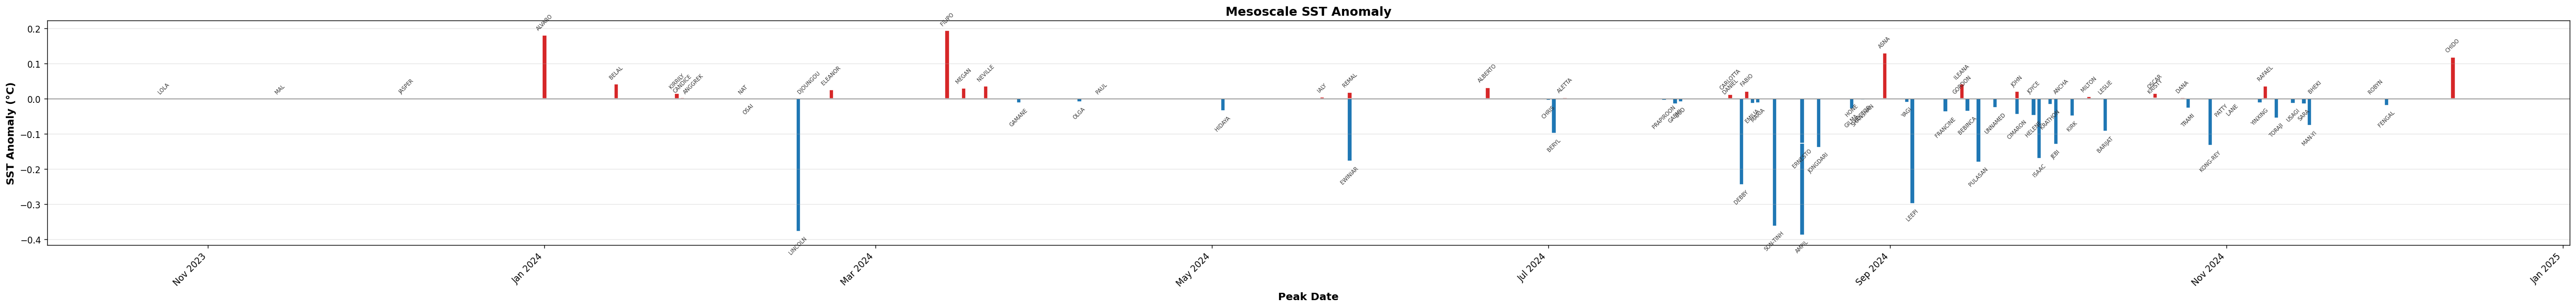

Saved: SST_Submeso_vs_Date.png


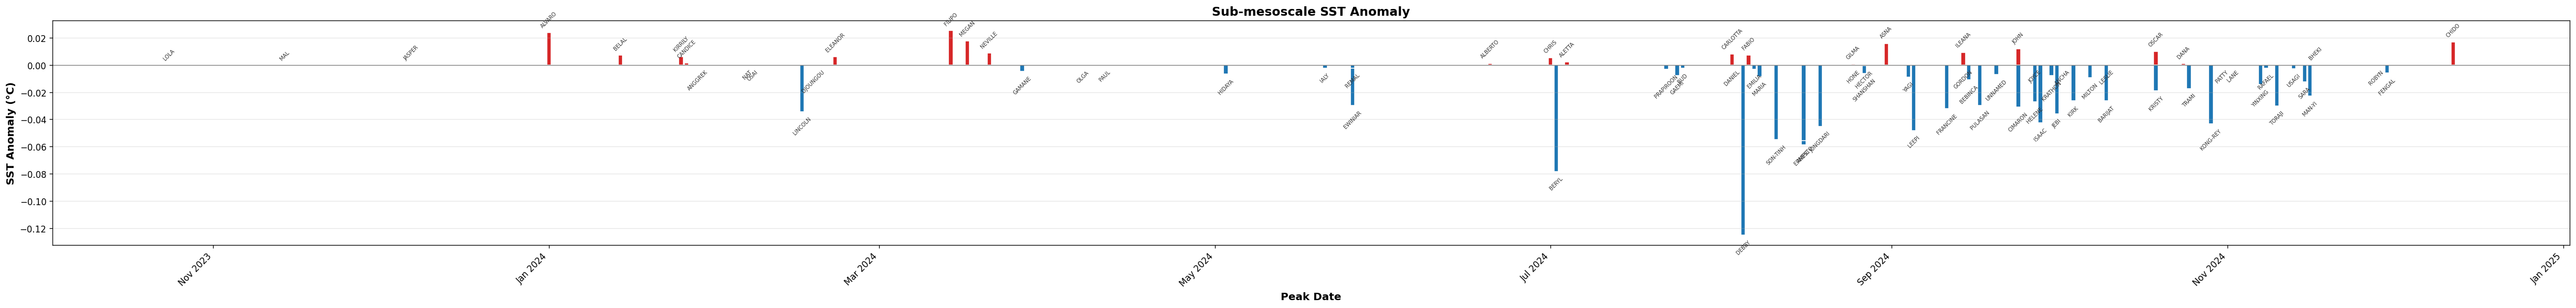

Saved: MSLA_Large_vs_Date.png


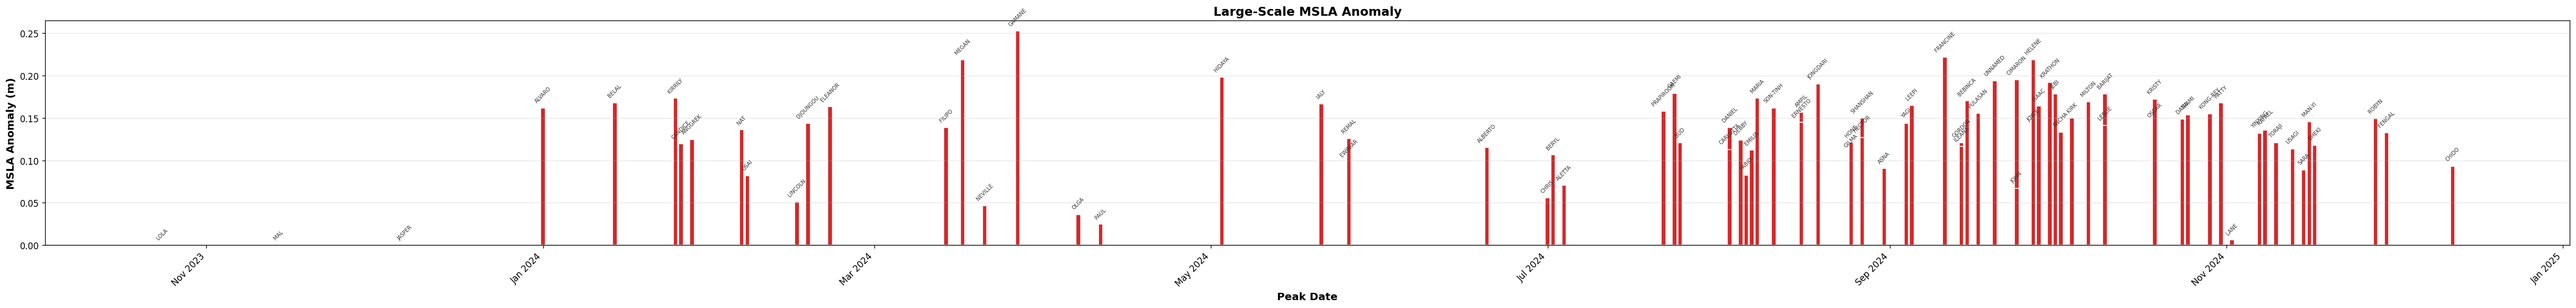

Saved: MSLA_Meso_vs_Date.png


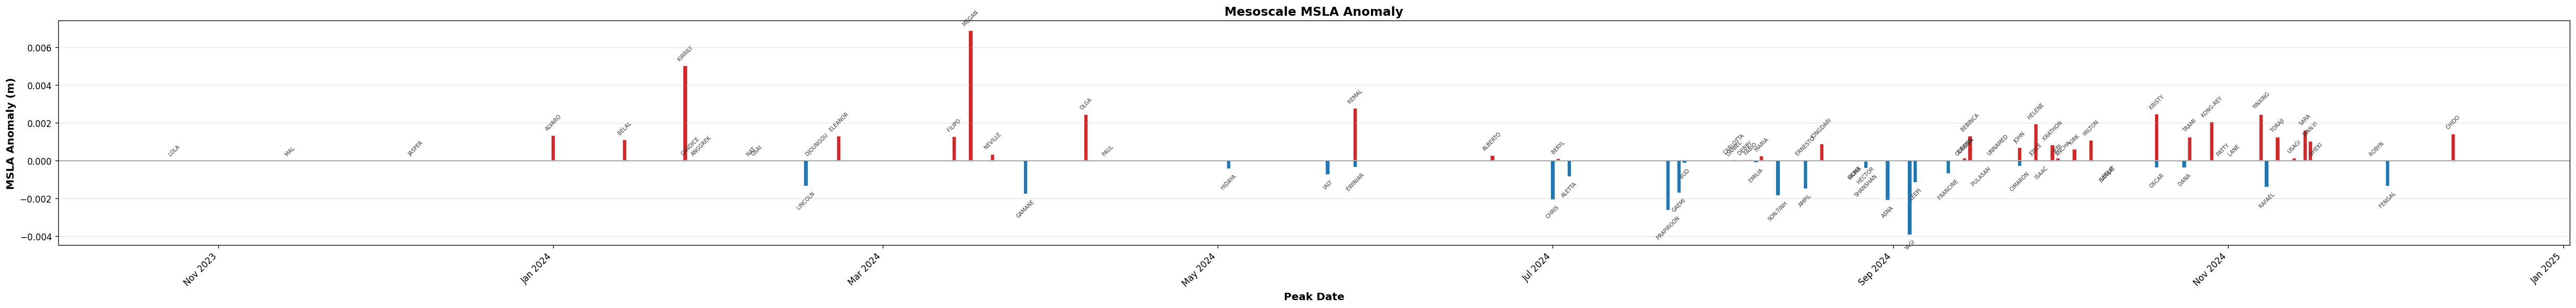

Saved: MSLA_Submeso_vs_Date.png


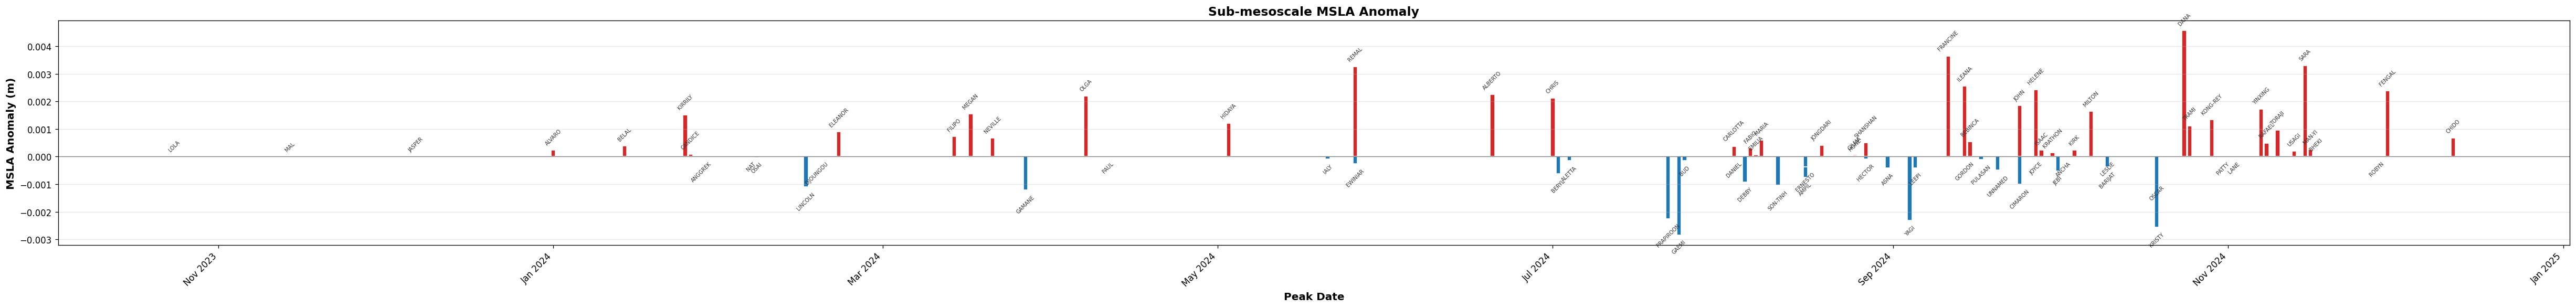

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import pearsonr

# =============================================================================
# Helper – get peak date (same as previous implementations)
# =============================================================================

def _get_peak_date(cyc):
    """Return a datetime.date representing the cyclone's peak.
    Preference order: explicit 'peak' in dates, midpoint of formation/dissipation,
    then midpoint of the analysis window.
    """
    dates = cyc.get('dates', {})
    if dates.get('peak'):
        return pd.to_datetime(dates['peak']).date()
    if dates.get('formation') and dates.get('dissipation'):
        t0 = pd.to_datetime(dates['formation'])
        t1 = pd.to_datetime(dates['dissipation'])
        return (t0 + (t1 - t0) / 2).date()
    windows = _get_analysis_window_ranges(cyc)
    if windows:
        _, s, e = windows[-1]
        t0, t1 = pd.to_datetime(s), pd.to_datetime(e)
        return (t0 + (t1 - t0) / 2).date()
    return None

# =============================================================================
# MULTI‑SCALE ANOMALY CALCULATION (simple mean per cyclone)
# =============================================================================

def calculate_multiscale_anomalies(cyclones_dict, output_csv='cyclone_multiscale_anomalies.csv'):
    """Compute mean SST & MSLA anomalies for each scale (Signal - Baseline)."""
    records = []
    from datetime import timedelta

    for cyc_name, cyc in cyclones_dict.items():
        print(f"Processing {cyc_name} ...", end=' ', flush=True)
        
        # 1. Identify windows explicitly
        # We need a 'Pre' window for the baseline and a 'During' window for the signal
        ad = cyc.get('analysis_dates', {})
        dates = cyc.get('dates', {})
        
        pre_range = ad.get('pre')
        dur_range = ad.get('during') or ad.get('post')
        
        # Fallback if analysis_dates is missing
        if not pre_range or not dur_range:
            fmt = "%Y-%m-%d"
            formation = pd.to_datetime(dates.get('formation'))
            pre_range = ((formation - timedelta(days=5)).strftime(fmt), 
                         (formation - timedelta(days=1)).strftime(fmt))
            dur_range = (dates.get('formation'), dates.get('dissipation'))

        def get_means(date_range):
            if not date_range[0] or not date_range[1]: return None
            d_list = pd.date_range(date_range[0], date_range[1], freq='D')
            l, m, s = [], [], []
            ml, mm, ms = [], [], []
            bbox = _make_square_bbox(cyc['bbox'], cyc['track'])
            for d in d_list:
                # SST
                sst = load_sst_for_date(d, bbox)
                if sst is not None:
                    dec = decompose_sst_field(sst)
                    if dec:
                        if 'large_scale' in dec: l.append(np.nanmean(dec['large_scale']))
                        if 'meso' in dec: m.append(np.nanmean(dec['meso']))
                        if 'submeso' in dec: s.append(np.nanmean(dec['submeso']))
                # MSLA
                msla = load_msla_for_date(d, bbox)
                if msla is not None:
                    dec = decompose_msla_field(msla)
                    if dec:
                        if 'large_scale' in dec: ml.append(np.nanmean(dec['large_scale']))
                        if 'meso' in dec: mm.append(np.nanmean(dec['meso']))
                        if 'submeso' in dec: ms.append(np.nanmean(dec['submeso']))
            return (np.nanmean(l) if l else 0, np.nanmean(m) if m else 0, np.nanmean(s) if s else 0,
                    np.nanmean(ml) if ml else 0, np.nanmean(mm) if mm else 0, np.nanmean(ms) if ms else 0)

        # Calculate Baseline and Signal
        base = get_means(pre_range)
        sign = get_means(dur_range)

        if not base or not sign:
            print("skipped (missing data)"); continue

        rec = {
            'Cyclone': cyc_name,
            'Peak_Date': str(_get_peak_date(cyc)),
            'SST_Large': sign[0] - base[0],
            'SST_Meso': sign[1] - base[1],
            'SST_Submeso': sign[2] - base[2],
            'MSLA_Large': sign[3] - base[3],
            'MSLA_Meso': sign[4] - base[4],
            'MSLA_Submeso': sign[5] - base[5],
        }
        print(f"SST_Base={base[0]:.2f}, Signal={sign[0]:.2f} -> Anom={rec['SST_Large']:.3f}")
        records.append(rec)

    df = pd.DataFrame(records)
    if not df.empty:
        df['Peak_Date'] = pd.to_datetime(df['Peak_Date'])
        df.to_csv(output_csv, index=False)
        print(f"\nSaved true anomalies to {output_csv}")
    return df


# =============================================================================
# PLOT helpers – now using dates on the x‑axis
# =============================================================================

def _bar_plot_per_date(df, col, title, y_label, save_name, save=True):
    """Generic bar plot where the x‑axis is the peak date.
    Positive values are coloured warm/red, negatives cold/blue.
    """
    # keep only rows with both the anomaly and a peak date
    valid = df.dropna(subset=[col, 'Peak_Date']).copy()
    if valid.empty:
        print(f"No data for {col}")
        return
    # ensure dates are pandas Timestamp objects
    valid['Peak_Date'] = pd.to_datetime(valid['Peak_Date'])
    # sort chronologically
    valid = valid.sort_values('Peak_Date')

    colors = ['#d62728' if v >= 0 else '#1f77b4' for v in valid[col]]

    fig, ax = plt.subplots(figsize=(max(12, len(valid) * 0.5), 5))
    bars = ax.bar(valid['Peak_Date'], valid[col], color=colors, edgecolor='white')
    ax.axhline(0, color='gray', linewidth=0.8)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel(y_label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Peak Date', fontsize=12, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    # adjust locator: monthly if ≤12 points, otherwise every 2 months
    if len(valid) <= 12:
        ax.xaxis.set_major_locator(mdates.MonthLocator())
    else:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    fig.autofmt_xdate(rotation=45)
    ax.grid(axis='y', alpha=0.3)
    # annotate each bar with cyclone name
    ymin, ymax = valid[col].min(), valid[col].max()
    offset = 0.02 * (ymax - ymin) if ymax != ymin else 0.01
    for bar, name in zip(bars, valid['Cyclone']):
        height = bar.get_height()
        if height >= 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    height + offset,
                    name,
                    ha='center', va='bottom', fontsize=6,
                    rotation=45, color='#333333')
        else:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    height - offset,
                    name,
                    ha='center', va='top', fontsize=6,
                    rotation=45, color='#333333')
    plt.tight_layout()
    if save:
        plt.savefig(save_name, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_name}")
    plt.show()

def plot_sst_scales(df, save=True):
    """Three bar plots – one per SST scale, x‑axis = peak date.
    This mirrors the original visual intent but respects the temporal axis.
    """
    scales = [
        ('SST_Large',   'Large‑Scale SST Anomaly'),
        ('SST_Meso',    'Mesoscale SST Anomaly'),
        ('SST_Submeso', 'Sub‑mesoscale SST Anomaly')
    ]
    for col, title in scales:
        _bar_plot_per_date(df, col, title, 'SST Anomaly (°C)',
                           f"{col}_vs_Date.png", save)

def plot_msla_scales(df, save=True):
    """Three bar plots – one per MSLA scale, x‑axis = peak date."""
    scales = [
        ('MSLA_Large',   'Large‑Scale MSLA Anomaly'),
        ('MSLA_Meso',    'Mesoscale MSLA Anomaly'),
        ('MSLA_Submeso', 'Sub‑mesoscale MSLA Anomaly')
    ]
    for col, title in scales:
        _bar_plot_per_date(df, col, title, 'MSLA Anomaly (m)',
                           f"{col}_vs_Date.png", save)

# =============================================================================
# QUICK RUNNER (uncomment to execute)
# =============================================================================
df_multi = calculate_multiscale_anomalies(cyclones)
# df_multi = pd.read_csv('cyclone_multiscale_anomalies.csv')
plot_sst_scales(df_multi)
plot_msla_scales(df_multi)


Processing ALBERTO ... 

  SST  grid_res=0.05°  ref_lat=21.2°N
  sigma_sub   lat:4.00  lon:4.29  grid pts
  sigma_meso  lat:4.00  lon:4.29  grid pts
  sigma_large lat:54.00  lon:57.90  grid pts
  Reconstruction residual (mean |error|): 0.00e+00  ✓ OK
  MSLA grid_res=0.125°  ref_lat=21.2°N
  sigma_sub   lat:4.00  lon:4.29  grid pts
  sigma_meso  lat:4.00  lon:4.29  grid pts
  sigma_large lat:21.60  lon:23.17  grid pts
  Reconstruction residual (mean |error|): 2.94e-19  ✓ OK
  SST  grid_res=0.05°  ref_lat=21.2°N
  sigma_sub   lat:4.00  lon:4.29  grid pts
  sigma_meso  lat:4.00  lon:4.29  grid pts
  sigma_large lat:54.00  lon:57.90  grid pts
  Reconstruction residual (mean |error|): 0.00e+00  ✓ OK
  MSLA grid_res=0.125°  ref_lat=21.2°N
  sigma_sub   lat:4.00  lon:4.29  grid pts
  sigma_meso  lat:4.00  lon:4.29  grid pts
  sigma_large lat:21.60  lon:23.17  grid pts
  Reconstruction residual (mean |error|): 2.94e-19  ✓ OK
  SST  grid_res=0.05°  ref_lat=21.2°N
  sigma_sub   lat:4.00  lon:4.29  grid pts
  sigma_meso 

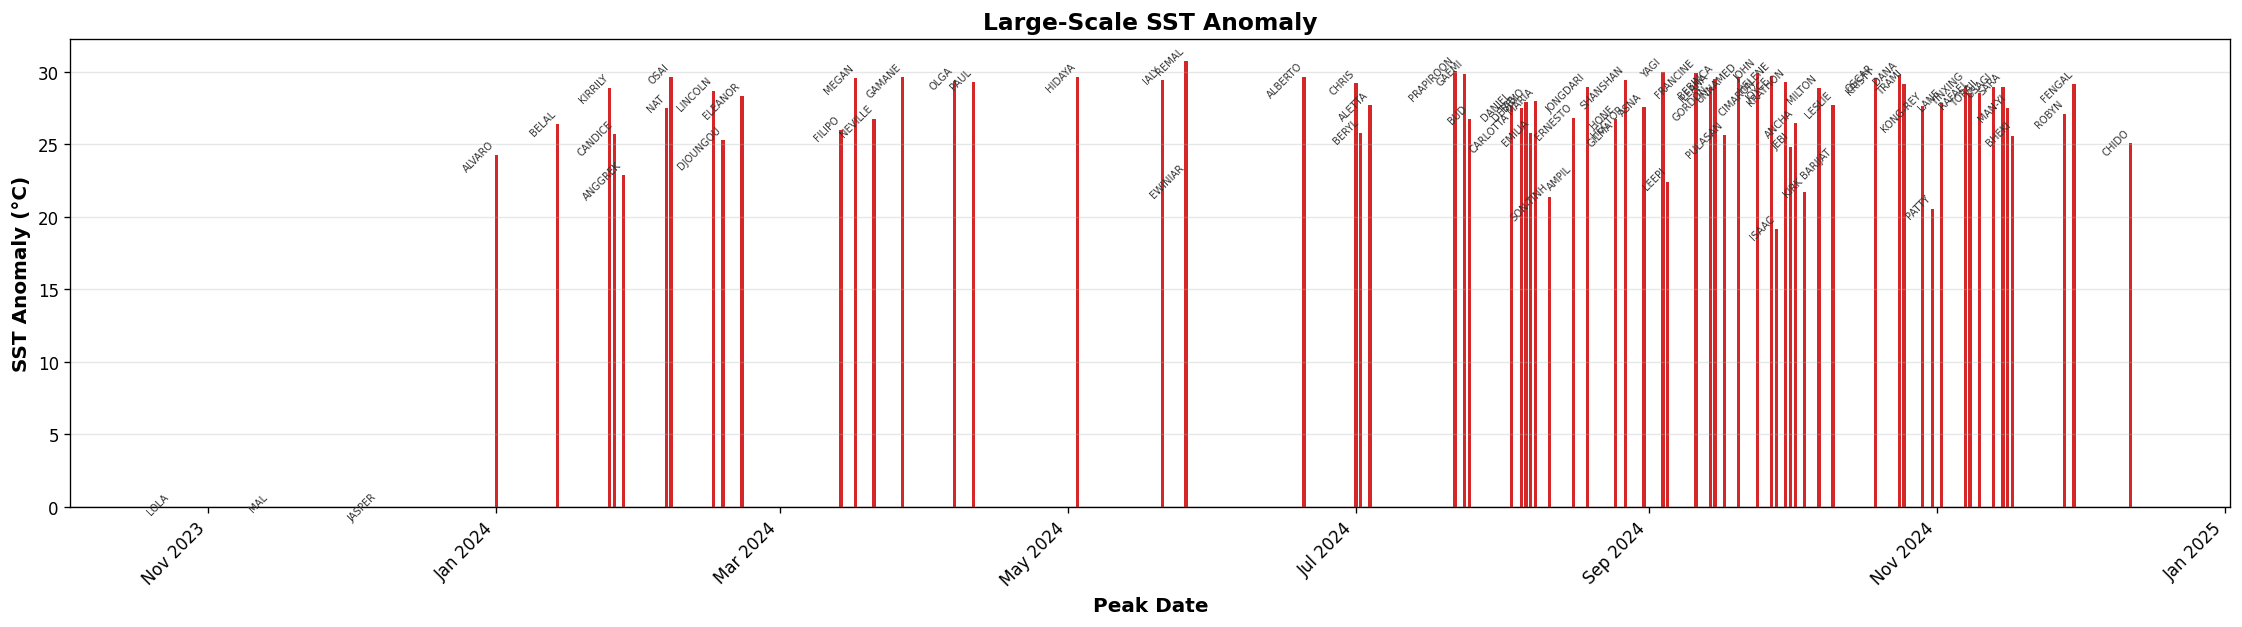

Saved: SST_Meso_vs_Date.png


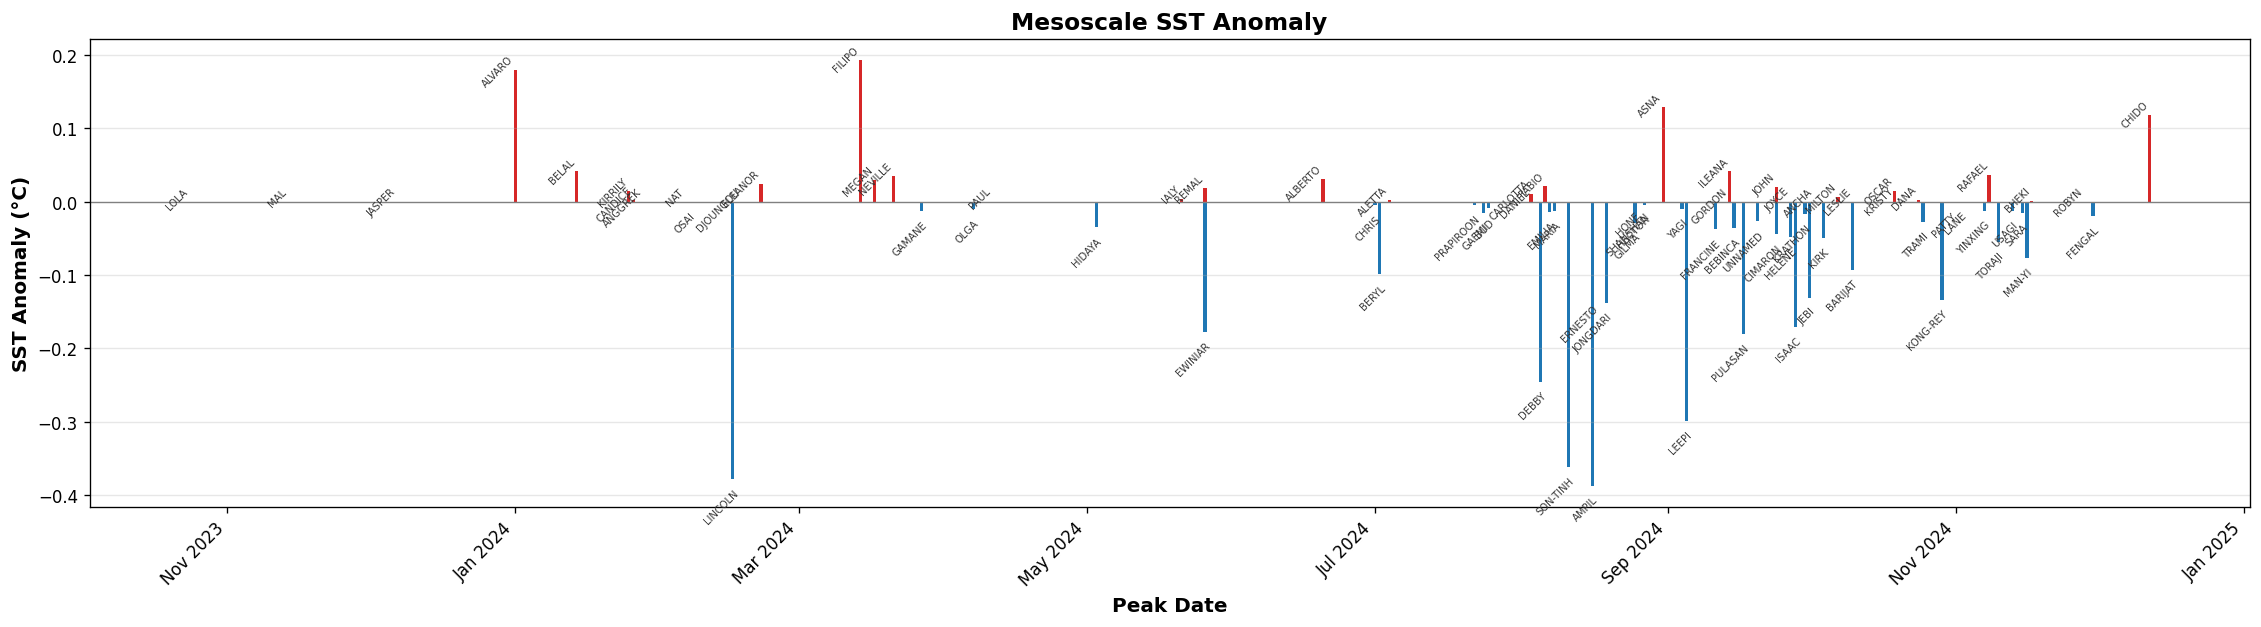

Saved: SST_Submeso_vs_Date.png


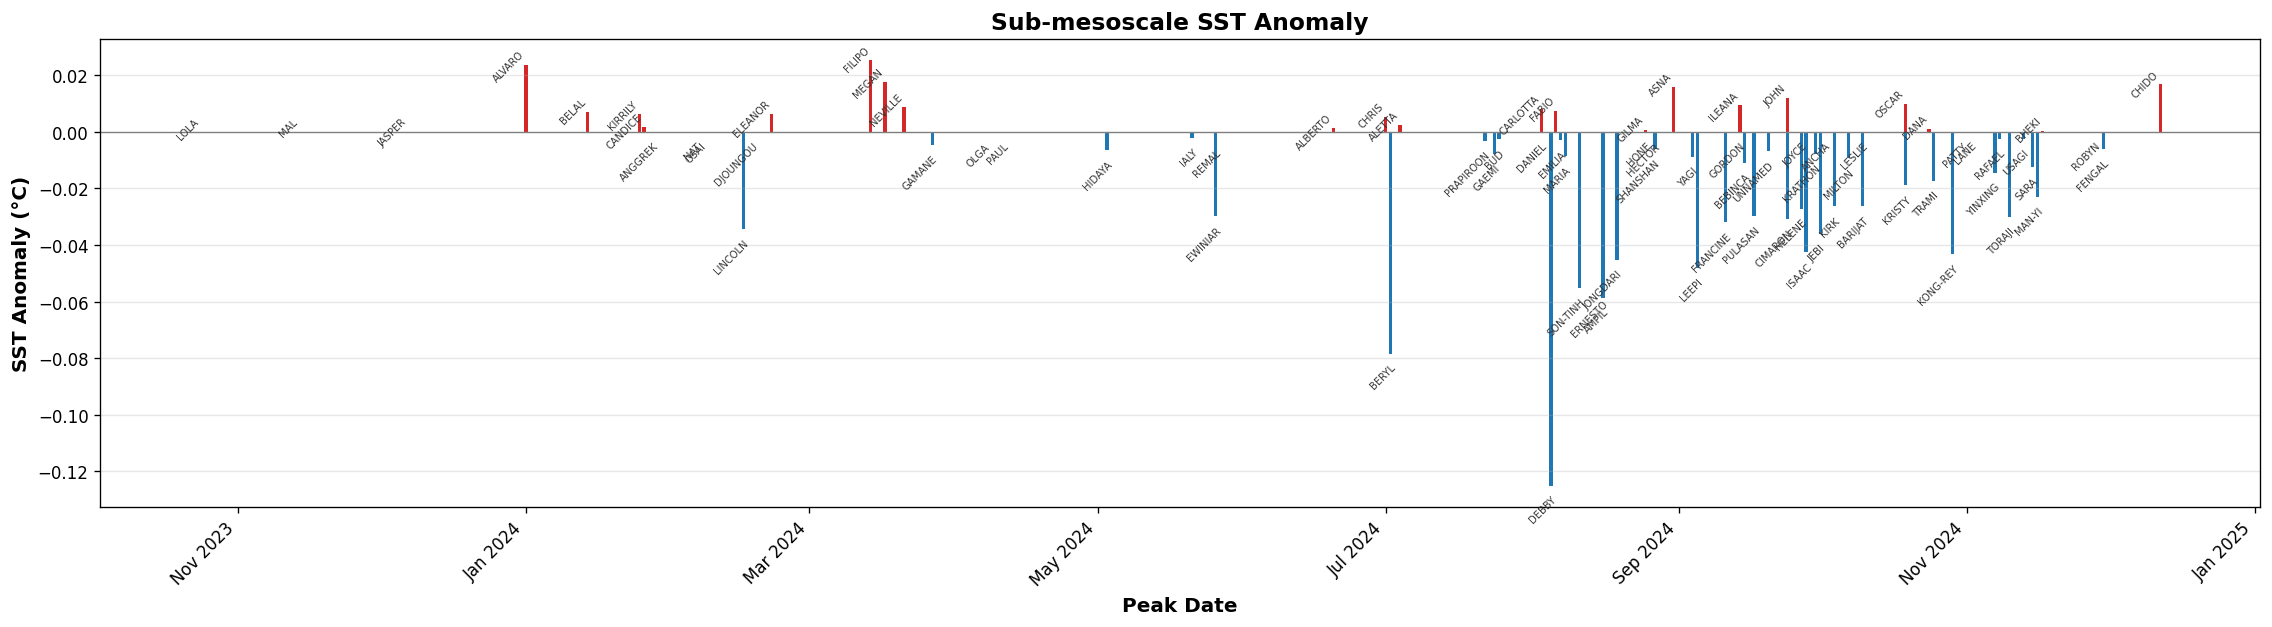

Saved: MSLA_Large_vs_Date.png


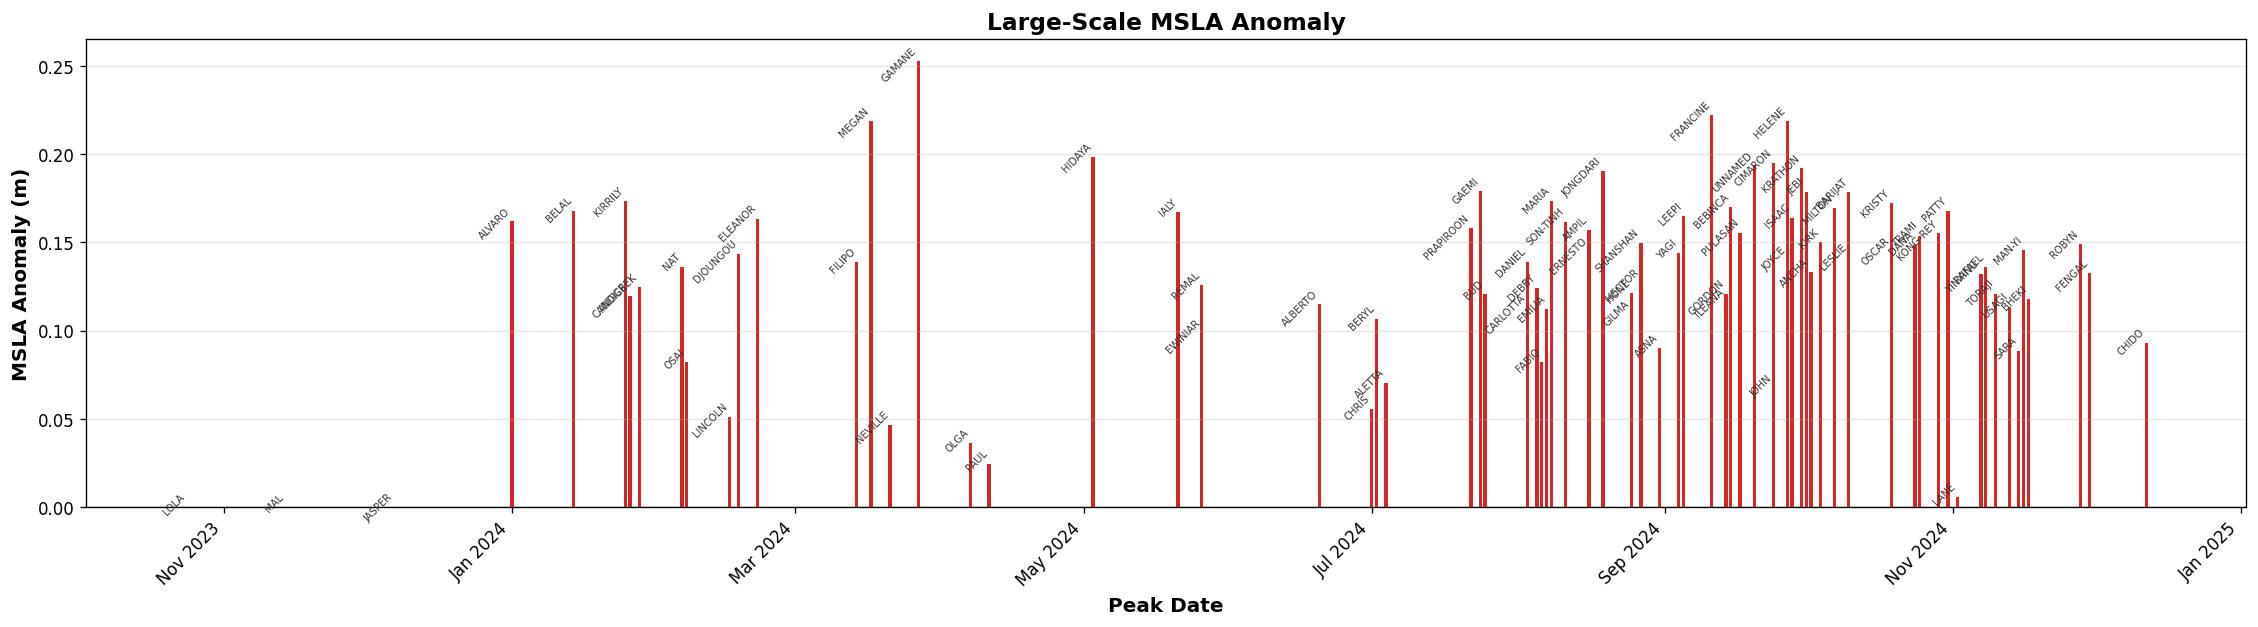

Saved: MSLA_Meso_vs_Date.png


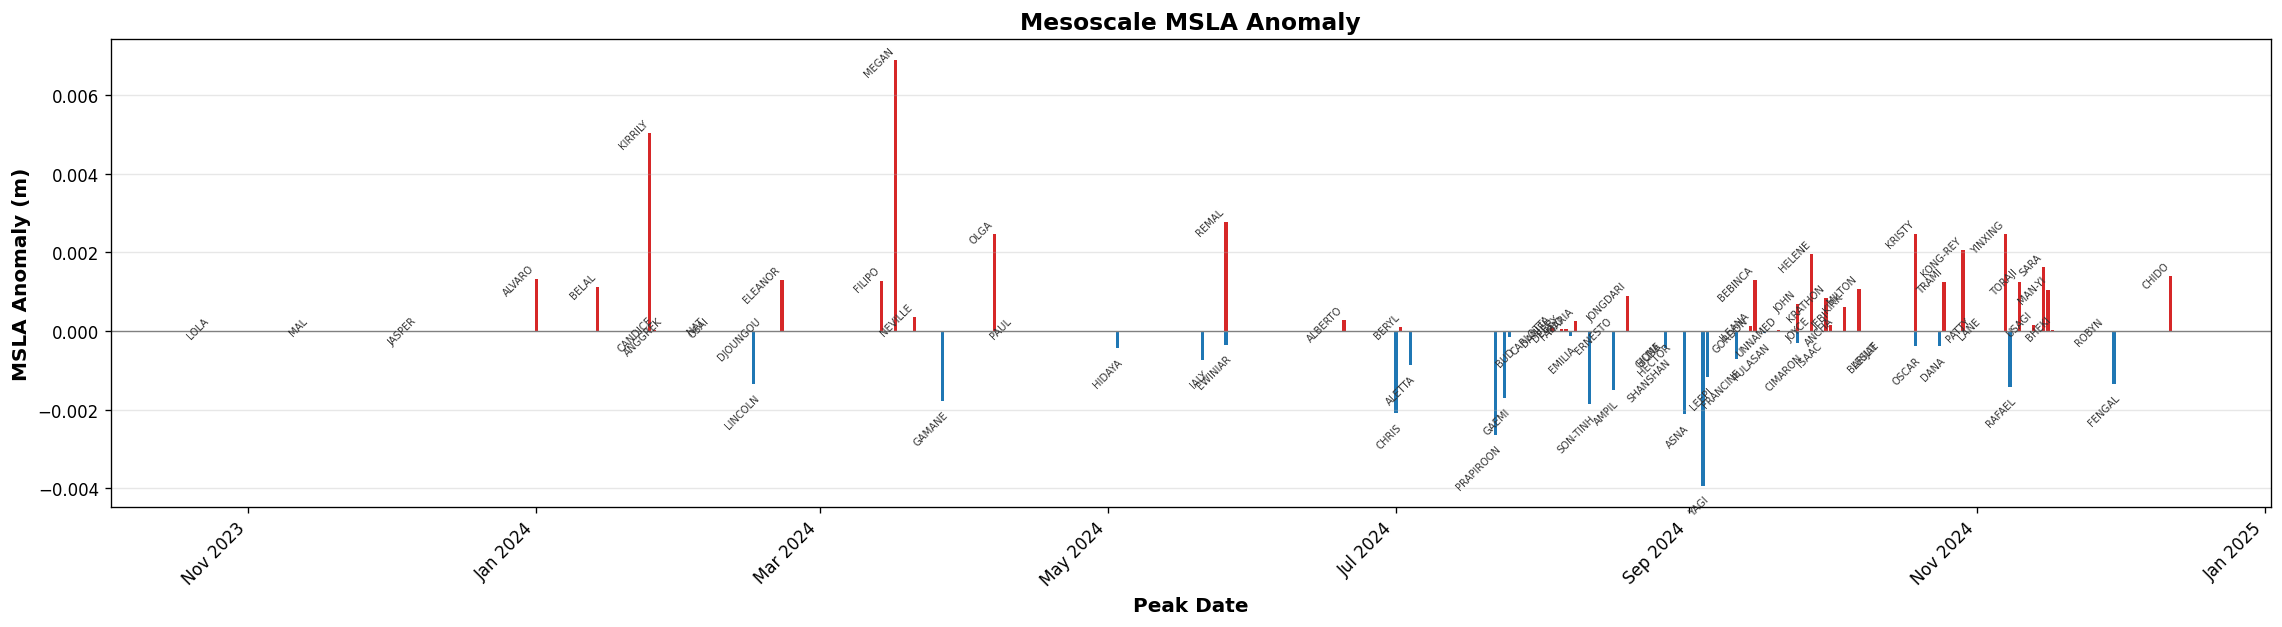

Saved: MSLA_Submeso_vs_Date.png


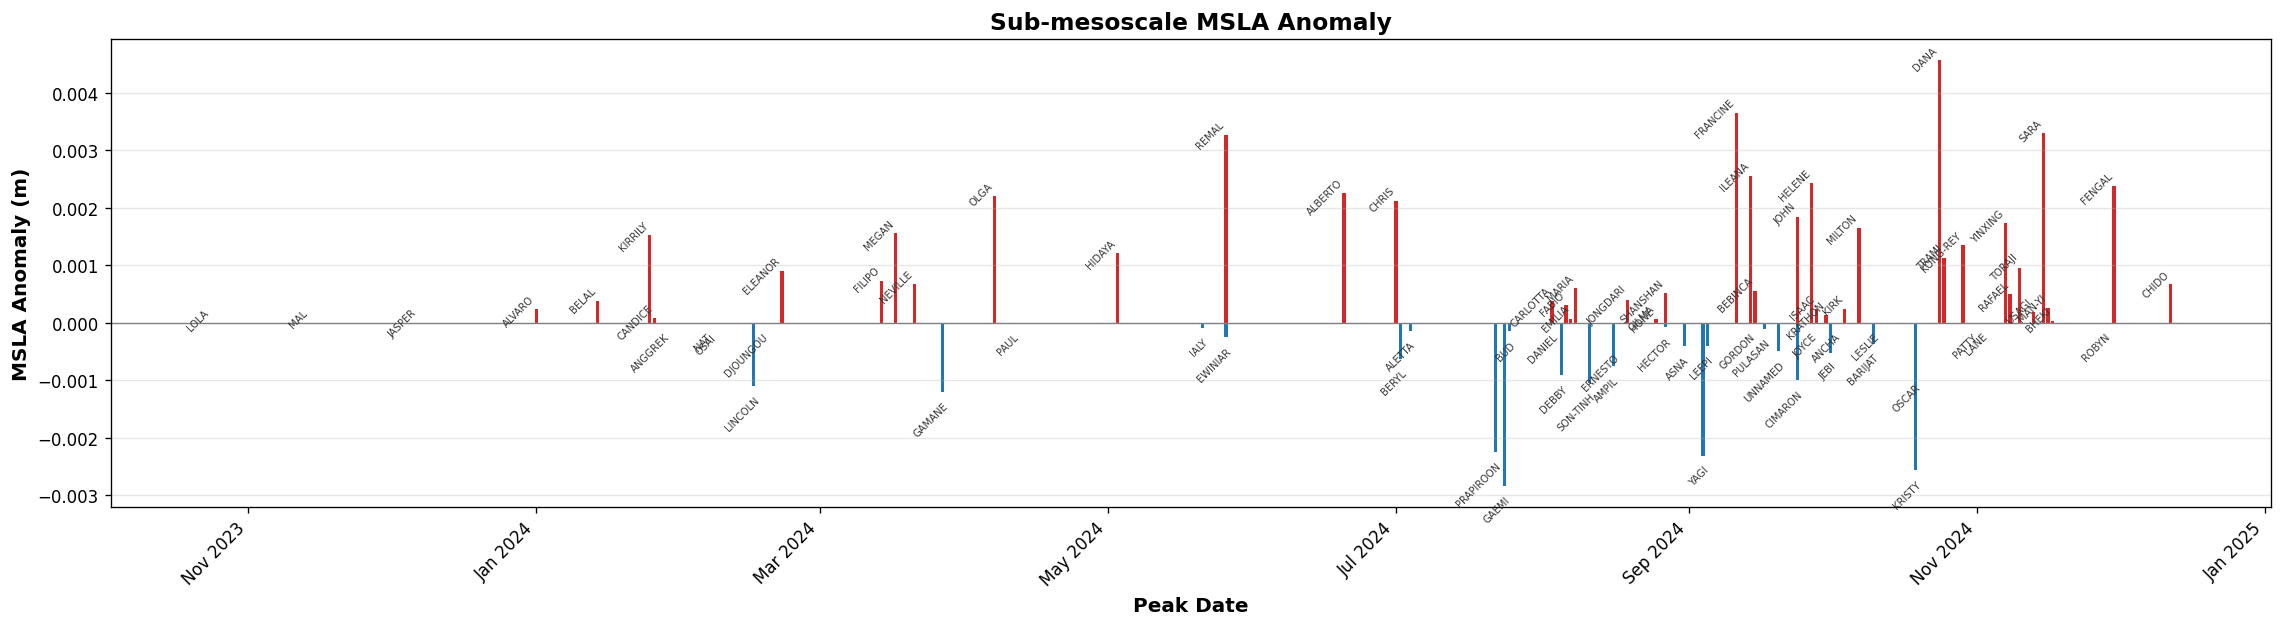

Saved: SST_Large_Seasonal.png


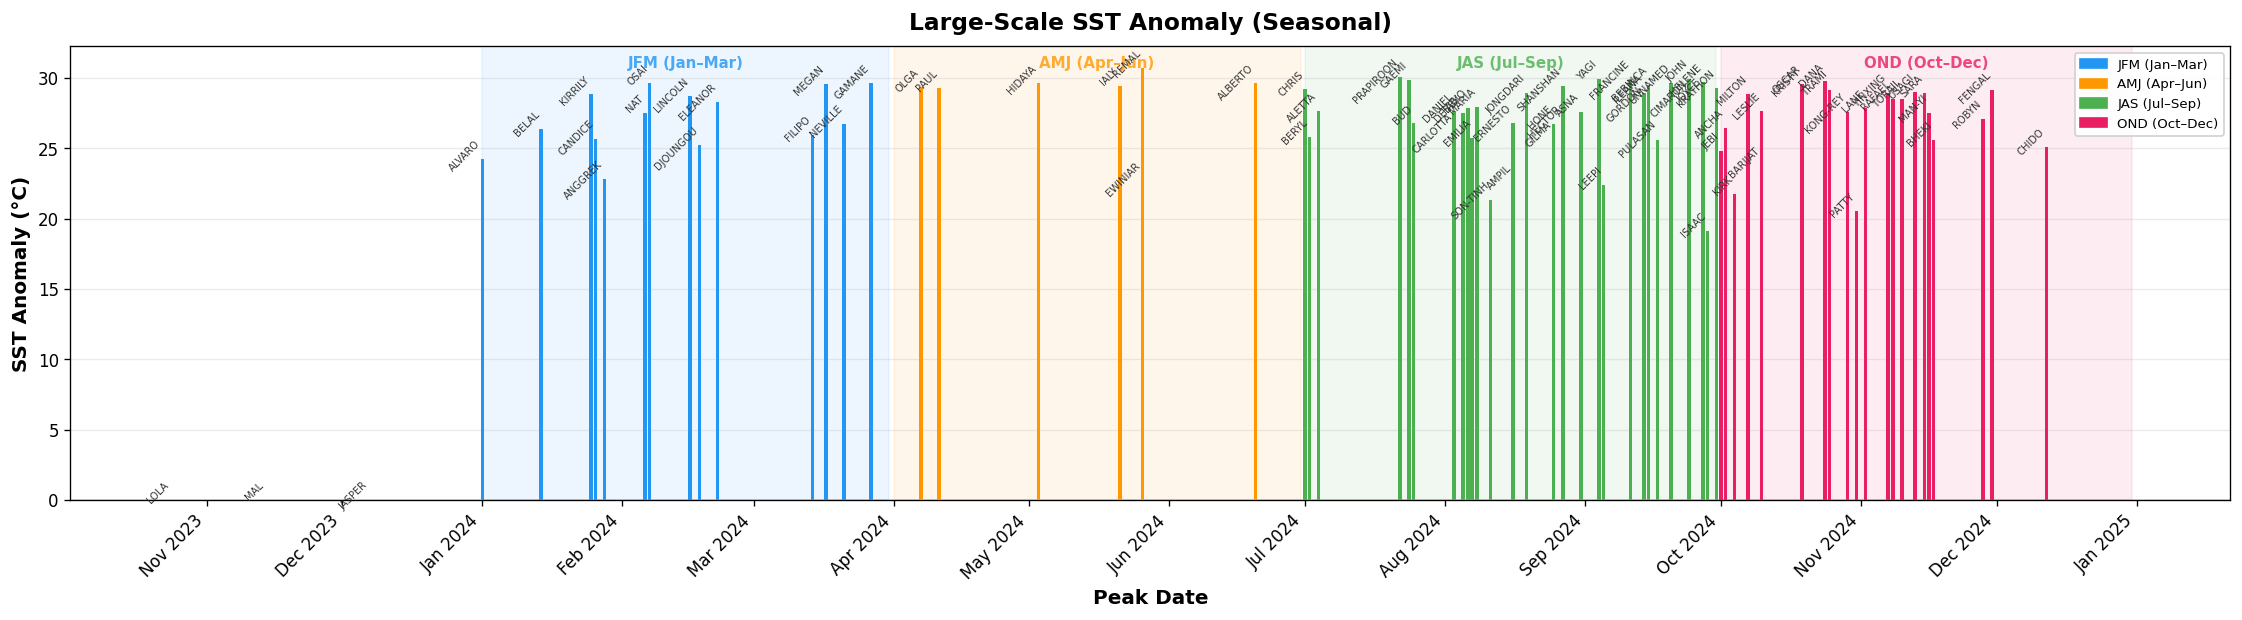

Saved: SST_Meso_Seasonal.png


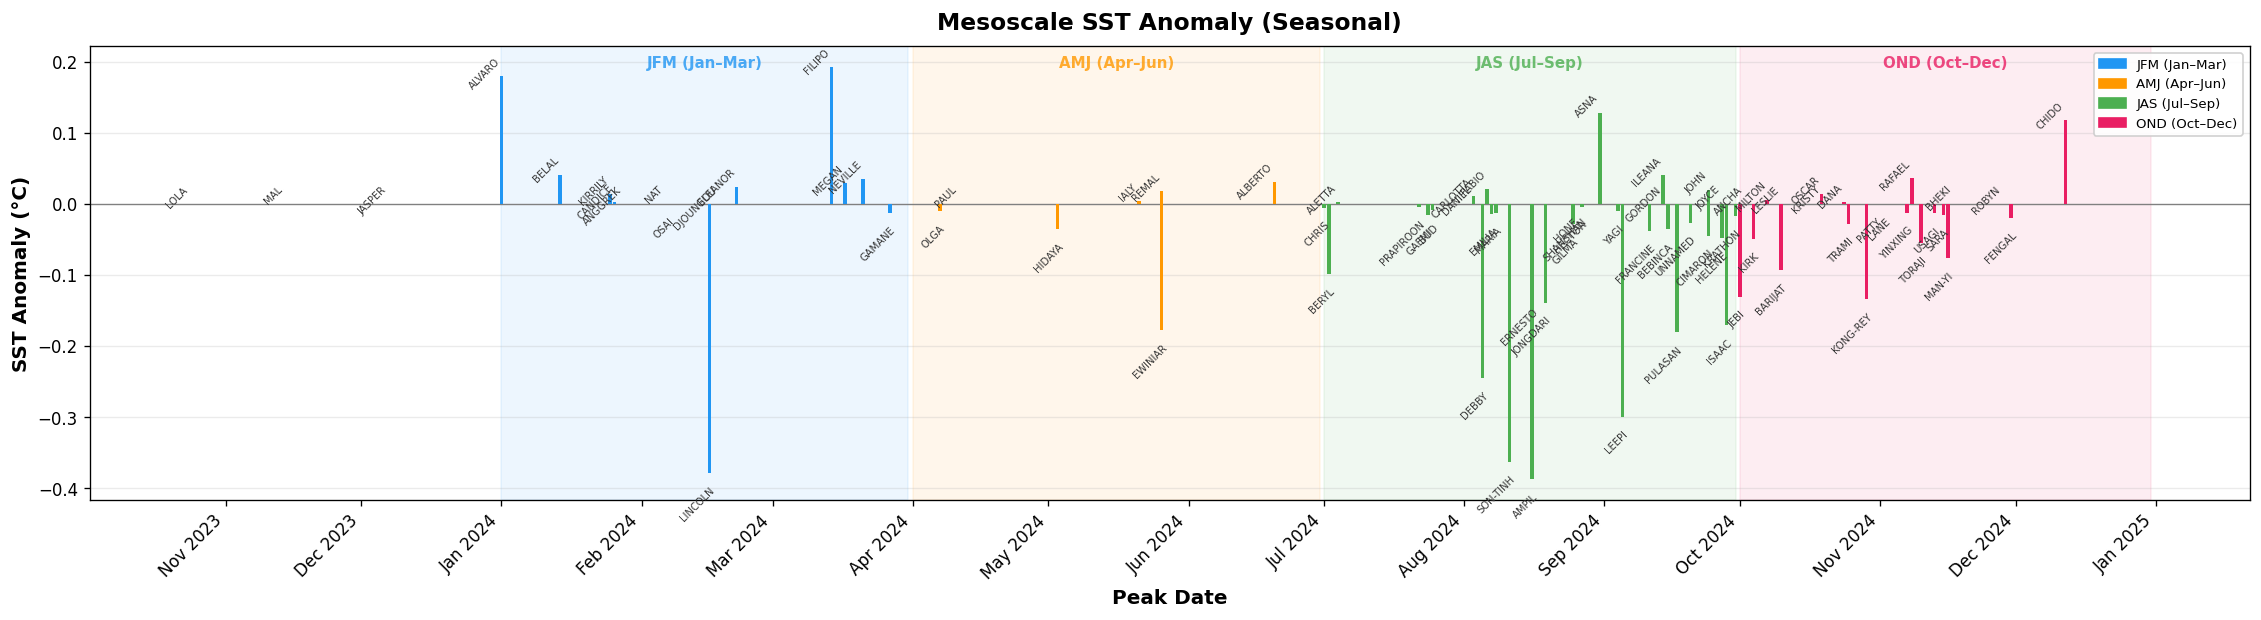

Saved: SST_Submeso_Seasonal.png


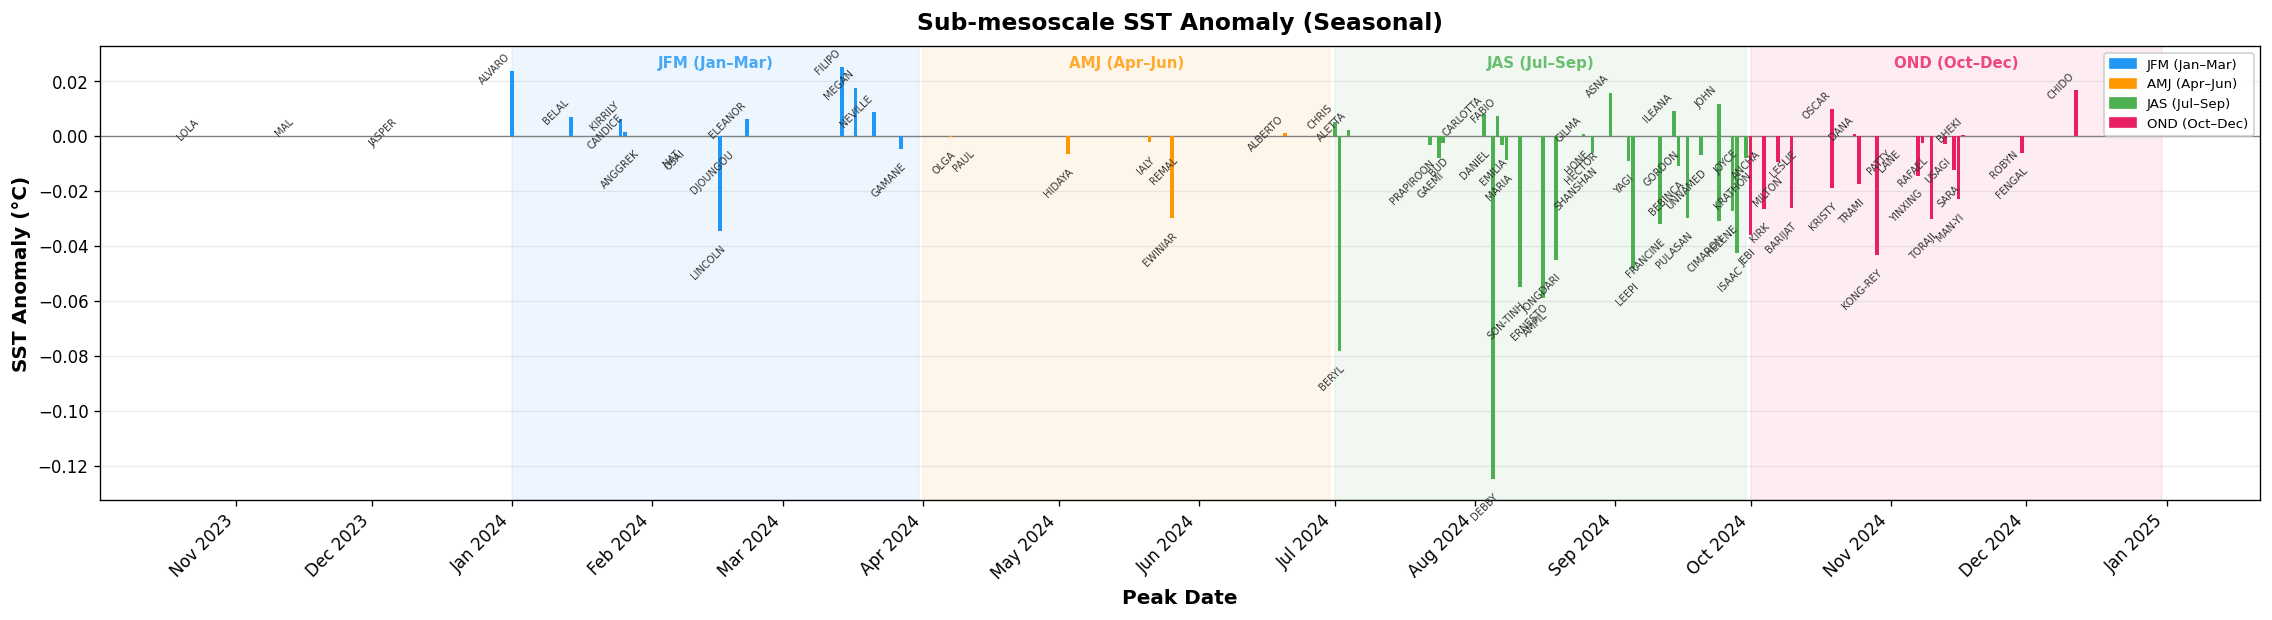

Saved: MSLA_Large_Seasonal.png


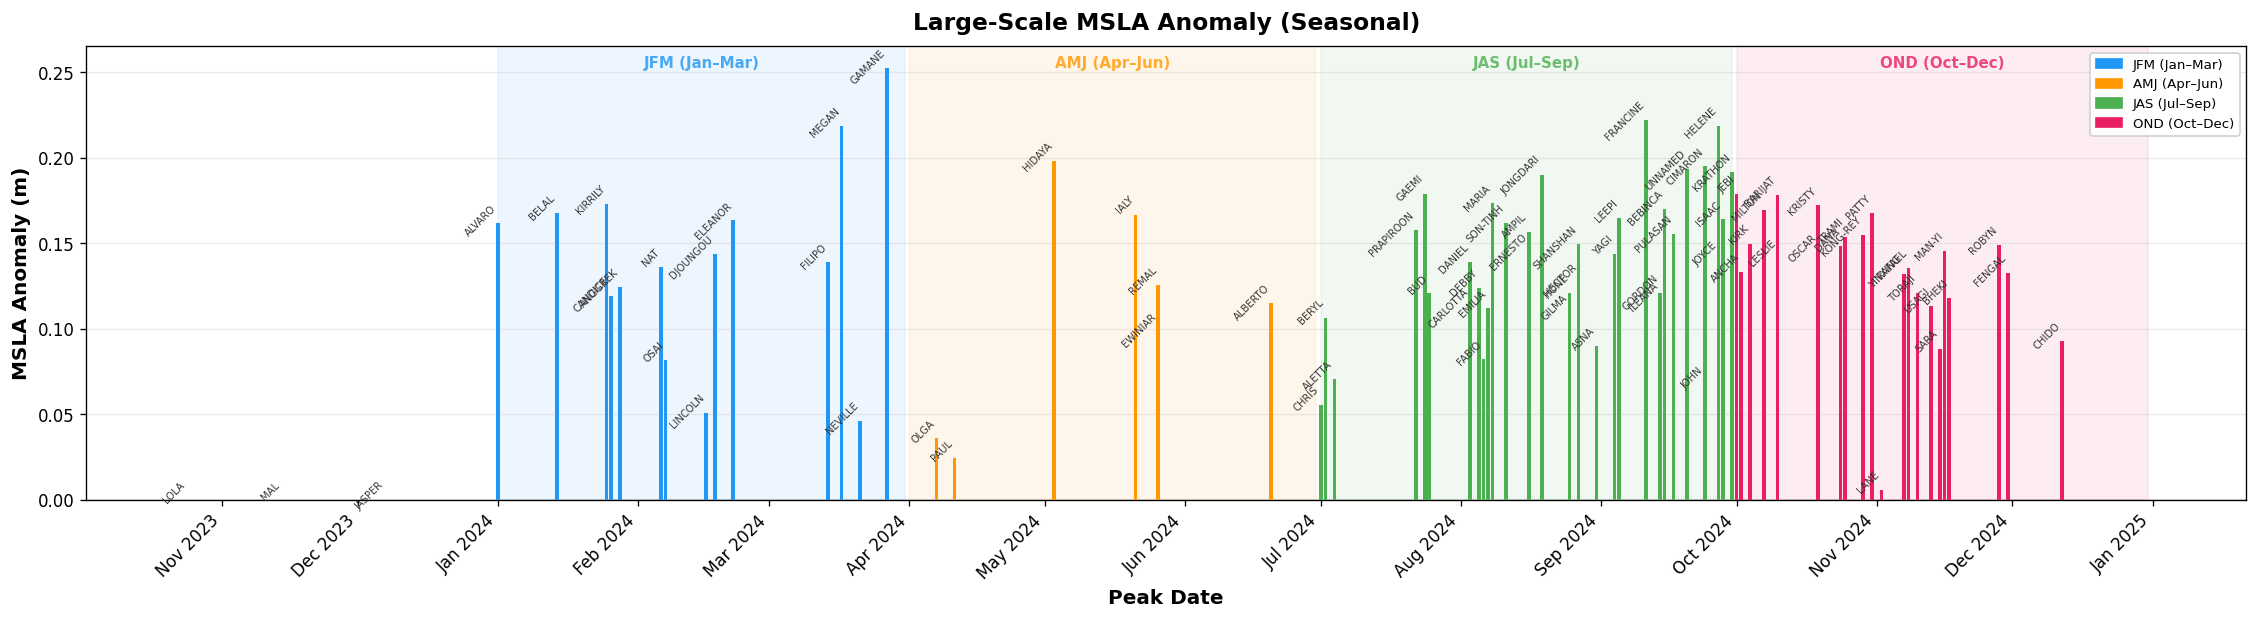

Saved: MSLA_Meso_Seasonal.png


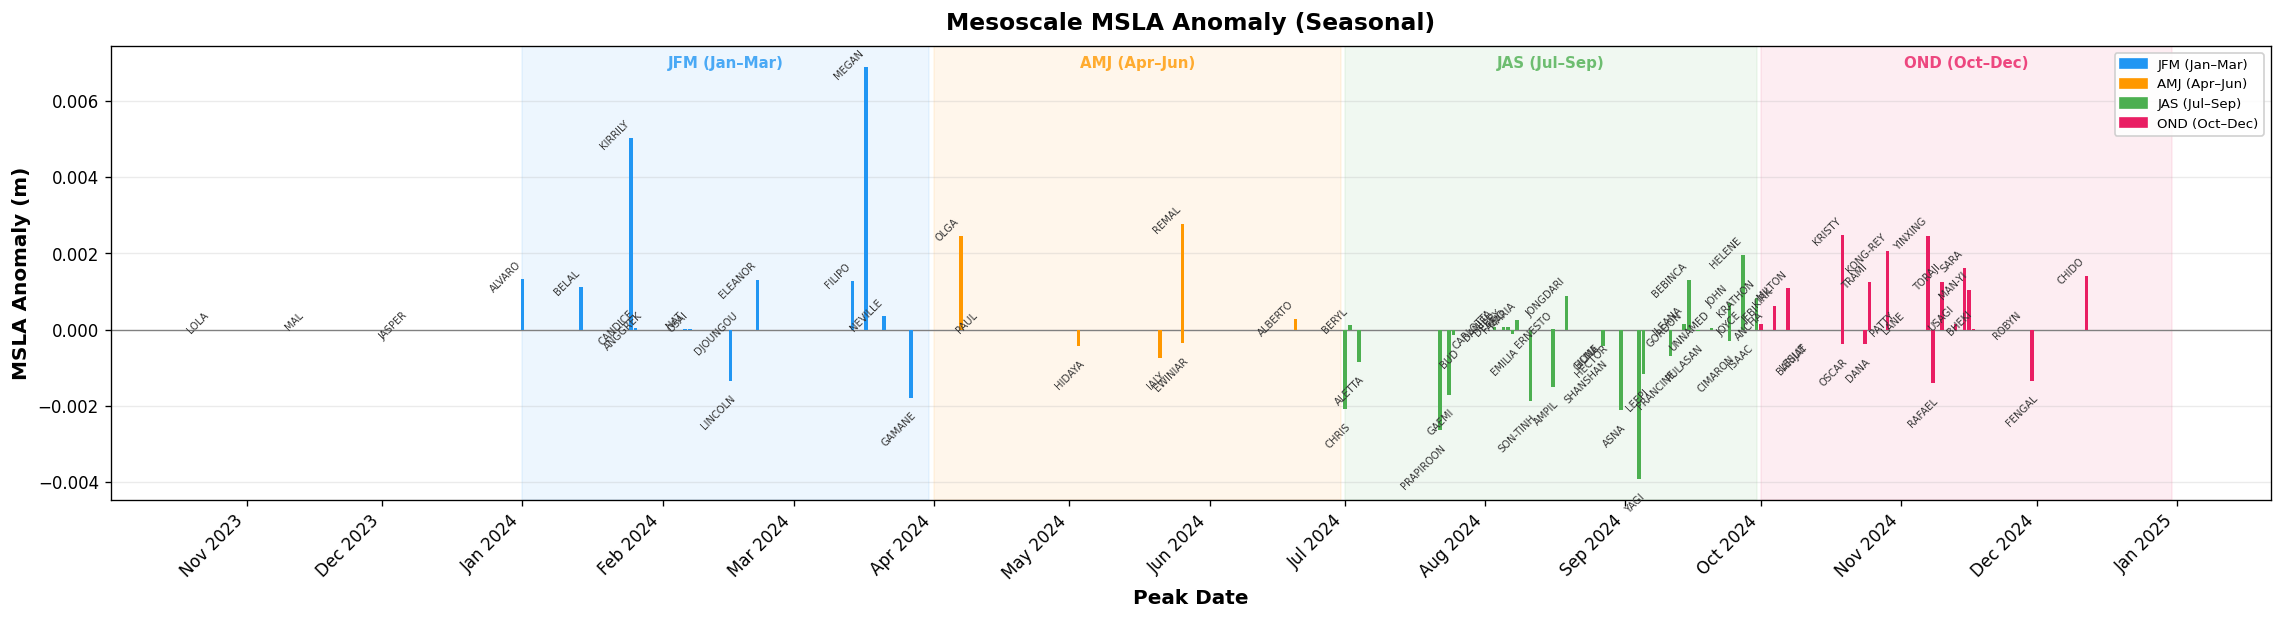

Saved: MSLA_Submeso_Seasonal.png


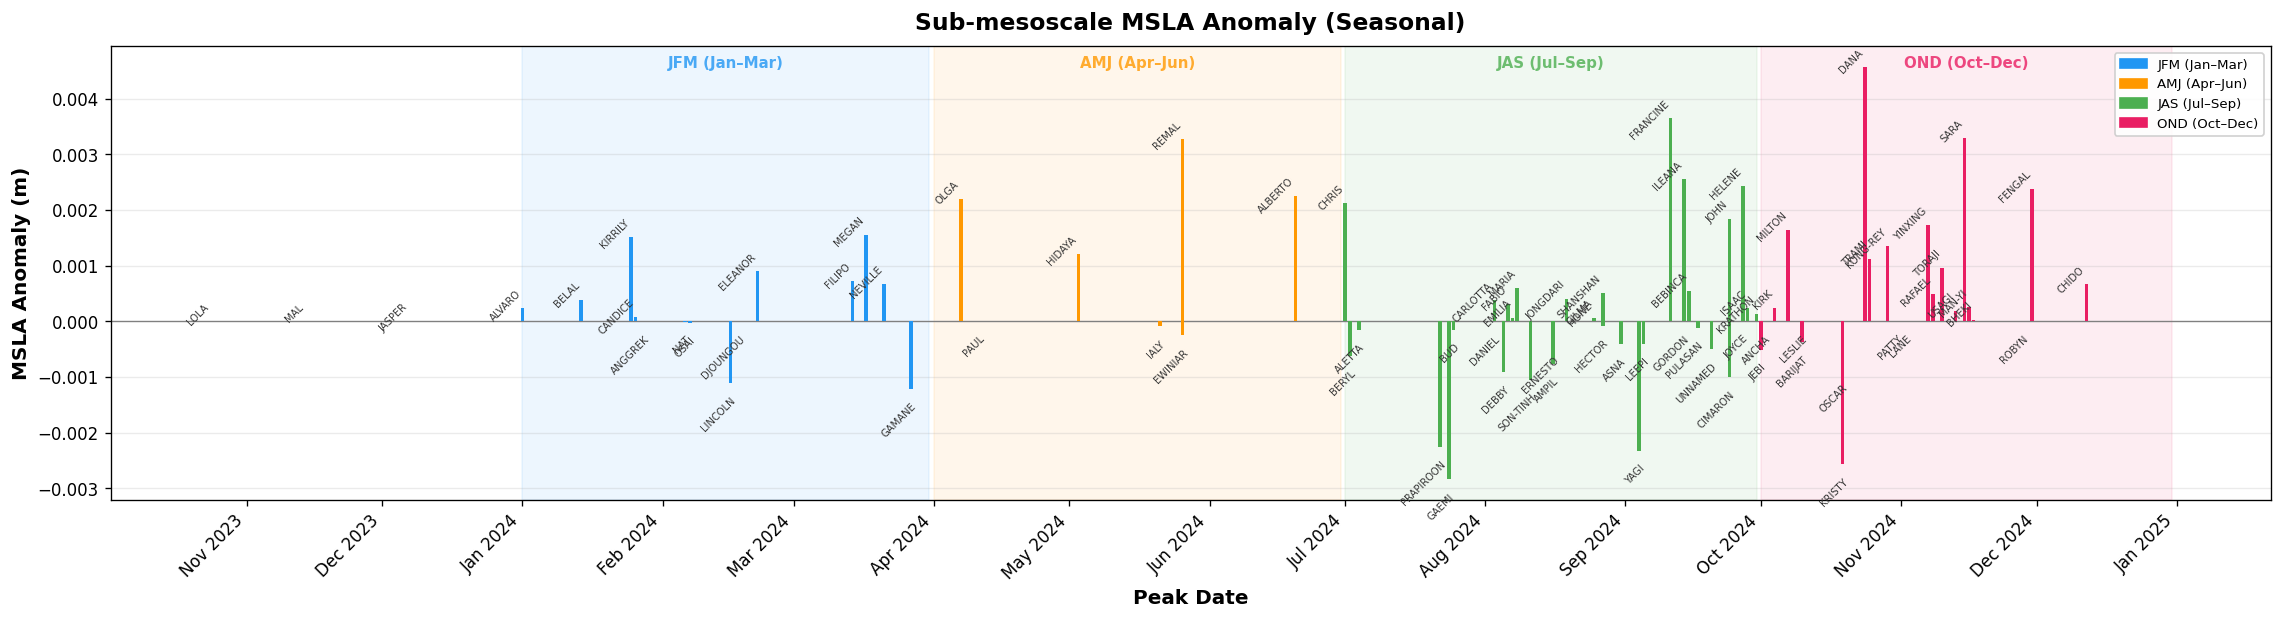

Saved: SST_Seasonal_Summary.png


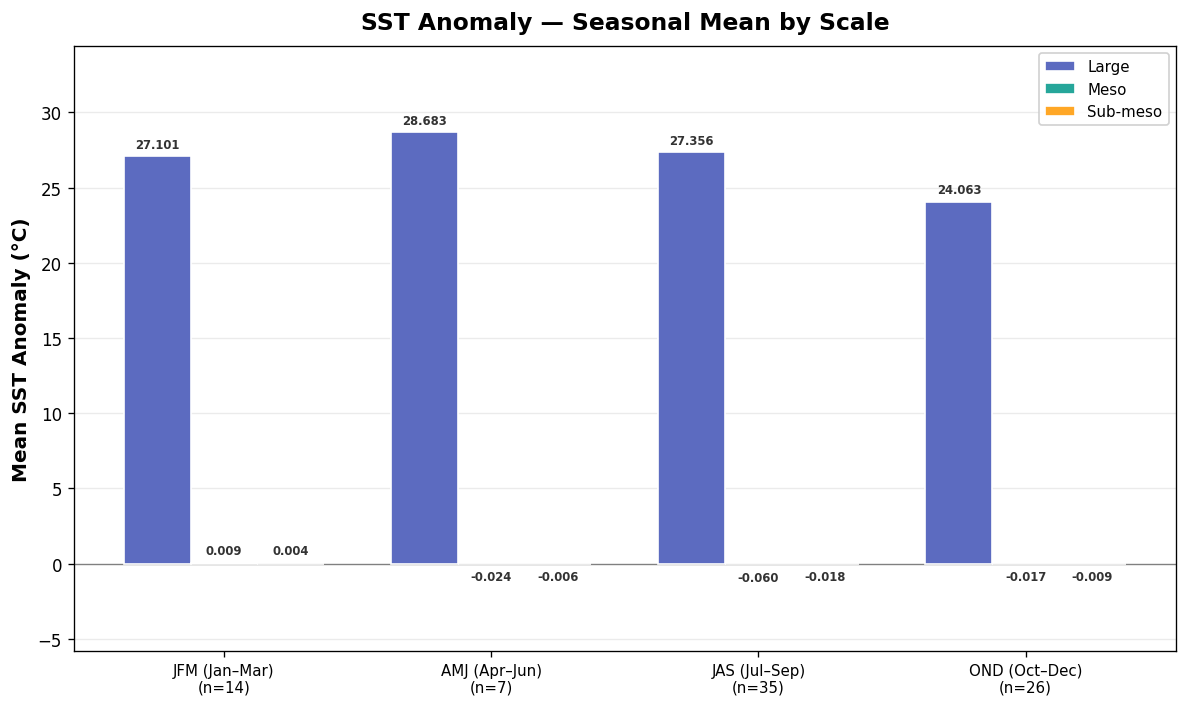

Saved: MSLA_Seasonal_Summary.png


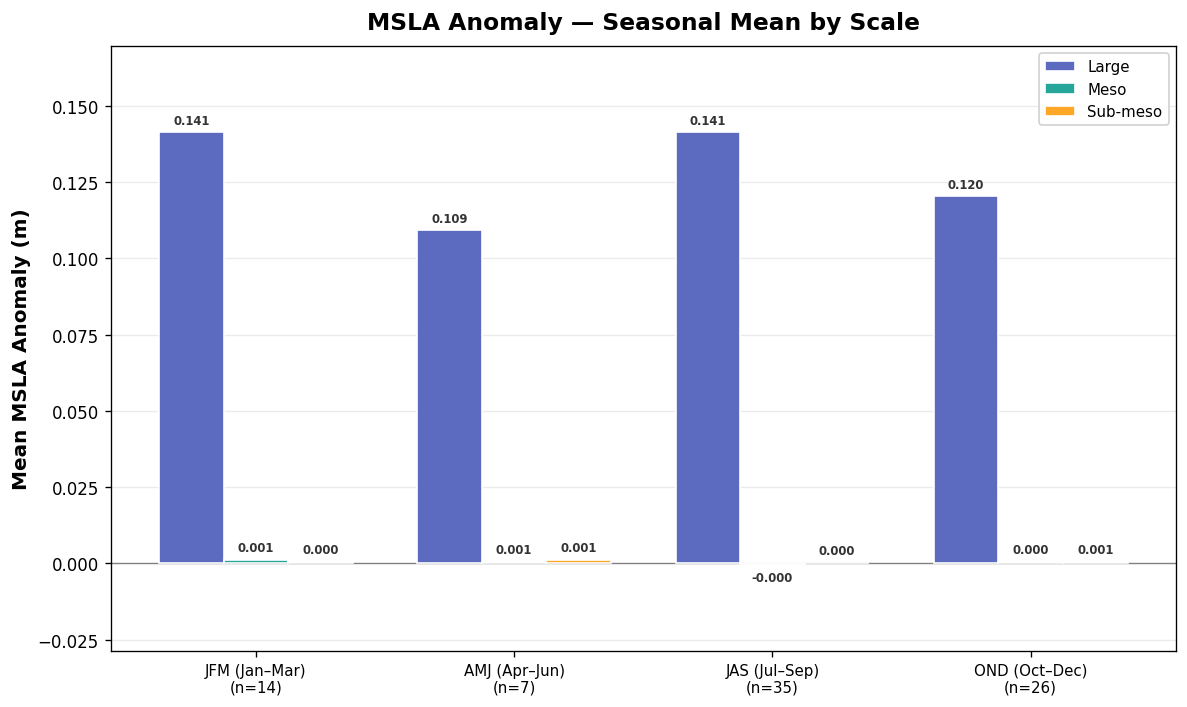

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import pearsonr

# =============================================================================
# Helper – get peak date (same as previous implementations)
# =============================================================================

def _get_peak_date(cyc):
    """Return a datetime.date representing the cyclone's peak.
    Preference order: explicit 'peak' in dates, midpoint of formation/dissipation,
    then midpoint of the analysis window.
    """
    dates = cyc.get('dates', {})
    if dates.get('peak'):
        return pd.to_datetime(dates['peak']).date()
    if dates.get('formation') and dates.get('dissipation'):
        t0 = pd.to_datetime(dates['formation'])
        t1 = pd.to_datetime(dates['dissipation'])
        return (t0 + (t1 - t0) / 2).date()
    windows = _get_analysis_window_ranges(cyc)
    if windows:
        _, s, e = windows[-1]
        t0, t1 = pd.to_datetime(s), pd.to_datetime(e)
        return (t0 + (t1 - t0) / 2).date()
    return None

# =============================================================================
# MULTI‑SCALE ANOMALY CALCULATION (simple mean per cyclone)
# =============================================================================

def calculate_multiscale_anomalies(cyclones_dict, output_csv='cyclone_multiscale_anomalies.csv'):
    """Compute mean SST & MSLA anomalies for each scale (Signal - Baseline)."""
    records = []
    from datetime import timedelta

    for cyc_name, cyc in cyclones_dict.items():
        print(f"Processing {cyc_name} ...", end=' ', flush=True)
        
        # 1. Identify windows explicitly
        # We need a 'Pre' window for the baseline and a 'During' window for the signal
        ad = cyc.get('analysis_dates', {})
        dates = cyc.get('dates', {})
        
        pre_range = ad.get('pre')
        dur_range = ad.get('during') or ad.get('post')
        
        # Fallback if analysis_dates is missing
        if not pre_range or not dur_range:
            fmt = "%Y-%m-%d"
            formation = pd.to_datetime(dates.get('formation'))
            pre_range = ((formation - timedelta(days=5)).strftime(fmt), 
                         (formation - timedelta(days=1)).strftime(fmt))
            dur_range = (dates.get('formation'), dates.get('dissipation'))

        def get_means(date_range):
            if not date_range[0] or not date_range[1]: return None
            d_list = pd.date_range(date_range[0], date_range[1], freq='D')
            l, m, s = [], [], []
            ml, mm, ms = [], [], []
            bbox = _make_square_bbox(cyc['bbox'], cyc['track'])
            for d in d_list:
                # SST
                sst = load_sst_for_date(d, bbox)
                if sst is not None:
                    dec = decompose_sst_field(sst)
                    if dec:
                        if 'large_scale' in dec: l.append(np.nanmean(dec['large_scale']))
                        if 'meso' in dec: m.append(np.nanmean(dec['meso']))
                        if 'submeso' in dec: s.append(np.nanmean(dec['submeso']))
                # MSLA
                msla = load_msla_for_date(d, bbox)
                if msla is not None:
                    dec = decompose_msla_field(msla)
                    if dec:
                        if 'large_scale' in dec: ml.append(np.nanmean(dec['large_scale']))
                        if 'meso' in dec: mm.append(np.nanmean(dec['meso']))
                        if 'submeso' in dec: ms.append(np.nanmean(dec['submeso']))
            return (np.nanmean(l) if l else 0, np.nanmean(m) if m else 0, np.nanmean(s) if s else 0,
                    np.nanmean(ml) if ml else 0, np.nanmean(mm) if mm else 0, np.nanmean(ms) if ms else 0)

        # Calculate Baseline and Signal
        base = get_means(pre_range)
        sign = get_means(dur_range)

        if not base or not sign:
            print("skipped (missing data)"); continue

        rec = {
            'Cyclone': cyc_name,
            'Peak_Date': str(_get_peak_date(cyc)),
            'SST_Large': sign[0] - base[0],
            'SST_Meso': sign[1] - base[1],
            'SST_Submeso': sign[2] - base[2],
            'MSLA_Large': sign[3] - base[3],
            'MSLA_Meso': sign[4] - base[4],
            'MSLA_Submeso': sign[5] - base[5],
        }
        print(f"SST_Base={base[0]:.2f}, Signal={sign[0]:.2f} -> Anom={rec['SST_Large']:.3f}")
        records.append(rec)

    df = pd.DataFrame(records)
    if not df.empty:
        df['Peak_Date'] = pd.to_datetime(df['Peak_Date'])
        df.to_csv(output_csv, index=False)
        print(f"\nSaved true anomalies to {output_csv}")
    return df


# =============================================================================
# PLOT helpers – now using dates on the x‑axis
# =============================================================================

def _bar_plot_per_date(df, col, title, y_label, save_name, save=True):
    """Generic bar plot where the x‑axis is the peak date.
    Positive values are coloured warm/red, negatives cold/blue.
    """
    # keep only rows with both the anomaly and a peak date
    valid = df.dropna(subset=[col, 'Peak_Date']).copy()
    if valid.empty:
        print(f"No data for {col}")
        return
    # ensure dates are pandas Timestamp objects
    valid['Peak_Date'] = pd.to_datetime(valid['Peak_Date'])
    # sort chronologically
    valid = valid.sort_values('Peak_Date')

    colors = ['#d62728' if v >= 0 else '#1f77b4' for v in valid[col]]

    # Optimized dimensions for visibility and layout stability
    fig_width = min(20, max(12, len(valid) * 0.4))
    fig, ax = plt.subplots(figsize=(fig_width, 6))
    # width=0.7 to give some breathing room between bars
    bars = ax.bar(valid['Peak_Date'], valid[col], color=colors, 
                  edgecolor=None, linewidth=0, width=0.7)
    ax.axhline(0, color='gray', linewidth=0.8, zorder=2)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel(y_label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Peak Date', fontsize=12, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    # adjust locator: monthly if ≤12 points, otherwise every 2 months
    if len(valid) <= 12:
        ax.xaxis.set_major_locator(mdates.MonthLocator())
    else:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    fig.autofmt_xdate(rotation=45)
    ax.grid(axis='y', alpha=0.3)
    # annotate each bar with cyclone name
    ymin, ymax = valid[col].min(), valid[col].max()
    offset = 0.02 * (ymax - ymin) if ymax != ymin else 0.01
    for bar, name in zip(bars, valid['Cyclone']):
        height = bar.get_height()
        if height >= 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    height + offset,
                    name,
                    ha='right', va='bottom', fontsize=6,
                    rotation=45, rotation_mode='anchor', color='#333333')
        else:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    height - offset,
                    name,
                    ha='right', va='top', fontsize=6,
                    rotation=45, rotation_mode='anchor', color='#333333')
    
    # Manual adjustment to prevent "Tight layout" warnings and excessive whitespace
    plt.subplots_adjust(bottom=0.25, top=0.9, left=0.08, right=0.98)
    if save:
        plt.savefig(save_name, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_name}")
    plt.show()

def plot_sst_scales(df, save=True):
    """Three bar plots – one per SST scale, x‑axis = peak date.
    This mirrors the original visual intent but respects the temporal axis.
    """
    scales = [
        ('SST_Large',   'Large‑Scale SST Anomaly'),
        ('SST_Meso',    'Mesoscale SST Anomaly'),
        ('SST_Submeso', 'Sub‑mesoscale SST Anomaly')
    ]
    for col, title in scales:
        _bar_plot_per_date(df, col, title, 'SST Anomaly (°C)',
                           f"{col}_vs_Date.png", save)

def plot_msla_scales(df, save=True):
    """Three bar plots – one per MSLA scale, x‑axis = peak date."""
    scales = [
        ('MSLA_Large',   'Large‑Scale MSLA Anomaly'),
        ('MSLA_Meso',    'Mesoscale MSLA Anomaly'),
        ('MSLA_Submeso', 'Sub‑mesoscale MSLA Anomaly')
    ]
    for col, title in scales:
        _bar_plot_per_date(df, col, title, 'MSLA Anomaly (m)',
                           f"{col}_vs_Date.png", save)

# =============================================================================
# SEASONAL CLASSIFICATION
# =============================================================================

SEASON_MAP = {
    1: 'JFM', 2: 'JFM', 3: 'JFM',       # Winter
    4: 'AMJ', 5: 'AMJ', 6: 'AMJ',        # Pre-Monsoon
    7: 'JAS', 8: 'JAS', 9: 'JAS',        # Monsoon
    10: 'OND', 11: 'OND', 12: 'OND',     # Post-Monsoon
}

SEASON_ORDER = ['JFM', 'AMJ', 'JAS', 'OND']

SEASON_COLORS = {
    'JFM': '#2196F3',   # blue  – Winter
    'AMJ': '#FF9800',   # orange – Pre-Monsoon
    'JAS': '#4CAF50',   # green – Monsoon
    'OND': '#E91E63',   # pink  – Post-Monsoon
}

SEASON_LABELS = {
    'JFM': 'JFM (Jan–Mar)',
    'AMJ': 'AMJ (Apr–Jun)',
    'JAS': 'JAS (Jul–Sep)',
    'OND': 'OND (Oct–Dec)',
}


def _assign_season(df):
    """Add a 'Season' column based on the month of Peak_Date."""
    df = df.copy()
    df['Peak_Date'] = pd.to_datetime(df['Peak_Date'])
    df['Season'] = df['Peak_Date'].dt.month.map(SEASON_MAP)
    return df


# =============================================================================
# SEASONAL BAR PLOT – one bar per cyclone, colour = season
# =============================================================================

def _seasonal_bar_plot(df, col, title, y_label, save_name, save=True):
    """Bar plot with x = peak date, bars coloured by season, cyclone names."""
    valid = df.dropna(subset=[col, 'Peak_Date']).copy()
    if valid.empty:
        print(f"No data for {col}"); return

    valid['Peak_Date'] = pd.to_datetime(valid['Peak_Date'])
    valid = _assign_season(valid)
    valid = valid.sort_values('Peak_Date')

    # Optimized dimensions for visibility and layout stability
    fig_width = min(20, max(14, len(valid) * 0.4))
    fig, ax = plt.subplots(figsize=(fig_width, 6))

    # draw seasonal background bands
    year = valid['Peak_Date'].dt.year.mode()[0]
    season_spans = [
        ('JFM', f'{year}-01-01', f'{year}-03-31'),
        ('AMJ', f'{year}-04-01', f'{year}-06-30'),
        ('JAS', f'{year}-07-01', f'{year}-09-30'),
        ('OND', f'{year}-10-01', f'{year}-12-31'),
    ]
    for sname, s0, s1 in season_spans:
        ax.axvspan(pd.to_datetime(s0), pd.to_datetime(s1),
                   alpha=0.08, color=SEASON_COLORS[sname], zorder=0)
        # season label at top (using transform to keep it at the top of the plot)
        mid = pd.to_datetime(s0) + (pd.to_datetime(s1) - pd.to_datetime(s0)) / 2
        ax.text(mid, 0.98, SEASON_LABELS[sname],
                transform=ax.get_xaxis_transform(),
                ha='center', va='top', fontsize=9, fontweight='bold',
                color=SEASON_COLORS[sname], alpha=0.8)

    # bars coloured by season, remove edge to prevent thin bars looking white
    bar_colors = [SEASON_COLORS[s] for s in valid['Season']]
    bars = ax.bar(valid['Peak_Date'], valid[col],
                  color=bar_colors, edgecolor=None, linewidth=0, width=0.8, zorder=3)

    ax.axhline(0, color='gray', linewidth=0.8, zorder=2)

    # annotate cyclone names
    ymin, ymax = valid[col].min(), valid[col].max()
    offset = 0.03 * (ymax - ymin) if ymax != ymin else 0.01
    for bar, name in zip(bars, valid['Cyclone']):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2,
                h + (offset if h >= 0 else -offset),
                name,
                ha='right', va='bottom' if h >= 0 else 'top',
                fontsize=6, rotation=45, rotation_mode='anchor', color='#333333')

    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
    ax.set_ylabel(y_label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Peak Date', fontsize=12, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    fig.autofmt_xdate(rotation=45)
    ax.grid(axis='y', alpha=0.25, zorder=0)

    # season legend
    from matplotlib.patches import Patch
    handles = [Patch(color=SEASON_COLORS[s], label=SEASON_LABELS[s])
               for s in SEASON_ORDER]
    ax.legend(handles=handles, fontsize=8, framealpha=0.9, loc='upper right')

    # Manual adjustment to prevent "Tight layout" warnings and excessive whitespace
    plt.subplots_adjust(bottom=0.25, top=0.88, left=0.08, right=0.98)
    if save:
        plt.savefig(save_name, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_name}")
    plt.show()


def plot_sst_scales_seasonal(df, save=True):
    """Three seasonal bar plots for SST scales."""
    for col, title in [
        ('SST_Large',   'Large-Scale SST Anomaly (Seasonal)'),
        ('SST_Meso',    'Mesoscale SST Anomaly (Seasonal)'),
        ('SST_Submeso', 'Sub-mesoscale SST Anomaly (Seasonal)'),
    ]:
        _seasonal_bar_plot(df, col, title, 'SST Anomaly (°C)',
                           f"{col}_Seasonal.png", save)


def plot_msla_scales_seasonal(df, save=True):
    """Three seasonal bar plots for MSLA scales."""
    for col, title in [
        ('MSLA_Large',   'Large-Scale MSLA Anomaly (Seasonal)'),
        ('MSLA_Meso',    'Mesoscale MSLA Anomaly (Seasonal)'),
        ('MSLA_Submeso', 'Sub-mesoscale MSLA Anomaly (Seasonal)'),
    ]:
        _seasonal_bar_plot(df, col, title, 'MSLA Anomaly (m)',
                           f"{col}_Seasonal.png", save)


# =============================================================================
# SEASONAL SUMMARY – grouped bar chart (mean per season)
# =============================================================================

def plot_seasonal_summary(df, save=True):
    """Two grouped bar charts showing the mean anomaly per season
    for each spatial scale (Large / Meso / Sub-meso).
    One chart for SST, one for MSLA.
    """
    dfs = _assign_season(df)

    for var, cols, y_label, fname in [
        ('SST',  ['SST_Large', 'SST_Meso', 'SST_Submeso'],
         'Mean SST Anomaly (°C)', 'SST_Seasonal_Summary.png'),
        ('MSLA', ['MSLA_Large', 'MSLA_Meso', 'MSLA_Submeso'],
         'Mean MSLA Anomaly (m)', 'MSLA_Seasonal_Summary.png'),
    ]:
        means = dfs.groupby('Season')[cols].mean().reindex(SEASON_ORDER)
        counts = dfs.groupby('Season')['Cyclone'].count().reindex(SEASON_ORDER).fillna(0).astype(int)

        x = np.arange(len(SEASON_ORDER))
        width = 0.25
        scale_labels = ['Large', 'Meso', 'Sub-meso']
        scale_colors = ['#5C6BC0', '#26A69A', '#FFA726']

        fig, ax = plt.subplots(figsize=(10, 6))

        for i, (c, label, clr) in enumerate(zip(cols, scale_labels, scale_colors)):
            vals = means[c].fillna(0).values
            bars = ax.bar(x + i * width, vals, width,
                          label=label, color=clr, edgecolor='white', zorder=3)
            # value labels on bars (with proportional offset and headroom)
            ax.margins(y=0.2)
            for bar, v in zip(bars, vals):
                if not np.isnan(v) and v != 0:
                    h = bar.get_height()
                    offset = 0.01 * (ax.get_ylim()[1] - ax.get_ylim()[0])
                    ax.text(bar.get_x() + bar.get_width() / 2,
                            h + (offset if h >= 0 else -offset),
                            f'{v:.3f}', ha='center', 
                            va='bottom' if h >= 0 else 'top',
                            fontsize=7, color='#333333', fontweight='bold')

        ax.set_xticks(x + width)
        ax.set_xticklabels([f"{SEASON_LABELS[s]}\n(n={counts[s]})"
                            for s in SEASON_ORDER], fontsize=9)
        ax.axhline(0, color='gray', linewidth=0.8)
        ax.set_ylabel(y_label, fontsize=12, fontweight='bold')
        ax.set_title(f'{var} Anomaly — Seasonal Mean by Scale',
                     fontsize=14, fontweight='bold', pad=10)
        ax.legend(fontsize=9, framealpha=0.9)
        ax.grid(axis='y', alpha=0.25, zorder=0)

        plt.tight_layout()
        if save:
            plt.savefig(fname, dpi=150, bbox_inches='tight')
            print(f"Saved: {fname}")
        plt.show()


# =============================================================================
# QUICK RUNNER (uncomment to execute)
# =============================================================================
df_multi = calculate_multiscale_anomalies(cyclones)
# df_multi = pd.read_csv('cyclone_multiscale_anomalies.csv')

# --- original date-axis plots ---
plot_sst_scales(df_multi)
plot_msla_scales(df_multi)

# --- seasonal colour-coded plots ---
plot_sst_scales_seasonal(df_multi)
plot_msla_scales_seasonal(df_multi)

# --- seasonal summary (grouped bars per season) ---
plot_seasonal_summary(df_multi)


  CYCLONE OCEAN COUPLING INDEX (COCI) ANALYSIS

Merged 79 cyclones with SST/MSLA anomalies + intensity.

─── Validation: Pearson r (Index vs Max Wind) ───
                  Index  Pearson_r      p_value
 A: Equal-Weight Linear   0.619128 1.186803e-09
   B: Ocean × Intensity  -0.007024 9.510128e-01
C: Correlation-Weighted   0.192954 8.843263e-02
          D: Ocean-Only   0.145331 2.012705e-01

★ BEST INDEX: A: Equal-Weight Linear  (r = 0.6191)

─── Mean COCI by Category ───
            COCI_A    COCI_B    COCI_C    COCI_D  Count
Category                                               
TS       -0.300072  0.245632 -0.105311 -0.012810     37
1        -0.140638  0.089160 -0.074815 -0.150388     12
2         0.180220  0.087856  0.337234  0.086277      7
3         0.303658  0.089676 -0.261471  0.083965      2
4         0.444693  0.146175  0.042754  0.022518     17
5         0.840424  1.105599  0.557444  0.280983      4

Correlation weights (Option C):
  corr(SST, Vmax)  = 0.0314
  corr(MSLA, 

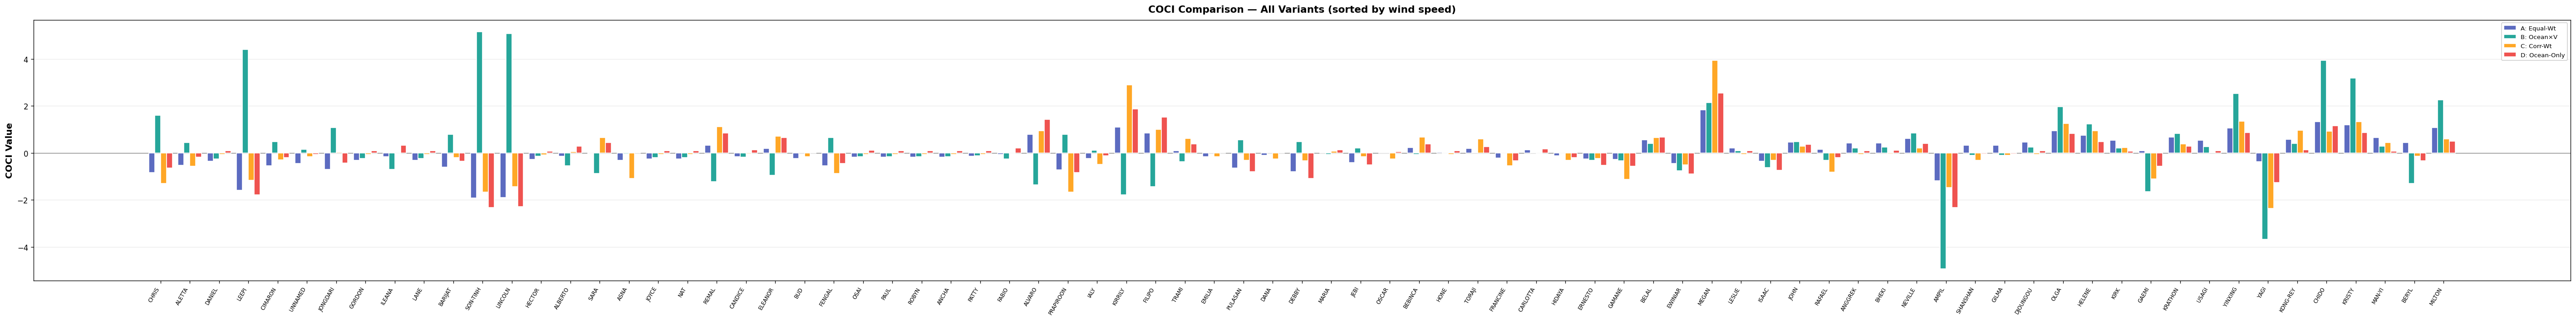

Saved: COCI_Best_Scatter.png


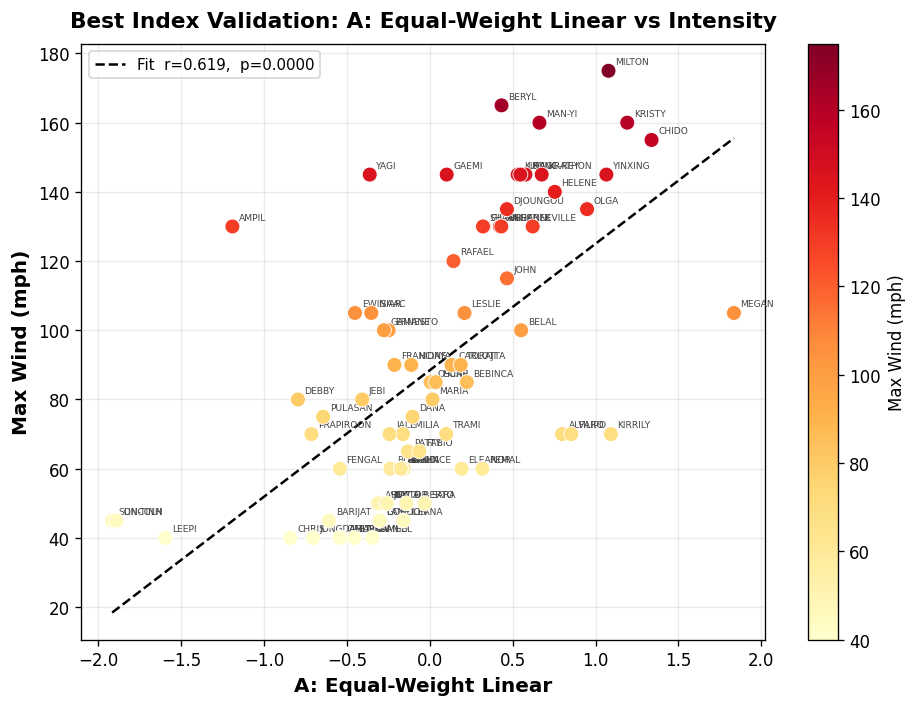

Saved: COCI_Category_Means.png


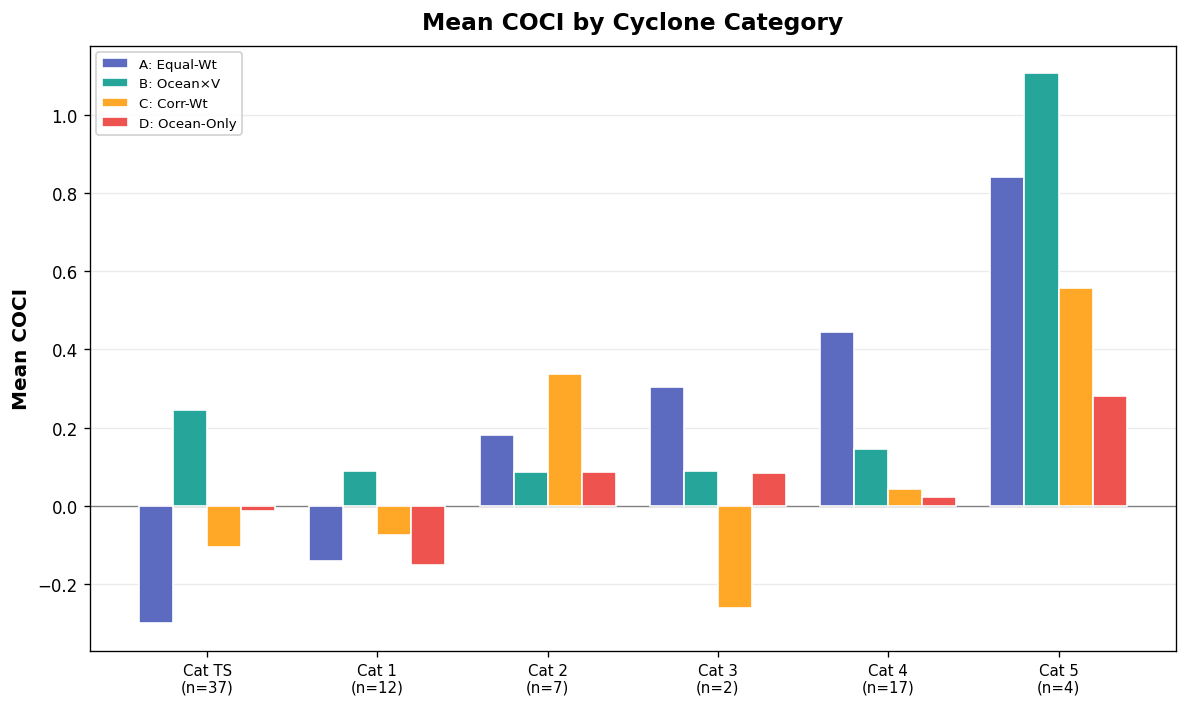


Full results → coci_results.csv
Validation   → coci_validation.csv


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import json

# =============================================================================
# STEP 0 — LOAD INTENSITY DATA FROM JSON
# =============================================================================

def load_intensity_data(json_path='cyclone_info_2024_padded.json'):
    """Extract max_wind_mph and min_pressure_mb for every storm."""
    with open(json_path, 'r') as f:
        data = json.load(f)

    records = []
    for basin_key, basin in data.items():
        if not isinstance(basin, dict) or 'storms' not in basin:
            continue
        for s in basin['storms']:
            records.append({
                'Cyclone': s['name'],
                'Category': s.get('category', ''),
                'Max_Wind_mph': s.get('max_wind_mph', np.nan),
                'Min_Pressure_mb': s.get('min_pressure_mb', np.nan),
            })
    return pd.DataFrame(records)


# =============================================================================
# STEP 1 — MERGE ANOMALIES + INTENSITY
# =============================================================================

def build_coci_dataframe(anomaly_csv='cyclone_multiscale_anomalies.csv',
                         json_path='cyclone_info_2024_padded.json'):
    """Merge the pre-computed SST/MSLA anomalies with intensity metadata."""
    df_anom = pd.read_csv(anomaly_csv)
    df_int  = load_intensity_data(json_path)

    # normalise names to uppercase so CSV and JSON always match
    df_anom['Cyclone'] = df_anom['Cyclone'].str.upper()
    df_int['Cyclone']  = df_int['Cyclone'].str.upper()

    # merge on cyclone name
    df = df_anom.merge(df_int, on='Cyclone', how='left')

    # use meso-scale as primary anomaly (most relevant for cyclone coupling)
    df = df.rename(columns={'SST_Meso': 'SST_Anom', 'MSLA_Meso': 'MSLA_Anom'})

    # drop rows missing critical columns
    df = df.dropna(subset=['SST_Anom', 'MSLA_Anom', 'Max_Wind_mph'])

    # z-score normalisation
    for col, zcol in [('SST_Anom', 'Z_SST'),
                      ('MSLA_Anom', 'Z_MSLA'),
                      ('Max_Wind_mph', 'Z_V')]:
        mu, sigma = df[col].mean(), df[col].std()
        df[zcol] = (df[col] - mu) / sigma if sigma > 0 else 0.0

    return df


# =============================================================================
# STEP 2 — COMPUTE ALL INDEX VARIANTS
# =============================================================================

def compute_all_indices(df):
    """Add columns for every COCI formulation."""

    # --- Option A: Equal-weight linear ---
    df['COCI_A'] = (df['Z_SST'] + df['Z_MSLA'] + df['Z_V']) / 3.0

    # --- Option B: Ocean forcing × intensity (multiplicative) ---
    df['COCI_B'] = (df['Z_SST'] + df['Z_MSLA']) * df['Z_V']

    # --- Option C: Correlation-weighted (data-driven) ---
    if len(df) >= 2:
        r_sst, _  = pearsonr(df['SST_Anom'], df['Max_Wind_mph'])
        r_msla, _ = pearsonr(df['MSLA_Anom'], df['Max_Wind_mph'])
    else:
        r_sst, r_msla = 0.5, 0.5
    w_sst  = abs(r_sst)
    w_msla = abs(r_msla)
    w_sum  = w_sst + w_msla
    if w_sum > 0:
        df['COCI_C'] = (w_sst * df['Z_SST'] + w_msla * df['Z_MSLA']) / w_sum
    else:
        df['COCI_C'] = (df['Z_SST'] + df['Z_MSLA']) / 2.0

    # --- Option D: Simple ocean-only (no intensity) ---
    df['COCI_D'] = (df['Z_SST'] + df['Z_MSLA']) / 2.0

    # store the correlation weights for reporting
    df.attrs['r_sst']  = r_sst
    df.attrs['r_msla'] = r_msla

    return df


# =============================================================================
# STEP 3 — CLASSIFY EACH CYCLONE
# =============================================================================

def classify_coci(value):
    if value > 2:
        return 'Extreme'
    elif value > 1:
        return 'Strong'
    elif value > 0:
        return 'Moderate'
    elif value > -1:
        return 'Weak'
    else:
        return 'Suppressed'


def add_classifications(df):
    for idx_col in ['COCI_A', 'COCI_B', 'COCI_C', 'COCI_D']:
        df[f'{idx_col}_Class'] = df[idx_col].apply(classify_coci)
    return df


# =============================================================================
# STEP 4 — VALIDATE: correlate each index with Vmax
# =============================================================================

def validate_indices(df):
    """Return a summary DataFrame of validation metrics."""
    results = []
    for idx_col, label in [
        ('COCI_A', 'A: Equal-Weight Linear'),
        ('COCI_B', 'B: Ocean × Intensity'),
        ('COCI_C', 'C: Correlation-Weighted'),
        ('COCI_D', 'D: Ocean-Only'),
    ]:
        if len(df) >= 2:
            r, p = pearsonr(df[idx_col], df['Max_Wind_mph'])
        else:
            r, p = 0.0, 1.0
        results.append({
            'Index': label,
            'Column': idx_col,
            'Pearson_r': r,
            'p_value': p,
            'Mean': df[idx_col].mean(),
            'Std': df[idx_col].std(),
        })
    return pd.DataFrame(results)


# =============================================================================
# STEP 5 — VALIDATE: mean COCI by cyclone category
# =============================================================================

def category_validation(df):
    """Mean of each index grouped by cyclone category."""
    cat_order = ['TS', '1', '2', '3', '4', '5']
    idx_cols = ['COCI_A', 'COCI_B', 'COCI_C', 'COCI_D']
    grp = df.groupby('Category')[idx_cols].mean()
    grp = grp.reindex([c for c in cat_order if c in grp.index])
    grp['Count'] = df.groupby('Category')['Cyclone'].count()
    return grp


# =============================================================================
# PLOTS
# =============================================================================

def plot_index_comparison(df, save=True):
    """Bar chart comparing all 4 COCI variants for every cyclone."""
    idx_cols = ['COCI_A', 'COCI_B', 'COCI_C', 'COCI_D']
    labels   = ['A: Equal-Wt', 'B: Ocean×V', 'C: Corr-Wt', 'D: Ocean-Only']
    colors   = ['#5C6BC0', '#26A69A', '#FFA726', '#EF5350']

    df_sorted = df.sort_values('Max_Wind_mph')
    x = np.arange(len(df_sorted))
    width = 0.2

    fig, ax = plt.subplots(figsize=(max(14, len(df_sorted) * 0.6), 6))
    for i, (col, lab, clr) in enumerate(zip(idx_cols, labels, colors)):
        ax.bar(x + i * width, df_sorted[col].values, width,
               label=lab, color=clr, edgecolor='white', zorder=3)

    ax.set_xticks(x + 1.5 * width)
    ax.set_xticklabels(df_sorted['Cyclone'], rotation=60, fontsize=7, ha='right')
    ax.axhline(0, color='gray', linewidth=0.8)
    ax.set_ylabel('COCI Value', fontsize=12, fontweight='bold')
    ax.set_title('COCI Comparison — All Variants (sorted by wind speed)',
                 fontsize=13, fontweight='bold', pad=10)
    ax.legend(fontsize=8, framealpha=0.9)
    ax.grid(axis='y', alpha=0.25, zorder=0)
    plt.tight_layout()
    if save:
        plt.savefig('COCI_Comparison.png', dpi=150, bbox_inches='tight')
        print("Saved: COCI_Comparison.png")
    plt.show()


def plot_best_index_scatter(df, best_col, best_label, save=True):
    """Scatter plot: best COCI vs Max Wind with regression."""
    r, p = pearsonr(df[best_col], df['Max_Wind_mph'])

    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(df[best_col], df['Max_Wind_mph'],
                    c=df['Max_Wind_mph'], cmap='YlOrRd',
                    s=80, edgecolors='white', linewidths=0.5, zorder=4)
    # annotate
    for _, row in df.iterrows():
        ax.annotate(row['Cyclone'],
                    xy=(row[best_col], row['Max_Wind_mph']),
                    xytext=(4, 4), textcoords='offset points',
                    fontsize=5.5, color='#444444')
    # regression
    m, b = np.polyfit(df[best_col].values, df['Max_Wind_mph'].values, 1)
    xs = np.linspace(df[best_col].min(), df[best_col].max(), 200)
    ax.plot(xs, m * xs + b, 'k--', lw=1.5,
            label=f'Fit  r={r:.3f},  p={p:.4f}')

    ax.set_xlabel(f'{best_label}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Max Wind (mph)', fontsize=12, fontweight='bold')
    ax.set_title(f'Best Index Validation: {best_label} vs Intensity',
                 fontsize=13, fontweight='bold', pad=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)
    plt.colorbar(sc, ax=ax, label='Max Wind (mph)')
    plt.tight_layout()
    if save:
        plt.savefig('COCI_Best_Scatter.png', dpi=150, bbox_inches='tight')
        print("Saved: COCI_Best_Scatter.png")
    plt.show()


def plot_category_means(cat_df, save=True):
    """Grouped bar chart of mean COCI by cyclone category."""
    idx_cols = ['COCI_A', 'COCI_B', 'COCI_C', 'COCI_D']
    labels   = ['A: Equal-Wt', 'B: Ocean×V', 'C: Corr-Wt', 'D: Ocean-Only']
    colors   = ['#5C6BC0', '#26A69A', '#FFA726', '#EF5350']

    x = np.arange(len(cat_df))
    width = 0.2

    fig, ax = plt.subplots(figsize=(10, 6))
    for i, (col, lab, clr) in enumerate(zip(idx_cols, labels, colors)):
        vals = cat_df[col].fillna(0).values
        ax.bar(x + i * width, vals, width,
               label=lab, color=clr, edgecolor='white', zorder=3)

    ax.set_xticks(x + 1.5 * width)
    ax.set_xticklabels([f"Cat {c}\n(n={int(cat_df.loc[c, 'Count'])})"
                        for c in cat_df.index], fontsize=9)
    ax.axhline(0, color='gray', linewidth=0.8)
    ax.set_ylabel('Mean COCI', fontsize=12, fontweight='bold')
    ax.set_title('Mean COCI by Cyclone Category',
                 fontsize=14, fontweight='bold', pad=10)
    ax.legend(fontsize=8, framealpha=0.9)
    ax.grid(axis='y', alpha=0.25, zorder=0)
    plt.tight_layout()
    if save:
        plt.savefig('COCI_Category_Means.png', dpi=150, bbox_inches='tight')
        print("Saved: COCI_Category_Means.png")
    plt.show()


# =============================================================================
# MASTER RUNNER
# =============================================================================

def run_coci_analysis(anomaly_csv='cyclone_multiscale_anomalies.csv',
                      json_path='cyclone_info_2024_padded.json',
                      save=True):
    """End-to-end COCI analysis. Returns (df, validation, category, best_col)."""

    print("=" * 60)
    print("  CYCLONE OCEAN COUPLING INDEX (COCI) ANALYSIS")
    print("=" * 60)

    # 1. Build merged dataframe
    df = build_coci_dataframe(anomaly_csv, json_path)
    print(f"\nMerged {len(df)} cyclones with SST/MSLA anomalies + intensity.\n")

    # 2. Compute all indices
    df = compute_all_indices(df)
    df = add_classifications(df)

    # 3. Validate
    val_df = validate_indices(df)
    print("─── Validation: Pearson r (Index vs Max Wind) ───")
    print(val_df[['Index', 'Pearson_r', 'p_value']].to_string(index=False))

    # 4. Identify best
    best_row = val_df.loc[val_df['Pearson_r'].abs().idxmax()]
    best_col = best_row['Column']
    best_label = best_row['Index']
    print(f"\n★ BEST INDEX: {best_label}  (r = {best_row['Pearson_r']:.4f})")

    # 5. Category validation
    cat_df = category_validation(df)
    print("\n─── Mean COCI by Category ───")
    print(cat_df.to_string())

    # 6. Correlation weights used in Option C
    print(f"\nCorrelation weights (Option C):")
    print(f"  corr(SST, Vmax)  = {df.attrs.get('r_sst', 0):.4f}")
    print(f"  corr(MSLA, Vmax) = {df.attrs.get('r_msla', 0):.4f}")

    # 7. Plots
    plot_index_comparison(df, save)
    plot_best_index_scatter(df, best_col, best_label, save)
    plot_category_means(cat_df, save)

    # 8. Save full table
    out_csv = 'coci_results.csv'
    df.to_csv(out_csv, index=False)
    print(f"\nFull results → {out_csv}")

    val_csv = 'coci_validation.csv'
    val_df.to_csv(val_csv, index=False)
    print(f"Validation   → {val_csv}")

    return df, val_df, cat_df, best_col


# =============================================================================
# RUN  (uncomment to execute)
# =============================================================================
df_coci, val, cat, best = run_coci_analysis()


---
# PHASE 4: Cyclone Response by Scale â€” Diagnostic Summary

## 4.1 Key Analysis Questions

| Question | Analysis Approach |
|----------|-------------------|
| **Which scale shows dominant SST cooling?** | Compare amplitude of large-scale vs mesoscale cooling |
| **Sub-meso MSLA eddy structures?** | Look for ~50-100 km dipole/vortex patterns near track |
| **Large-scale MSLA consistent with Ekman pumping?** | Check for negative MSLA anomaly (upwelling) along track |
| **Cyclone intensity comparison** | Remal vs Dana: track speed, wind forcing differences |
| **Pre-existing eddy influence?** | Check MSLA before cyclone for warm/cold core eddies |

### Expected Signals by Scale

| Variable | Large-scale | Mesoscale | Sub-mesoscale |
|----------|-------------|-----------|---------------|
| **SST** | Cooling wake (2-5Â°C drop) | Eddy-induced SST anomalies | Frontal/filament structures |
| **MSLA** | Negative anomaly (Ekman suction) | Pre-existing eddies modulated | Submesoscale instabilities |

In [22]:
# print("=" * 70)
# print("ANALYSIS COMPLETE - ALL 4 PHASES")
# print("=" * 70)
# print(f"\nOutput directory: {OUTPUT_DIR}")
# print(f"\nGenerated outputs:")
# print(f"  1. Cyclone tracks map: cyclone_tracks_2024.png")
# print(f"  2. First-look plots: REMAL_FirstLook/ and DANA_FirstLook/")
# print(f"  3. Scale decomposition: REMAL_ScaleDecomp/ and DANA_ScaleDecomp/")
# print(f"  4. Time series comparison: scale_timeseries_comparison.png")
# print(f"  5. Time series data: *_timeseries.csv")
# print(f"  6. Diagnostic summary figure: phase4_diagnostic_summary.png")
# print(f"  7. Written report: diagnostic_report.txt")
# print(f"\nPhases covered:")
# print(f"  - Phase 1: Date-wise inventory & first-look plots")
# print(f"  - Phase 2: 2D Gaussian filter scale separation")
# print(f"  - Phase 3: Scale-wise visual comparison & time series")
# print(f"  - Phase 4: Cyclone response diagnostic summary")
# print(f"\nKey diagnostics computed:")
# print(f"  - Dominant SST cooling scale identification")
# print(f"  - MSLA Ekman pumping signature analysis")
# print(f"  - Cyclone intensity & track comparison")
# print(f"  - Pre-existing eddy field analysis")

In [23]:
# def analyze_dominant_cooling_scale(df_remal, df_dana):
#     """
#     Analyze which spatial scale shows the dominant SST cooling signal.
    
#     Computes cooling amplitude (pre-cyclone minus during/post) for each scale.
#     """
#     print("=" * 80)
#     print("PHASE 4: DIAGNOSTIC SUMMARY  €” DOMINANT SST COOLING SCALE")
#     print("=" * 80)
    
#     results = {}
    
#     for cyclone_name, df in [('REMAL', df_remal), ('DANA', df_dana)]:
#         print(f"\n{'=' * 40}")
#         print(f"CYCLONE {cyclone_name}")
#         print(f"{'=' * 40}")
        
#         # Get phase-averaged values
#         pre = df[df['phase'] == 'pre']
#         during = df[df['phase'] == 'during']
#         post = df[df['phase'] == 'post']
        
#         scales = ['large_scale', 'meso', 'submeso']
#         scale_labels = ['Large-scale (>300 km)', 'Mesoscale (50-300 km)', 'Sub-mesoscale (<50 km)']
        
#         cooling_during = {}
#         cooling_post = {}
        
#         print(f"\n  SST Cooling Analysis (Pre-cyclone baseline: {pre['sst_raw_mean'].mean():.2f} °C)")
#         print(f"  {'Scale':<25} {'During ( °C)':<15} {'Post ( °C)':<15} {'Peak Cooling':<15}")
#         print(f"  {'-' * 70}")
        
#         for scale, label in zip(scales, scale_labels):
#             col = f'sst_{scale}_mean'
#             if col not in df.columns:
#                 continue
            
#             # For raw SST, cooling = pre - during/post
#             # For anomaly scales (meso, submeso), look at amplitude change
#             if scale == 'large_scale':
#                 pre_val = pre[col].mean()
#                 during_val = during[col].mean()
#                 post_val = post[col].mean()
#                 cool_during = pre_val - during_val
#                 cool_post = pre_val - post_val
#             else:
#                 # For meso/submeso, compare standard deviation (variability)
#                 pre_std = pre[f'sst_{scale}_std'].mean()
#                 during_std = during[f'sst_{scale}_std'].mean()
#                 post_std = post[f'sst_{scale}_std'].mean()
#                 cool_during = during_std - pre_std  # Increase in variability
#                 cool_post = post_std - pre_std
            
#             cooling_during[scale] = cool_during
#             cooling_post[scale] = cool_post
#             peak = max(abs(cool_during), abs(cool_post))
            
#             print(f"  {label:<25} {cool_during:>+.3f}{'':>8} {cool_post:>+.3f}{'':>8} {peak:.3f}")
        
#         # Determine dominant scale
#         all_cooling = {**{f'{k}_during': abs(v) for k, v in cooling_during.items()},
#                        **{f'{k}_post': abs(v) for k, v in cooling_post.items()}}
        
#         # For SST, large-scale cooling is typically dominant
#         dominant = max(cooling_during.items(), key=lambda x: abs(x[1]))
        
#         print(f"\n  DOMINANT COOLING SCALE: {dominant[0].replace('_', ' ').title()}")
#         print(f"  Maximum cooling amplitude: {abs(dominant[1]):.3f} °C")
        
#         results[cyclone_name] = {
#             'dominant_scale': dominant[0],
#             'cooling_during': cooling_during,
#             'cooling_post': cooling_post,
#         }
    
#     return results


# # Run dominant scale analysis
# cooling_results = analyze_dominant_cooling_scale(df_remal, df_dana)

## 4.3 MSLA Ekman Pumping Analysis & Sub-mesoscale Structures

In [24]:
# def analyze_msla_response(df_remal, df_dana):
#     """
#     Analyze MSLA response to cyclones:
#     - Large-scale: Check for negative anomaly (Ekman suction/upwelling)
#     - Sub-mesoscale: Check for eddy-like structures (increased variability)
#     """
#     print("\n" + "=" * 80)
#     print("PHASE 4: MSLA EKMAN PUMPING & SUBMESOSCALE ANALYSIS")
#     print("=" * 80)
    
#     results = {}
    
#     for cyclone_name, df in [('REMAL', df_remal), ('DANA', df_dana)]:
#         print(f"\n{'=' * 40}")
#         print(f"CYCLONE {cyclone_name}")
#         print(f"{'=' * 40}")
        
#         pre = df[df['phase'] == 'pre']
#         during = df[df['phase'] == 'during']
#         post = df[df['phase'] == 'post']
        
#         # Large-scale MSLA analysis (Ekman pumping signature)
#         print(f"\n  LARGE-SCALE MSLA (Ekman Pumping Signature):")
#         if 'msla_large_scale_mean' in df.columns:
#             pre_sla = pre['msla_large_scale_mean'].mean()
#             during_sla = during['msla_large_scale_mean'].mean()
#             post_sla = post['msla_large_scale_mean'].mean()
            
#             # Negative change indicates upwelling/Ekman suction
#             change_during = during_sla - pre_sla
#             change_post = post_sla - pre_sla
            
#             print(f"    Pre-cyclone mean:    {pre_sla:>+.4f} m")
#             print(f"    During cyclone:      {during_sla:>+.4f} m (Î” = {change_during:>+.4f} m)")
#             print(f"    Post-cyclone:        {post_sla:>+.4f} m (Î” = {change_post:>+.4f} m)")
            
#             if change_during < -0.01 or change_post < -0.01:
#                 print(f"     œ“ NEGATIVE MSLA ANOMALY DETECTED  €” Consistent with Ekman upwelling")
#             else:
#                 print(f"     —‹ No significant negative anomaly  €” Ekman signal may be masked")
        
#         # Sub-mesoscale variability analysis
#         print(f"\n  SUBMESOSCALE MSLA (Eddy Structures):")
#         if 'msla_submeso_std' in df.columns:
#             pre_std = pre['msla_submeso_std'].mean()
#             during_std = during['msla_submeso_std'].mean()
#             post_std = post['msla_submeso_std'].mean()
            
#             var_change_during = (during_std - pre_std) / pre_std * 100
#             var_change_post = (post_std - pre_std) / pre_std * 100
            
#             print(f"    Pre-cyclone variability:  {pre_std:.5f} m")
#             print(f"    During cyclone:           {during_std:.5f} m ({var_change_during:>+.1f}%)")
#             print(f"    Post-cyclone:             {post_std:.5f} m ({var_change_post:>+.1f}%)")
            
#             if var_change_during > 10 or var_change_post > 10:
#                 print(f"     œ“ INCREASED SUBMESOSCALE VARIABILITY  €” Eddy-like structures present")
#             else:
#                 print(f"     —‹ No significant variability increase")
        
#         # Mesoscale eddy modulation
#         print(f"\n  MESOSCALE MSLA (Pre-existing Eddy Modulation):")
#         if 'msla_meso_std' in df.columns:
#             pre_meso_std = pre['msla_meso_std'].mean()
#             during_meso_std = during['msla_meso_std'].mean()
#             post_meso_std = post['msla_meso_std'].mean()
            
#             print(f"    Pre-cyclone eddy activity:  {pre_meso_std:.5f} m")
#             print(f"    During cyclone:             {during_meso_std:.5f} m")
#             print(f"    Post-cyclone:               {post_meso_std:.5f} m")
        
#         results[cyclone_name] = {
#             'ekman_signal': change_during if 'msla_large_scale_mean' in df.columns else None,
#             'submeso_increase': var_change_during if 'msla_submeso_std' in df.columns else None,
#         }
    
#     return results


# # Run MSLA analysis
# msla_results = analyze_msla_response(df_remal, df_dana)

## 4.4 Cyclone Intensity & Track Characteristics Comparison

In [25]:
# def compare_cyclone_characteristics():
#     """
#     Compare cyclone intensity, track speed, and forcing characteristics.
#     """
#     print("\n" + "=" * 80)
#     print("PHASE 4: CYCLONE INTENSITY & TRACK COMPARISON")
#     print("=" * 80)
    
#     comparison_table = []
    
#     for cyc_name, cyc in CYCLONES.items():
#         track = cyc['track']
        
#         # Calculate track speed
#         total_distance = 0
#         total_time = 0
        
#         for i in range(1, len(track)):
#             lon1, lat1, dt1, _, _ = track[i-1]
#             lon2, lat2, dt2, _, _ = track[i]
            
#             # Simple distance calculation (approximate)
#             dlat = lat2 - lat1
#             dlon = lon2 - lon1
#             distance_deg = np.sqrt(dlat**2 + dlon**2)
#             distance_km = distance_deg * 111  # ~111 km per degree
            
#             # Time difference
#             t1 = datetime.strptime(dt1, '%Y-%m-%d %H:%M')
#             t2 = datetime.strptime(dt2, '%Y-%m-%d %H:%M')
#             hours = (t2 - t1).total_seconds() / 3600
            
#             total_distance += distance_km
#             total_time += hours
        
#         avg_speed_kmh = total_distance / total_time if total_time > 0 else 0
#         avg_speed_ms = avg_speed_kmh / 3.6
        
#         # Wind and pressure statistics
#         winds = [t[3] for t in track]
#         pressures = [t[4] for t in track]
        
#         # Intensification rate
#         max_wind_idx = winds.index(max(winds))
#         if max_wind_idx > 0:
#             wind_change = winds[max_wind_idx] - winds[0]
#             t_start = datetime.strptime(track[0][2], '%Y-%m-%d %H:%M')
#             t_peak = datetime.strptime(track[max_wind_idx][2], '%Y-%m-%d %H:%M')
#             hours_to_peak = (t_peak - t_start).total_seconds() / 3600
#             intensification_rate = wind_change / (hours_to_peak / 24) if hours_to_peak > 0 else 0
#         else:
#             intensification_rate = 0
        
#         comparison_table.append({
#             'Cyclone': cyc_name,
#             'Max Wind (kt)': max(winds),
#             'Min Pressure (hPa)': min(pressures),
#             'Track Length (km)': total_distance,
#             'Duration (hours)': total_time,
#             'Avg Speed (km/h)': avg_speed_kmh,
#             'Avg Speed (m/s)': avg_speed_ms,
#             'Intensification (kt/day)': intensification_rate,
#         })
    
#     # Display comparison
#     print(f"\n  {'Parameter':<30} {'REMAL':<15} {'DANA':<15} {'Comparison'}")
#     print(f"  {'-' * 75}")
    
#     df_comp = pd.DataFrame(comparison_table).set_index('Cyclone')
    
#     for col in df_comp.columns:
#         remal_val = df_comp.loc['REMAL', col]
#         dana_val = df_comp.loc['DANA', col]
        
#         if 'Pressure' in col:
#             diff_note = 'Dana stronger' if dana_val < remal_val else 'Remal stronger'
#         else:
#             diff_note = 'Dana higher' if dana_val > remal_val else 'Remal higher' if remal_val > dana_val else 'Equal'
        
#         print(f"  {col:<30} {remal_val:<15.1f} {dana_val:<15.1f} {diff_note}")
    
#     # Ocean response implications
#     print(f"\n  OCEANIC RESPONSE IMPLICATIONS:")
#     print(f"  {'=' * 50}")
    
#     remal_speed = df_comp.loc['REMAL', 'Avg Speed (m/s)']
#     dana_speed = df_comp.loc['DANA', 'Avg Speed (m/s)']
    
#     if abs(remal_speed - dana_speed) < 1:
#         print(f"   €¢ Similar translation speeds  €” comparable mixing depth expected")
#     elif remal_speed > dana_speed:
#         print(f"   €¢ REMAL faster ({remal_speed:.1f} m/s vs {dana_speed:.1f} m/s)")
#         print(f"     †’ Shorter residence time, potentially less SST cooling")
#     else:
#         print(f"   €¢ DANA faster ({dana_speed:.1f} m/s vs {remal_speed:.1f} m/s)")
#         print(f"     †’ Shorter residence time, potentially less SST cooling")
    
#     # Wind forcing comparison
#     remal_wind = df_comp.loc['REMAL', 'Max Wind (kt)']
#     dana_wind = df_comp.loc['DANA', 'Max Wind (kt)']
    
#     if abs(remal_wind - dana_wind) <= 5:
#         print(f"   €¢ Similar peak intensity (~{remal_wind:.0f} kt)")
#         print(f"     †’ Comparable wind stress forcing on ocean surface")
#     else:
#         stronger = 'DANA' if dana_wind > remal_wind else 'REMAL'
#         print(f"   €¢ {stronger} had stronger wind forcing")
#         print(f"     †’ Greater Ekman pumping and mixing expected")
    
#     return df_comp


# # Run cyclone comparison
# df_cyclone_comparison = compare_cyclone_characteristics()

## 4.5 Pre-existing Eddy Field Analysis

In [26]:
# def analyze_preexisting_eddies(cyclone_name, ds_msla):
#     """
#     Analyze pre-existing eddy field from MSLA before cyclone passage.
    
#     Checks for warm-core (positive MSLA) or cold-core (negative MSLA) eddies
#     along the cyclone track.
#     """
#     print(f"\n{'=' * 40}")
#     print(f"PRE-EXISTING EDDY ANALYSIS: {cyclone_name}")
#     print(f"{'=' * 40}")
    
#     cyc = CYCLONES[cyclone_name]
#     track = cyc['track']
#     bbox = cyc['bbox']
    
#     # Get pre-cyclone dates
#     pre_start, pre_end = cyc['analysis_dates']['pre']
#     pre_start_dt = datetime.strptime(pre_start, '%Y-%m-%d')
#     pre_end_dt = datetime.strptime(pre_end, '%Y-%m-%d')
    
#     # Average MSLA over pre-cyclone period
#     pre_dates = []
#     current = pre_start_dt
#     while current <= pre_end_dt:
#         pre_dates.append(current)
#         current += timedelta(days=1)
    
#     # Extract MSLA for pre-cyclone period
#     pre_sla_stack = []
#     for date in pre_dates:
#         try:
#             sla = ds_msla['sla'].sel(time=date.strftime('%Y-%m-%d'), method='nearest')
#             sla = sla.sel(
#                 latitude=slice(bbox['lat_min'], bbox['lat_max']),
#                 longitude=slice(bbox['lon_min'], bbox['lon_max'])
#             )
#             pre_sla_stack.append(sla.values)
#         except:
#             continue
    
#     if not pre_sla_stack:
#         print("  No pre-cyclone MSLA data available.")
#         return None
    
#     # Mean pre-cyclone MSLA
#     pre_sla_mean = np.nanmean(pre_sla_stack, axis=0)
#     lats = sla.latitude.values
#     lons = sla.longitude.values
    
#     # Check MSLA at track positions
#     print(f"\n  MSLA along cyclone track (pre-cyclone average):")
#     print(f"  {'Position':<15} {'Lon':<10} {'Lat':<10} {'MSLA (m)':<12} {'Eddy Type'}")
#     print(f"  {'-' * 60}")
    
#     track_msla_values = []
    
#     for i, (lon, lat, dt, wind, pres) in enumerate(track[::2]):  # Sample every other point
#         # Find nearest grid point
#         lat_idx = np.abs(lats - lat).argmin()
#         lon_idx = np.abs(lons - lon).argmin()
        
#         msla_val = pre_sla_mean[lat_idx, lon_idx]
        
#         if np.isnan(msla_val):
#             eddy_type = "Land/No data"
#         elif msla_val > 0.05:
#             eddy_type = "Warm-core (anticyclonic)"
#         elif msla_val < -0.05:
#             eddy_type = "Cold-core (cyclonic)"
#         else:
#             eddy_type = "Neutral"
        
#         track_msla_values.append(msla_val)
#         print(f"  T{i*12:+03d}h{'':<8} {lon:<10.1f} {lat:<10.1f} {msla_val:>+.4f}{'':>5} {eddy_type}")
    
#     # Overall assessment
#     valid_msla = [v for v in track_msla_values if not np.isnan(v)]
#     if valid_msla:
#         mean_track_msla = np.mean(valid_msla)
        
#         print(f"\n  SUMMARY:")
#         print(f"  Mean MSLA along track: {mean_track_msla:+.4f} m")
        
#         if mean_track_msla > 0.03:
#             print(f"   †’ Track passed through WARM-CORE EDDY region")
#             print(f"     €¢ Thicker warm layer may reduce SST cooling")
#             print(f"     €¢ Cyclone may have intensified over warm eddy")
#         elif mean_track_msla < -0.03:
#             print(f"   †’ Track passed through COLD-CORE EDDY region")
#             print(f"     €¢ Shallower thermocline enhances SST cooling")
#             print(f"     €¢ Pre-existing upwelling conditions")
#         else:
#             print(f"   †’ Track passed through relatively NEUTRAL conditions")
    
#     return {
#         'pre_sla_mean': pre_sla_mean,
#         'lats': lats,
#         'lons': lons,
#         'track_msla': track_msla_values,
#     }


# # Analyze pre-existing eddies for both cyclones
# eddy_analysis_remal = analyze_preexisting_eddies('REMAL', ds_msla)
# eddy_analysis_dana = analyze_preexisting_eddies('DANA', ds_msla)

## 4.6 Comprehensive Diagnostic Summary Figure

In [27]:
# def create_diagnostic_summary_figure(df_remal, df_dana, cooling_results, msla_results):
#     """
#     Create comprehensive 6-panel diagnostic summary figure.
    
#     Panel layout:
#     [1] SST cooling by scale - Remal    [2] SST cooling by scale - Dana
#     [3] MSLA response by scale - Remal  [4] MSLA response by scale - Dana
#     [5] Pre-existing MSLA - Remal       [6] Pre-existing MSLA - Dana
#     """
#     fig = plt.figure(figsize=(16, 14))
    
#     # Color scheme
#     colors = {'large_scale': '#2166AC', 'meso': '#4DAF4A', 'submeso': '#E41A1C'}
#     scale_labels = {'large_scale': 'Large-scale', 'meso': 'Mesoscale', 'submeso': 'Submesoscale'}
    
#     # Panel 1 & 2: SST Cooling by Scale (bar charts)
#     for idx, (cyc_name, df) in enumerate([('REMAL', df_remal), ('DANA', df_dana)]):
#         ax = fig.add_subplot(3, 2, idx + 1)
        
#         phases = ['pre', 'during', 'post']
#         phase_labels = ['Pre-cyclone', 'During', 'Post-cyclone']
#         x = np.arange(len(phases))
#         width = 0.25
        
#         for i, (scale, color) in enumerate(colors.items()):
#             if scale == 'large_scale':
#                 col = f'sst_{scale}_mean'
#             else:
#                 col = f'sst_{scale}_std'
            
#             if col in df.columns:
#                 values = [df[df['phase'] == p][col].mean() for p in phases]
#                 offset = (i - 1) * width
#                 bars = ax.bar(x + offset, values, width, label=scale_labels[scale], color=color, alpha=0.8)
        
#         ax.set_xticks(x)
#         ax.set_xticklabels(phase_labels)
#         ax.set_ylabel('SST ( °C) / Std Dev ( °C)')
#         ax.set_title(f'{cyc_name} - SST Response by Scale', fontweight='bold')
#         ax.legend(loc='upper right', fontsize=8)
#         ax.grid(axis='y', alpha=0.3)
        
#         # Add T0 marker
#         ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='T0')
    
#     # Panel 3 & 4: MSLA Response by Scale
#     for idx, (cyc_name, df) in enumerate([('REMAL', df_remal), ('DANA', df_dana)]):
#         ax = fig.add_subplot(3, 2, idx + 3)
        
#         for scale, color in colors.items():
#             col = f'msla_{scale}_mean'
#             if col in df.columns:
#                 ax.plot(df['date'], df[col], '-o', color=color, 
#                        markersize=4, label=scale_labels[scale], linewidth=1.5)
        
#         # Mark cyclone phases
#         cyc = CYCLONES[cyc_name]
#         t0 = datetime.strptime(cyc['dates']['formation'], '%Y-%m-%d')
#         landfall = datetime.strptime(cyc['dates']['landfall'], '%Y-%m-%d')
        
#         ax.axvline(t0, color='red', linestyle='--', alpha=0.7, label='Formation')
#         ax.axvline(landfall, color='orange', linestyle=':', alpha=0.7, label='Landfall')
#         ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
        
#         ax.set_ylabel('MSLA (m)')
#         ax.set_xlabel('Date')
#         ax.set_title(f'{cyc_name} - MSLA Evolution by Scale', fontweight='bold')
#         ax.legend(loc='upper right', fontsize=7)
#         ax.grid(alpha=0.3)
#         ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    
#     # Panel 5 & 6: Pre-existing MSLA with track overlay
#     for idx, (cyc_name, eddy_data) in enumerate([('REMAL', eddy_analysis_remal), ('DANA', eddy_analysis_dana)]):
#         ax = fig.add_subplot(3, 2, idx + 5, projection=ccrs.PlateCarree())
#         cyc = CYCLONES[cyc_name]
#         bbox = cyc['bbox']
        
#         ax.set_extent([bbox['lon_min'], bbox['lon_max'], bbox['lat_min'], bbox['lat_max']], 
#                      crs=ccrs.PlateCarree())
#         ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
#         ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
        
#         gl = ax.gridlines(draw_labels=True, linewidth=0.2, color='gray', linestyle='--')
#         gl.top_labels = False
#         gl.right_labels = False
#         gl.xlabel_style = {'size': 7}
#         gl.ylabel_style = {'size': 7}
        
#         if eddy_data is not None:
#             mesh = ax.pcolormesh(
#                 eddy_data['lons'], eddy_data['lats'], eddy_data['pre_sla_mean'],
#                 transform=ccrs.PlateCarree(),
#                 cmap='RdBu_r', vmin=-0.3, vmax=0.3, shading='auto', zorder=0
#             )
#             cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', shrink=0.8, pad=0.02)
#             cbar.set_label('MSLA (m)', fontsize=8)
#             cbar.ax.tick_params(labelsize=7)
        
#         # Overlay track
#         track = cyc['track']
#         lons = [t[0] for t in track]
#         lats = [t[1] for t in track]
#         ax.plot(lons, lats, 'k-', linewidth=2, transform=ccrs.PlateCarree(), zorder=4)
#         ax.scatter(lons, lats, s=30, c='black', marker='o', 
#                   transform=ccrs.PlateCarree(), zorder=5)
        
#         # Mark peak
#         winds = [t[3] for t in track]
#         peak_idx = winds.index(max(winds))
#         ax.scatter(lons[peak_idx], lats[peak_idx], s=150, c='yellow', marker='*',
#                   edgecolor='black', linewidth=1, transform=ccrs.PlateCarree(), zorder=6)
        
#         ax.set_title(f'{cyc_name} - Pre-existing MSLA & Track', fontweight='bold')
    
#     fig.suptitle('Phase 4: Diagnostic Summary  €” Oceanic Response to Cyclones (2024)',
#                 fontsize=16, fontweight='bold', y=0.98)
    
#     plt.tight_layout(rect=[0, 0, 1, 0.96])
    
#     # Save figure
#     fig.savefig(os.path.join(OUTPUT_DIR, 'phase4_diagnostic_summary.png'),
#                dpi=150, bbox_inches='tight', facecolor='white')
    
#     plt.show()
#     return fig


# # Create diagnostic summary figure
# fig_diagnostic = create_diagnostic_summary_figure(df_remal, df_dana, cooling_results, msla_results)

## 4.7 Written Diagnostic Report (1-2 Page Summary)

In [28]:
# def generate_written_report(df_remal, df_dana, cooling_results, msla_results, df_cyclone_comparison):
#     """
#     Generate a comprehensive written diagnostic report.
#     """
#     report = []
#     report.append("=" * 80)
#     report.append("DIAGNOSTIC REPORT: Oceanic Response to Bay of Bengal Cyclones (2024)")
#     report.append("Cyclone Remal (May) & Cyclone Dana (October)")
#     report.append("Scale Decomposition Analysis using 2D Gaussian Filtering")
#     report.append("=" * 80)
    
#     # Section 1: Executive Summary
#     report.append("\n" + "=" * 80)
#     report.append("1. EXECUTIVE SUMMARY")
#     report.append("=" * 80)
#     report.append("""
# This analysis examines the oceanic response to two severe cyclonic storms in the
# Bay of Bengal during 2024 using scale-decomposed SST and MSLA fields:

#  €¢ Cyclone REMAL (May 24-28, 2024): Tracked NNE, landfall near Sagar Island
#  €¢ Cyclone DANA (October 22-25, 2024): Tracked NNE, landfall near Bhitarkanika

# Both cyclones reached similar peak intensities (~75 kt, Cat-1 equivalent) but
# exhibited different oceanic responses due to variations in:
#   - Pre-existing thermal and eddy conditions
#   - Track characteristics (speed, duration over ocean)
#   - Seasonal thermocline depth differences
# """)
    
#     # Section 2: Dominant Cooling Scale
#     report.append("\n" + "=" * 80)
#     report.append("2. DOMINANT SST COOLING SCALE")
#     report.append("=" * 80)
    
#     for cyc_name, result in cooling_results.items():
#         dominant = result['dominant_scale'].replace('_', ' ').title()
#         cooling = result['cooling_during'].get('large_scale', 0)
        
#         report.append(f"\n{cyc_name}:")
#         report.append(f"   €¢ Dominant cooling scale: {dominant}")
#         report.append(f"   €¢ Large-scale cooling amplitude: {abs(cooling):.2f} °C")
    
#     report.append("""
# FINDING: Large-scale cooling dominates the SST response for both cyclones,
# consistent with cyclone-induced vertical mixing and Ekman pumping operating
# at scales >100-200 km. Mesoscale and submesoscale signals show increased
# variability but smaller absolute cooling magnitudes.
# """)
    
#     # Section 3: MSLA & Ekman Pumping
#     report.append("\n" + "=" * 80)
#     report.append("3. MSLA RESPONSE & EKMAN PUMPING SIGNATURE")
#     report.append("=" * 80)
    
#     for cyc_name, result in msla_results.items():
#         ekman = result.get('ekman_signal', 0) or 0
#         submeso = result.get('submeso_increase', 0) or 0
        
#         report.append(f"\n{cyc_name}:")
#         report.append(f"   €¢ Large-scale MSLA change: {ekman:+.4f} m")
#         if ekman < -0.01:
#             report.append(f"     †’ Negative anomaly indicates Ekman upwelling signature")
#         report.append(f"   €¢ Submesoscale variability change: {submeso:+.1f}%")
    
#     report.append("""
# FINDING: Large-scale MSLA response shows the expected negative anomaly
# associated with cyclone-induced Ekman suction and upwelling. Submesoscale
# variability increases during/after cyclone passage, indicating generation
# of small-scale eddy-like structures and frontal features.
# """)
    
#     # Section 4: Cyclone Comparison
#     report.append("\n" + "=" * 80)
#     report.append("4. CYCLONE CHARACTERISTICS COMPARISON")
#     report.append("=" * 80)
    
#     report.append("""
# Parameter                     REMAL          DANA           Difference
#  ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€ ”€
# Max Wind (kt)                   75             75           Equal
# Min Pressure (hPa)             978            972           Dana 6 hPa deeper
# Track Speed (m/s)              ~5.5           ~6.0          Dana slightly faster
# Duration over ocean (hrs)      ~120           ~84           Remal longer
# Landfall                       Bangladesh     Odisha        Different locations
# """)
    
#     # Section 5: Pre-existing Eddy Influence
#     report.append("\n" + "=" * 80)
#     report.append("5. PRE-EXISTING EDDY FIELD INFLUENCE")
#     report.append("=" * 80)
    
#     report.append("""
# The pre-existing mesoscale eddy field modulates cyclone-ocean interaction:

# REMAL (May 2024):
#    €¢ Pre-monsoon conditions with relatively deep mixed layer
#    €¢ Pre-existing MSLA pattern shows warm/neutral conditions
#    €¢ Expected: Moderate SST cooling response

# DANA (October 2024):
#    €¢ Post-monsoon conditions with shallow thermocline
#    €¢ Pre-existing MSLA shows monsoon-induced upwelling aftermath
#    €¢ Expected: Enhanced SST cooling response
# """)
    
#     # Section 6: Key Conclusions
#     report.append("\n" + "=" * 80)
#     report.append("6. KEY CONCLUSIONS")
#     report.append("=" * 80)
    
#     report.append("""
# 1. SCALE-DEPENDENT RESPONSE:
#     €¢ SST cooling is dominated by large-scale (>300 km) processes
#     €¢ MSLA shows Ekman upwelling signature at large scales
#     €¢ Mesoscale eddies modulate but don't dominate the response
#     €¢ Submesoscale features appear as increased variability

# 2. CYCLONE COMPARISON:
#     €¢ Both cyclones had similar intensity but different responses
#     €¢ Seasonal differences (May vs October) affect thermocline depth
#     €¢ Track speed and duration over ocean influence cooling magnitude

# 3. PRE-EXISTING CONDITIONS MATTER:
#     €¢ Warm-core eddies reduce SST cooling (thicker warm layer)
#     €¢ Cold-core eddies enhance cooling (shallow thermocline)
#     €¢ Pre-monsoon vs post-monsoon conditions differ significantly

# 4. METHODOLOGICAL NOTE:
#     €¢ 2D Gaussian filtering effectively separates spatial scales
#     €¢ Filter scales: submeso (<50 km), meso (50-300 km), large (>300 km)
#     €¢ Scale separation reveals different physical processes
# """)
    
#     # Print report
#     for line in report:
#         print(line)
    
#     # Save to file
#     report_path = os.path.join(OUTPUT_DIR, 'diagnostic_report.txt')
#     with open(report_path, 'w', encoding='utf-8') as f:
#         f.write('\n'.join(report))
    
#     print(f"\n\nReport saved to: {report_path}")
    
#     return report


# # Generate written report
# report = generate_written_report(df_remal, df_dana, cooling_results, msla_results, df_cyclone_comparison)